# Mixed-Effects Model v3: Interaction Effects Analysis

Stroke lesion segmentation performance degrades with image quality. This notebook extends the v2 mixed-effects analysis by adding **interaction terms** to test whether degradation effects compound (e.g. does blur hurt small lesions more?) and whether accounting for these interactions improves model fit or holdout prediction.

**Experimental design.** The model is trained on synthetic degradation variants (crude downsampling, thick slices, in-plane coarsening, reduced SNR, rigid jitter at five intensity levels each) applied to 138 high-resolution test subjects. A held-out natural low-resolution cohort (n = 198) is used to evaluate generalisation. All models use a random intercept per subject to account for between-subject variability.

**v3 addition.** This version adds interaction terms between key predictors (FWHM × lesion volume, FWHM × misalignment, and degradation family × lesion volume) to the model comparison framework from v2.

## Reference: Image Quality Metrics & Model Terms

### Image quality metrics (computed on each image individually)

| Metric | Full name | Units | Higher value = | Used in v2 notebook |
|---|---|---|---|---|
| `fwhm_mm` | Full Width at Half Maximum (FWHM) of the spatial autocorrelation | mm | **more blurry** (worse) | `z_mf_fwhm_mm` in the primary mixed model |
| `hi_freq_energy` | High-frequency energy fraction | unitless [0–1] | more high-freq power — in degraded images this often reflects **aliasing/ringing** rather than true sharpness | exploratory only in v2; removed from the primary mixed-model fixed effects |
| `lap_var` | Variance of the Laplacian | unitless | **sharper edges** (better) | `z_mf_lap_var` in the primary mixed model |

For the primary v2 mixed model, FWHM and Laplacian variance are z-scored (mean = 0, SD = 1) across the training variants before model fitting, so their coefficients are directly comparable as Dice change per **1 standard deviation** shift. HFE is still retained in the working dataframe and descriptive plots, but it is excluded from the fixed-effect design matrix because of severe collinearity with LapVar.

### Outcome

| Term | Definition | Notes |
|---|---|---|
| `soft_dice` | Dice computed on raw predicted probabilities (no threshold) | Used as model outcome (logit-transformed) |
| `hard_dice_at_0.50` | Dice after binarising predictions at 0.50 | Nearly identical to soft Dice in this model; preferred for paper reporting |

### Model terms

| Term | Meaning |
|---|---|
| `misalign` | Binary flag (0/1): 1 = RigidJitter variant (slice misalignment artifact) |
| `(1 \| subject)` | Random intercept per subject — absorbs between-subject variability in baseline Dice (driven by lesion size, location, and complexity) |
| ICC | Intraclass Correlation Coefficient — fraction of total variance attributable to between-subject differences. ICC = Group Var / (Group Var + Residual Scale). The current v2 estimate is reported later in the notebook; larger ICC values mean patient-level differences dominate over image-quality differences. |

**§ 1 — Environment check.** Verifies that all statistical analysis dependencies (`pandas`, `numpy`, `matplotlib`, `statsmodels`, `patsy`, `scipy`) are available in the current kernel before execution proceeds. A descriptive error is raised if any package is absent.

In [146]:
import importlib.util

REQUIRED = ["pandas", "numpy", "matplotlib", "statsmodels", "patsy", "scipy"]
missing = [m for m in REQUIRED if importlib.util.find_spec(m) is None]

if missing:
    raise ImportError(
        "Missing packages: " + ", ".join(missing) + "\n"
        "Install in this kernel with: %pip install " + " ".join(missing)
    )

print("All required packages are available.")


All required packages are available.


**§ 2 — Library imports and display configuration.** Loads numerical, statistical, and visualisation libraries used throughout the analysis. `statsmodels` provides the linear mixed-effects model (LME); `patsy` constructs design matrices for the optional spline sensitivity model; `scipy.special.expit` (the logistic function) maps logit-scale predictions back to Dice.

In [147]:
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import expit

import statsmodels.api as sm
import statsmodels.formula.api as smf
from patsy import dmatrix

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)


**§ 3 — Evaluation manifest discovery.** Defines the run directory containing per-subject segmentation evaluation CSVs and dynamically resolves the most recent CSV for each image variant (natural high-resolution, natural low-resolution, and five synthetically degraded variants). Variants whose CSVs are absent are skipped with a warning, making the notebook robust to partially completed evaluation pipelines.

In [148]:
RUNS_ROOT = Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs")
RUN_DIRS = sorted(RUNS_ROOT.glob("*/test_eval"))
assert RUN_DIRS, f"No test_eval directories found under {RUNS_ROOT}"
PRIMARY_RUN_DIR = RUN_DIRS[-1]
RUN_DIR = PRIMARY_RUN_DIR
print(f"Primary run dir: {RUN_DIR}")

def latest_csv_any(pattern, img_path_hint=None):
    matches = sorted(path for run in RUN_DIRS for path in run.glob(pattern))
    if not matches:
        return None
    if img_path_hint is None:
        return matches[-1]

    hinted = []
    for path in matches:
        try:
            probe = pd.read_csv(path, usecols=["img_path"], nrows=5)
        except Exception:
            continue
        if probe["img_path"].astype(str).str.contains(img_path_hint, regex=False).any():
            hinted.append(path)
    return hinted[-1] if hinted else matches[-1]

VARIANT_GLOBS = [
    {"variant": "hires",            "cohort": "hires", "role": "natural", "glob": "test_hires_metrics_with_manifest_*.csv"},
    {"variant": "lower_resolution", "cohort": "lores", "role": "holdout", "glob": "test_lores_metrics_with_manifest_*.csv", "img_path_hint": "/test_lores/"},
]

for family, prefix in [
    ("crude", "crude"),
    ("thick_slice", "thickslices"),
    ("inplane_coarsening", "inplane"),
    ("reduced_snr", "reducedsnr"),
    ("rigid_jitter", "rigidjitter"),
]:
    for level in range(1, 6):
        VARIANT_GLOBS.append({
            "variant": f"{family}_v{level}",
            "cohort": "hires",
            "role": "degraded",
            "glob": f"test_{prefix}_v{level}_metrics_with_manifest_*.csv",
        })

FILE_SPECS = []
for entry in VARIANT_GLOBS:
    path = latest_csv_any(entry["glob"], entry.get("img_path_hint"))
    if path is None:
        print(f"[warn] no CSV found for variant '{entry['variant']}' (glob: {entry['glob']}); skipping.")
        continue
    FILE_SPECS.append({
        "variant": entry["variant"],
        "cohort": entry["cohort"],
        "role": entry["role"],
        "path": str(path),
        "filename": path.name,
        "source_run": path.parent.parent.name,
    })

if not FILE_SPECS:
    raise RuntimeError("No CSV files found.")

pd.DataFrame(FILE_SPECS)[["variant", "cohort", "role", "source_run", "filename"]]

Primary run dir: /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20260410_174944/test_eval


,variant,cohort,role,source_run,filename
0,hires,hires,natural,20260410_174944,test_hires_metrics_with_manifest_20260413_1109...
1,lower_resolution,lores,holdout,20260410_174944,test_lores_metrics_with_manifest_20260414_1556...
2,crude_v1,hires,degraded,20260410_174944,test_crude_v1_metrics_with_manifest_20260413_1...
3,crude_v2,hires,degraded,20260410_174944,test_crude_v2_metrics_with_manifest_20260413_1...
4,crude_v3,hires,degraded,20260410_174944,test_crude_v3_metrics_with_manifest_20260413_1...
5,crude_v4,hires,degraded,20260410_174944,test_crude_v4_metrics_with_manifest_20260413_1...
6,crude_v5,hires,degraded,20260410_174944,test_crude_v5_metrics_with_manifest_20260413_1...
7,thick_slice_v1,hires,degraded,20260410_174944,test_thickslices_v1_metrics_with_manifest_2026...
8,thick_slice_v2,hires,degraded,20260410_174944,test_thickslices_v2_metrics_with_manifest_2026...
9,thick_slice_v3,hires,degraded,20260410_174944,test_thickslices_v3_metrics_with_manifest_2026...


**§ 4 — Data loading and audit table.** Reads each resolved CSV, validates that all required manifest columns are present (`key`, `soft_dice`, `img_path`, and the three quality-metric columns), and concatenates the per-variant dataframes into a single combined frame (`all_df`). The audit table reports subject count, mean soft Dice, and standard deviation per variant, providing an immediate sanity check on evaluation completeness.

In [149]:
REQUIRED_MANIFEST_COLS = ["key", "soft_dice", "img_path", "mf_fwhm_mm", "mf_hi_freq_energy", "mf_lap_var"]

dfs = {}
for spec in FILE_SPECS:
    path = Path(spec["path"])
    df = pd.read_csv(path)

    missing_cols = [c for c in REQUIRED_MANIFEST_COLS if c not in df.columns]
    if missing_cols:
        raise ValueError(
            f"{path.name} is missing required manifest columns: {missing_cols}. "
            "Use the *_metrics_with_manifest_*.csv file for this analysis."
        )

    if "dataset_tag" not in df.columns:
        df["dataset_tag"] = spec["cohort"]

    df["cohort"] = spec["cohort"]
    df["variant"] = spec["variant"]
    df["role"] = spec["role"]
    df["source_file"] = path.name
    df["source_run"] = spec["source_run"]

    dfs[spec["variant"]] = df

all_df = pd.concat(dfs.values(), ignore_index=True)

audit = (
    all_df.groupby(["variant", "cohort", "role"], dropna=False)
    .agg(
        n_rows=("key", "size"),
        n_subjects=("key", "nunique"),
        dice_mean=("soft_dice", "mean"),
        dice_std=("soft_dice", "std"),
    )
)
audit


,,,n_rows,n_subjects,dice_mean,dice_std
variant,cohort,role,,,,
crude_v1,hires,degraded,138,138,0.455926,0.271342
crude_v2,hires,degraded,138,138,0.385480,0.263893
crude_v3,hires,degraded,138,138,0.447510,0.251479
crude_v4,hires,degraded,138,138,0.400793,0.252641
crude_v5,hires,degraded,138,138,0.347572,0.248729
hires,hires,natural,138,138,0.561916,0.250447
inplane_coarsening_v1,hires,degraded,138,138,0.404888,0.280393
inplane_coarsening_v2,hires,degraded,138,138,0.252546,0.228413
inplane_coarsening_v3,hires,degraded,138,138,0.205055,0.208228


**§ 5 — Image-level quality metric substitution.** Image quality metrics are loaded from `ARC_ATLAS_Image_Quality_Metrics.ipynb` and merged into the combined dataframe on `(key, variant)`. Each row thereby receives FWHM, high-frequency energy, and Laplacian variance computed on its specific degraded image, rather than on the original undegraded acquisition. This per-image measurement is essential: without it, quality metrics are constant within-subject across variants and carry no information about degradation severity.

In [150]:
# ── Merge image-level quality metrics ─────────────────────────────────────────
QM_DIR = Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/Image_Quality_Metrics")
qm_csvs = sorted(QM_DIR.glob("image_quality_metrics_all_variants_*.csv"))
if not qm_csvs:
    print("WARNING: No image_quality_metrics_all_variants_*.csv found.")
    print("         Run ARC_ATLAS_Image_Quality_Metrics.ipynb first.")
else:
    qm_path = qm_csvs[-1]
    print(f"Loading image-level quality metrics from: {qm_path.name}")
    qm = pd.read_csv(qm_path)

    QM_VARIANT_MAP = {
        "test_hires": "hires",
        "test_lores": "lower_resolution",
    }
    for family_in, family_out in [
        ("Crude", "crude"),
        ("ThickSlices", "thick_slice"),
        ("InPlaneCoarse", "inplane_coarsening"),
        ("ReducedSNR", "reduced_snr"),
        ("RigidJitter", "rigid_jitter"),
    ]:
        for level in range(1, 6):
            QM_VARIANT_MAP[f"{family_in}_v{level}"] = f"{family_out}_v{level}"

    qm["variant"] = qm["variant"].map(QM_VARIANT_MAP).fillna(qm["variant"])
    qm["key"] = qm["key"].astype(str)
    qm = qm.rename(columns={
        "fwhm_mm":        "mf_fwhm_mm",
        "hi_freq_energy": "mf_hi_freq_energy",
        "lap_var":        "mf_lap_var",
    })[["key", "variant", "mf_fwhm_mm", "mf_hi_freq_energy", "mf_lap_var"]]

    for c in ["mf_fwhm_mm", "mf_hi_freq_energy", "mf_lap_var"]:
        if c in all_df.columns:
            all_df = all_df.drop(columns=[c])
    all_df = all_df.merge(qm, on=["key", "variant"], how="left")
    print(f"QM merge done. NaNs: {all_df[['mf_fwhm_mm','mf_hi_freq_energy','mf_lap_var']].isna().sum().to_dict()}")

# ── Merge lesion volume from resolution manifest ───────────────────────────────
MANIFEST = Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v4/data/splits/50_25_25/meta/_resolution_manifest_v2.csv")
if MANIFEST.exists():
    mf = pd.read_csv(MANIFEST)[["key", "mask_ml_clean"]]
    mf["lesion_mm3"] = mf["mask_ml_clean"] * 1000  # 1 mL = 1000 mm³ (1 mm isotropic voxels)
    mf = mf[["key", "lesion_mm3"]]
    if "lesion_mm3" in all_df.columns:
        all_df = all_df.drop(columns=["lesion_mm3"])
    all_df = all_df.merge(mf, on="key", how="left")
    n_matched = all_df["lesion_mm3"].notna().sum()
    print(f"Lesion volume merged: {n_matched}/{len(all_df)} rows matched  "
          f"(median={all_df['lesion_mm3'].median():.0f} mm³, "
          f"range=[{all_df['lesion_mm3'].min():.0f}, {all_df['lesion_mm3'].max():.0f}] mm³)")
else:
    print(f"WARNING: Resolution manifest not found at {MANIFEST}")


Loading image-level quality metrics from: image_quality_metrics_all_variants_20260414_105233.csv
QM merge done. NaNs: {'mf_fwhm_mm': 0, 'mf_hi_freq_energy': 0, 'mf_lap_var': 0}
Lesion volume merged: 3786/3786 rows matched  (median=22931 mm³, range=[1010, 211755] mm³)


**§ 6 — Subject-overlap matrix across variants.** Constructs a pairwise matrix reporting the number of subjects shared between every pair of variants. For the degraded variants (all derived from the high-resolution test split), off-diagonal entries should equal the full subject count (138), confirming that the same individuals were evaluated under every degradation condition. This is a prerequisite for the within-subject mixed-effects design.

In [151]:
# Pairing check across variants (by `key`)
variant_order = [spec["variant"] for spec in FILE_SPECS]
key_sets = {variant: set(dfs[variant]["key"].astype(str)) for variant in variant_order}

overlap = pd.DataFrame(index=variant_order, columns=variant_order, dtype=int)
for v1 in variant_order:
    for v2 in variant_order:
        overlap.loc[v1, v2] = len(key_sets[v1] & key_sets[v2])

overlap


,hires,lower_resolution,crude_v1,crude_v2,crude_v3,crude_v4,crude_v5,thick_slice_v1,thick_slice_v2,thick_slice_v3,thick_slice_v4,thick_slice_v5,inplane_coarsening_v1,inplane_coarsening_v2,inplane_coarsening_v3,inplane_coarsening_v4,inplane_coarsening_v5,reduced_snr_v1,reduced_snr_v2,reduced_snr_v3,reduced_snr_v4,reduced_snr_v5,rigid_jitter_v1,rigid_jitter_v2,rigid_jitter_v3,rigid_jitter_v4,rigid_jitter_v5
hires,138.0,0.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0
lower_resolution,0.0,198.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
crude_v1,138.0,0.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0
crude_v2,138.0,0.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0
crude_v3,138.0,0.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0
crude_v4,138.0,0.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0
crude_v5,138.0,0.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0
thick_slice_v1,138.0,0.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0
thick_slice_v2,138.0,0.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0
thick_slice_v3,138.0,0.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0,138.0


**§ 7 — Predictor variance check.** Quantifies the within-subject spread of each quality metric across variants by computing the per-subject (max − min) range and summarising its median, mean, and maximum. A median spread near zero indicates that the metric does not vary with degradation level and would contribute no explanatory power to the model. This diagnostic guided the decision to compute image-level rather than subject-level quality metrics.

In [152]:
# Quality metric variation check within subject across cohorts.
# If spread is ~0, these predictors are not encoding degradation-level changes.
QUALITY_COLS = ["mf_fwhm_mm", "mf_hi_freq_energy", "mf_lap_var"]

spread_rows = []
for col in QUALITY_COLS:
    if col not in all_df.columns:
        spread_rows.append({"metric": col, "status": "missing"})
        continue
    spreads = all_df.groupby("key")[col].agg(lambda s: np.nanmax(s.values) - np.nanmin(s.values))
    spread_rows.append(
        {
            "metric": col,
            "median_within_key_spread": float(np.nanmedian(spreads.values)),
            "mean_within_key_spread": float(np.nanmean(spreads.values)),
            "max_within_key_spread": float(np.nanmax(spreads.values)),
            "std_global": float(np.nanstd(all_df[col].values)),
        }
    )

spread_df = pd.DataFrame(spread_rows)
spread_df


if (spread_df.get("max_within_key_spread", pd.Series(dtype=float)).fillna(0.0) < 1e-12).all():
    print(
        "WARNING: mf_* quality metrics are invariant within-key across variants. "
        "This indicates manifest metrics are subject-level (not degradation-specific), "
        "so quality predictors will not capture degradation effects across degraded variants."
    )


**§ 8 — Design matrix construction and predictor standardisation.** Separates observations into the model-training set (natural high-resolution plus the available degradation-intensity variants, e.g. `v1`–`v5` for each degradation family) and the held-out natural low-resolution cohort. All three image-quality metrics are retained in the working dataframe for exploratory plots, but the primary mixed-effects model now uses only FWHM and Laplacian variance as continuous fixed effects because HFE was removed after showing severe collinearity with LapVar. Predictors are z-scored using the training-set mean and standard deviation so coefficients remain comparable on a common scale. A binary `misalign` covariate is derived from variant metadata to flag rigid-jitter conditions, and the bounded Dice outcome is logit-transformed (logit(*D*)) to satisfy the approximate normality assumption of the linear mixed model.

In [153]:
DEGRADED_VARIANTS = [spec["variant"] for spec in FILE_SPECS if spec["role"] in ("natural", "degraded")]
HOLDOUT_VARIANTS = [spec["variant"] for spec in FILE_SPECS if spec["role"] == "holdout"]
OUTCOME = "soft_dice"

GROUP_COL = "mf_key" if ("mf_key" in all_df.columns and all_df["mf_key"].notna().all()) else "key"

ALL_QUALITY_COLS = ["mf_fwhm_mm", "mf_hi_freq_energy", "mf_lap_var"]
MODEL_QUALITY_COLS = ["mf_fwhm_mm", "mf_lap_var"]
needed = [OUTCOME, "cohort", "variant", "role", "dataset_tag", "key", GROUP_COL, "img_path", "lesion_mm3"] + ALL_QUALITY_COLS
if "mf_bin" in all_df.columns:
    needed.append("mf_bin")

work_df = all_df[[c for c in needed if c in all_df.columns]].copy()

for col in [OUTCOME] + ALL_QUALITY_COLS:
    work_df[col] = pd.to_numeric(work_df[col], errors="coerce")
work_df[GROUP_COL] = work_df[GROUP_COL].astype(str)
work_df["key"] = work_df["key"].astype(str)

# Log-transform lesion volume (highly right-skewed; log scale is standard in lesion literature)
if "lesion_mm3" in work_df.columns:
    work_df["log_lesion_mm3"] = np.log1p(work_df["lesion_mm3"].clip(lower=0))
else:
    work_df["log_lesion_mm3"] = np.nan

def derive_misalign_flag(df: pd.DataFrame) -> pd.Series:
    if "mf_bin" in df.columns:
        as_num = pd.to_numeric(df["mf_bin"], errors="coerce")
        uniq = set(as_num.dropna().unique().tolist())
        if uniq and uniq.issubset({0.0, 1.0}):
            return as_num.fillna(0).astype(int)
        text_hint = df["mf_bin"].astype(str).str.lower().str.contains("jitter|rigid|misalign|shift", regex=True)
        if bool(text_hint.any()):
            return text_hint.astype(int)

    variant_hint = df["variant"].astype(str).str.lower().str.contains("jitter|rigid|misalign|shift", regex=True)
    if "img_path" in df.columns:
        img_hint = df["img_path"].astype(str).str.lower().str.contains("jitter|rigid|misalign|shift", regex=True)
    else:
        img_hint = pd.Series(False, index=df.index)
    return (variant_hint | img_hint).astype(int)

work_df["misalign"] = derive_misalign_flag(work_df)

train_df = work_df[work_df["variant"].isin(DEGRADED_VARIANTS)].copy()
holdout_df = work_df[work_df["variant"].isin(HOLDOUT_VARIANTS)].copy()

train_df = train_df.dropna(subset=[OUTCOME, GROUP_COL] + MODEL_QUALITY_COLS).copy()
holdout_df = holdout_df.dropna(subset=[OUTCOME] + MODEL_QUALITY_COLS).copy()

# Standardize only the quality predictors that remain in the primary mixed model.
scaler = {}
active_predictors = []
for col in MODEL_QUALITY_COLS:
    mu = float(train_df[col].mean())
    sd = float(train_df[col].std(ddof=0))
    if not np.isfinite(sd) or sd < 1e-12:
        sd = 1.0
    scaler[col] = {"mean": mu, "std": sd}
    zcol = f"z_{col}"
    train_df[zcol] = (train_df[col] - mu) / sd
    holdout_df[zcol] = (holdout_df[col] - mu) / sd
    if float(train_df[zcol].std(ddof=0)) > 1e-12:
        active_predictors.append(zcol)
    else:
        print(f"Dropped predictor {col}: zero variance in degraded training data.")

# Standardize log_lesion_mm3 as a fixed covariate (subject-level, not degradation-level)
if train_df["log_lesion_mm3"].notna().sum() > 0:
    les_mu = float(train_df["log_lesion_mm3"].mean())
    les_sd = float(train_df["log_lesion_mm3"].std(ddof=0)) or 1.0
    train_df["z_log_lesion_mm3"]   = (train_df["log_lesion_mm3"] - les_mu) / les_sd
    holdout_df["z_log_lesion_mm3"] = (holdout_df["log_lesion_mm3"] - les_mu) / les_sd
    has_lesion_size = train_df["z_log_lesion_mm3"].notna().sum() > 0
    print(f"Lesion volume (log-scaled, z-scored): {train_df['z_log_lesion_mm3'].notna().sum()} non-null training rows")
else:
    has_lesion_size = False
    print("Lesion volume not available — omitted from model.")

if not active_predictors and train_df["variant"].nunique() > 1:
    print("No quality metrics vary — using C(variant) as categorical predictor.")
    active_predictors_cat = ["C(variant)"]
else:
    active_predictors_cat = []

# Logit-transform bounded outcome
eps = 1e-6
for df in (train_df, holdout_df):
    clipped = np.clip(df[OUTCOME].astype(float).values, eps, 1 - eps)
    df["logit_dice"] = np.log(clipped / (1 - clipped))

print("Degraded variants:", DEGRADED_VARIANTS)
print("Holdout variants:", HOLDOUT_VARIANTS)
print(f"Train rows: {len(train_df)}  Holdout rows: {len(holdout_df)}")
print("Misalign counts in train:")
print(train_df["misalign"].value_counts(dropna=False).to_string())

predictor_status = []
for col in ALL_QUALITY_COLS:
    predictor_status.append({
        "metric": col,
        "mean": float(train_df[col].mean()) if col in train_df.columns else np.nan,
        "std": float(train_df[col].std(ddof=0)) if col in train_df.columns else np.nan,
        "varying": bool(np.isfinite(float(train_df[col].std(ddof=0))) and float(train_df[col].std(ddof=0)) > 1e-12) if col in train_df.columns else False,
        "used_in_fixed_effects": col in MODEL_QUALITY_COLS,
    })

pd.DataFrame(predictor_status).set_index("metric")

Lesion volume (log-scaled, z-scored): 3588 non-null training rows
Degraded variants: ['hires', 'crude_v1', 'crude_v2', 'crude_v3', 'crude_v4', 'crude_v5', 'thick_slice_v1', 'thick_slice_v2', 'thick_slice_v3', 'thick_slice_v4', 'thick_slice_v5', 'inplane_coarsening_v1', 'inplane_coarsening_v2', 'inplane_coarsening_v3', 'inplane_coarsening_v4', 'inplane_coarsening_v5', 'reduced_snr_v1', 'reduced_snr_v2', 'reduced_snr_v3', 'reduced_snr_v4', 'reduced_snr_v5', 'rigid_jitter_v1', 'rigid_jitter_v2', 'rigid_jitter_v3', 'rigid_jitter_v4', 'rigid_jitter_v5']
Holdout variants: ['lower_resolution']
Train rows: 3588  Holdout rows: 198
Misalign counts in train:
misalign
0    2898
1     690


,mean,std,varying,used_in_fixed_effects
metric,,,,
mf_fwhm_mm,16.643830,5.337069,True,True
mf_hi_freq_energy,0.085840,0.095743,True,False
mf_lap_var,1.036426,1.193789,True,True


**§ 9 — Linear mixed-effects model fitting.** Fits the revised primary model: logit(*Dice*) ~ *z*\_fwhm + *z*\_lapvar + misalign + *z*\_log-lesion-volume + (1 | subject), estimated by maximum likelihood (REML=False, L-BFGS-B optimiser). High-frequency energy (HFE) is intentionally excluded from the fixed effects in v2 because it showed near-redundant overlap with Laplacian variance and destabilised coefficient interpretation. The random intercept (1 | subject) accounts for between-subject variability in baseline lesion-segmentation performance, ensuring that quality-metric coefficients reflect within-subject degradation effects rather than cross-subject confounds. The fitted formula and convergence summary are printed.

In [154]:
import warnings

fixed_terms = list(active_predictors) if active_predictors else list(active_predictors_cat)
if train_df["misalign"].nunique() > 1:
    fixed_terms.append("misalign")
if has_lesion_size and "z_log_lesion_mm3" not in fixed_terms:
    fixed_terms.append("z_log_lesion_mm3")

rhs = " + ".join(fixed_terms) if fixed_terms else "1"
MIXED_FORMULA = f"logit_dice ~ {rhs}"
print("Formula:", MIXED_FORMULA)
print("Grouping column:", GROUP_COL)

mixed_model = smf.mixedlm(
    formula=MIXED_FORMULA,
    data=train_df,
    groups=train_df[GROUP_COL],
    re_formula="1",
)

optimizer_attempts = []
mixed_result = None
for method in ["bfgs", "cg", "powell", "nm", "lbfgs"]:
    try:
        with warnings.catch_warnings(record=True) as caught:
            warnings.simplefilter("always")
            candidate = mixed_model.fit(reml=False, method=method, maxiter=2000, disp=False)
        optimizer_attempts.append({
            "method": method,
            "status": "ok",
            "converged": bool(getattr(candidate, "converged", False)),
            "n_warnings": len(caught),
        })
        if getattr(candidate, "converged", False):
            mixed_result = candidate
            mixed_result_optimizer = method
            mixed_result_warnings = [str(w.message) for w in caught]
            break
    except Exception as exc:
        optimizer_attempts.append({
            "method": method,
            "status": f"failed: {type(exc).__name__}",
            "converged": False,
            "n_warnings": np.nan,
        })
        print(f"MixedLM attempt with {method} failed: {exc}")

optimizer_attempts_df = pd.DataFrame(optimizer_attempts)
display(optimizer_attempts_df)

if mixed_result is None:
    raise RuntimeError(
        "Mixed model did not converge with any optimizer. "
        f"Tried: {', '.join(optimizer_attempts_df['method'].astype(str))}"
    )

print(f"Selected optimizer: {mixed_result_optimizer}")
if mixed_result_warnings:
    print("Warnings from selected optimizer:")
    for msg in mixed_result_warnings:
        print(f"  - {msg}")

print(mixed_result.summary())

Formula: logit_dice ~ z_mf_fwhm_mm + z_mf_lap_var + misalign + z_log_lesion_mm3
Grouping column: mf_key


,method,status,converged,n_warnings
0,bfgs,ok,True,0


Selected optimizer: bfgs
           Mixed Linear Model Regression Results
Model:              MixedLM  Dependent Variable:  logit_dice
No. Observations:   3588     Method:              ML        
No. Groups:         138      Scale:               12.9356   
Min. group size:    26       Log-Likelihood:      -9843.2635
Max. group size:    26       Converged:           Yes       
Mean group size:    26.0                                    
------------------------------------------------------------
                 Coef.  Std.Err.    z    P>|z| [0.025 0.975]
------------------------------------------------------------
Intercept        -3.200    0.199 -16.094 0.000 -3.590 -2.810
z_mf_fwhm_mm     -2.886    0.083 -34.777 0.000 -3.049 -2.724
z_mf_lap_var     -0.820    0.134  -6.123 0.000 -1.083 -0.558
misalign         -3.015    0.292 -10.311 0.000 -3.588 -2.442
z_log_lesion_mm3  1.569    0.192   8.186 0.000  1.193  1.944
Group Var         4.523    0.172                            



**§ 10 — Fixed-effects coefficient table.** Extracts the fixed-effect estimates, 95 % confidence intervals, and exponentiated coefficients (odds ratios on the logit scale) for each predictor. A coefficient β on the logit scale corresponds to a multiplicative change of exp(β) in the Dice odds (*D* / (1 − *D*)) per one-standard-deviation change in the predictor. Negative β for blur (fwhm) and positive β for sharpness metrics (hfe, lapvar) are expected under the hypothesis that image quality degrades segmentation performance.

In [155]:
fe = mixed_result.fe_params.rename("coef")
ci = mixed_result.conf_int().rename(columns={0: "ci_low", 1: "ci_high"}).loc[fe.index]
coef_table = pd.concat([fe, ci], axis=1)
coef_table["odds_ratio"] = np.exp(coef_table["coef"])
coef_table


,coef,ci_low,ci_high,odds_ratio
Intercept,-3.200164,-3.589894,-2.810434,0.040756
z_mf_fwhm_mm,-2.886422,-3.049095,-2.723749,0.055775
z_mf_lap_var,-0.820200,-1.082728,-0.557672,0.440343
misalign,-3.014630,-3.587673,-2.441588,0.049064
z_log_lesion_mm3,1.568531,1.192987,1.944074,4.799592


**§ 11 — Approximate Dice impact per predictor.** Translates each logit-scale coefficient into an intuitive Dice-point change by evaluating the logistic function at the baseline intercept and at the intercept plus each coefficient. This linearisation approximates the expected change in soft Dice for a one-standard-deviation shift in each quality metric, holding all other predictors at their mean.

In [156]:
# Translate each fixed-effect coefficient to an approximate Dice change at baseline probability.
if "Intercept" in mixed_result.fe_params.index:
    baseline_logit = float(mixed_result.fe_params["Intercept"])
    baseline_dice = float(expit(baseline_logit))
else:
    baseline_logit = 0.0
    baseline_dice = float(expit(0.0))

rows = []
for term in fixed_terms:
    beta = float(mixed_result.fe_params[term])
    delta = float(expit(baseline_logit + beta) - baseline_dice)
    rows.append({"term": term, "beta_logit": beta, "approx_delta_dice_at_baseline": delta})

pd.DataFrame(rows)


,term,beta_logit,approx_delta_dice_at_baseline
0,z_mf_fwhm_mm,-2.886422,-0.036892
1,z_mf_lap_var,-0.820200,-0.021530
2,misalign,-3.014630,-0.037164
3,z_log_lesion_mm3,1.568531,0.124447


**§ 12 — Held-out low-resolution cohort prediction.** Applies the fixed-effects component of the fitted model to the held-out natural low-resolution subjects (*n* = 198), for whom no random-effect estimates exist. Prediction quality is summarised by mean absolute error (MAE), root mean squared error (RMSE), calibration bias (observed − predicted), Pearson *r*, and *R*². This out-of-sample evaluation tests whether quality metrics learned from synthetically degraded images generalise to naturally low-quality acquisitions.

In [157]:
# Fixed-effects-only prediction on natural low-res holdout.
holdout_df = holdout_df.copy()
holdout_df["pred_logit"] = mixed_result.predict(holdout_df)
holdout_df["pred_soft_dice"] = expit(holdout_df["pred_logit"]) 
holdout_df["residual"] = holdout_df[OUTCOME] - holdout_df["pred_soft_dice"]

obs = holdout_df[OUTCOME].to_numpy(dtype=float)
pred = holdout_df["pred_soft_dice"].to_numpy(dtype=float)
res = obs - pred

mae = float(np.mean(np.abs(res)))
rmse = float(np.sqrt(np.mean(res ** 2)))
bias = float(np.mean(res))
r2 = float(1.0 - (np.sum(res ** 2) / np.sum((obs - np.mean(obs)) ** 2)))
corr = float(np.corrcoef(obs, pred)[0, 1])

pd.Series(
    {
        "n_holdout": int(len(holdout_df)),
        "mae": mae,
        "rmse": rmse,
        "bias_observed_minus_predicted": bias,
        "pearson_r": corr,
        "r2": r2,
        "observed_mean_dice": float(np.mean(obs)),
        "predicted_mean_dice": float(np.mean(pred)),
    }
)


n_holdout                        198.000000
mae                                0.297939
rmse                               0.366612
bias_observed_minus_predicted      0.230254
pearson_r                          0.444825
r2                                -0.678006
observed_mean_dice                 0.506221
predicted_mean_dice                0.275967
dtype: float64

## FIGURES / RESULTS
**§ 13 — Figure 1: Dice Score Distribution Across Image Variants.**
Each box shows the spread of soft Dice scores for all 138 subjects under one imaging condition.
The black line inside each box is the median; the box edges are the 25th and 75th percentiles;
dots beyond the whiskers are individual outlier subjects.
Individual subject scores are overlaid as semi-transparent dots so you can see the full distribution,
not just summary statistics.
The dashed vertical line separates the training variants (left) from the held-out natural
low-resolution cohort (right), which the model never saw during fitting.
If image quality degrades segmentation, you expect median Dice to drop as conditions get worse.


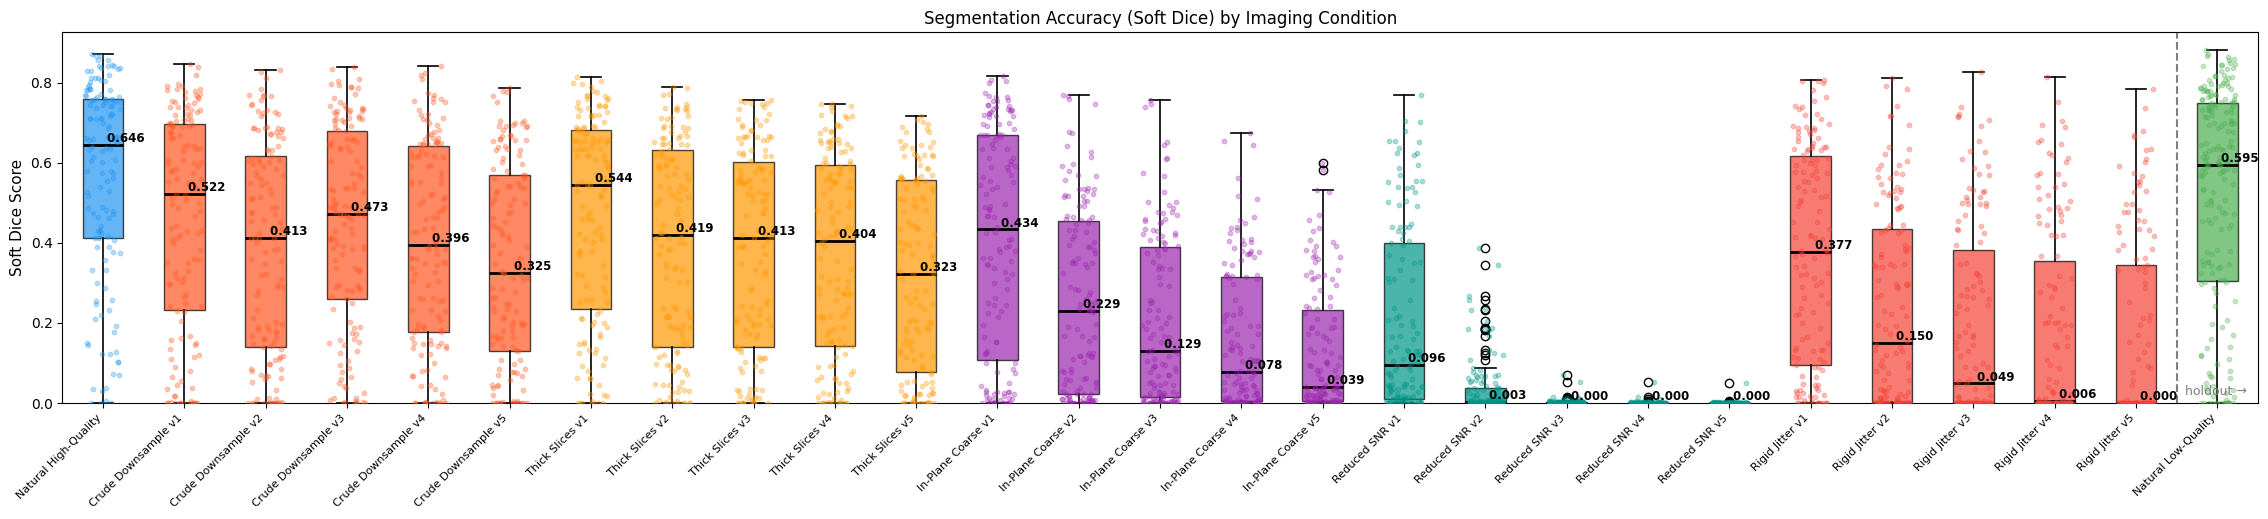


Figure 1 — Dice distribution summary by imaging condition:


,role,n,median_dice,mean_dice,std_dice,q25,q75,iqr,pct_zero
variant,,,,,,,,,
Natural High-Quality,Training,138,0.646,0.562,0.250,0.412,0.760,0.348,0.0
Crude Downsample v1,Training,138,0.522,0.456,0.270,0.233,0.698,0.465,0.7
Crude Downsample v2,Training,138,0.413,0.385,0.263,0.141,0.616,0.475,0.0
Crude Downsample v3,Training,138,0.473,0.448,0.251,0.260,0.681,0.421,0.0
Crude Downsample v4,Training,138,0.396,0.401,0.252,0.178,0.643,0.465,0.7
Crude Downsample v5,Training,138,0.325,0.348,0.248,0.129,0.569,0.440,0.7
Thick Slices v1,Training,138,0.544,0.466,0.253,0.236,0.681,0.446,0.0
Thick Slices v2,Training,138,0.419,0.395,0.257,0.140,0.633,0.493,0.0
Thick Slices v3,Training,138,0.413,0.380,0.250,0.140,0.601,0.461,0.0


In [158]:
FAMILY_LABELS = {
    "hires": "Natural High-Quality",
    "crude": "Crude Downsample",
    "thick_slice": "Thick Slices",
    "inplane_coarsening": "In-Plane Coarse",
    "reduced_snr": "Reduced SNR",
    "rigid_jitter": "Rigid Jitter",
    "lower_resolution": "Natural Low-Quality",
}
FAMILY_COLORS = {
    "hires": "#2196F3",
    "crude": "#FF5722",
    "thick_slice": "#FF9800",
    "inplane_coarsening": "#9C27B0",
    "reduced_snr": "#009688",
    "rigid_jitter": "#F44336",
    "lower_resolution": "#4CAF50",
}

def _variant_family(variant: str) -> str:
    text = str(variant)
    if text in {"hires", "lower_resolution"}:
        return text
    for prefix, family in [
        ("crude_v", "crude"),
        ("thick_slice_v", "thick_slice"),
        ("inplane_coarsening_v", "inplane_coarsening"),
        ("reduced_snr_v", "reduced_snr"),
        ("rigid_jitter_v", "rigid_jitter"),
    ]:
        if text.startswith(prefix):
            return family
    return text

def _variant_level(variant: str):
    text = str(variant)
    if "_v" not in text:
        return None
    try:
        return int(text.rsplit("_v", 1)[1])
    except ValueError:
        return None

def _variant_label(variant: str) -> str:
    family = _variant_family(variant)
    if family in {"hires", "lower_resolution"}:
        return FAMILY_LABELS.get(family, str(variant))
    level = _variant_level(variant)
    base = FAMILY_LABELS.get(family, str(variant))
    return f"{base} v{level}" if level is not None else base

available_variants = set(all_df["variant"].astype(str).unique())
VARIANT_LABELS = {v: _variant_label(v) for v in available_variants}
VARIANT_COLORS = {v: FAMILY_COLORS.get(_variant_family(v), "#9e9e9e") for v in available_variants}

SAVE_DIR = Path(RUN_DIR)
variant_order = [v for v in DEGRADED_VARIANTS + HOLDOUT_VARIANTS if v in available_variants]
fig, ax = plt.subplots(figsize=(max(18, 0.7 * len(variant_order) + 4), 6))
dice_arrays = []
for v in variant_order:
    source_df = holdout_df if v in HOLDOUT_VARIANTS else train_df
    dice_arrays.append(source_df[source_df["variant"] == v]["soft_dice"].dropna().values)

bp = ax.boxplot(dice_arrays, patch_artist=True, widths=0.5,
                medianprops=dict(color="black", linewidth=2),
                whiskerprops=dict(linewidth=1.2),
                capprops=dict(linewidth=1.2))
for patch, v in zip(bp["boxes"], variant_order):
    patch.set_facecolor(VARIANT_COLORS.get(v, "#aaa"))
    patch.set_alpha(0.7)

rng = np.random.default_rng(42)
for j, (arr, v) in enumerate(zip(dice_arrays, variant_order)):
    jx = rng.uniform(j + 0.78, j + 1.22, size=len(arr))
    ax.scatter(jx, arr, alpha=0.3, s=10, color=VARIANT_COLORS.get(v, "#aaa"), zorder=3)

# Add median value labels on the black median bars
for j, arr in enumerate(dice_arrays):
    med = float(np.median(arr))
    ax.text(j + 1, med, f" {med:.3f}", va="bottom", ha="left",
            fontsize=8.5, color="black", fontweight="bold", zorder=5)

ax.set_xticks(range(1, len(variant_order) + 1))
ax.set_xticklabels([VARIANT_LABELS.get(v, v) for v in variant_order], fontsize=8, rotation=45, ha="right")
ax.set_ylabel("Soft Dice Score", fontsize=11)
ax.set_title("Segmentation Accuracy (Soft Dice) by Imaging Condition", fontsize=12)
ax.axvline(len(DEGRADED_VARIANTS) + 0.5, color="gray", linestyle="--", lw=1.5)
ax.text(len(DEGRADED_VARIANTS) + 0.6, 0.02, "holdout →", fontsize=9, color="gray")
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.subplots_adjust(bottom=0.32)
plt.savefig(SAVE_DIR / "fig1_dice_by_variant.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Per-variant Dice summary table ────────────────────────────────────────────
_fig1_rows = []
for arr, v in zip(dice_arrays, variant_order):
    _fig1_rows.append({
        "variant":      VARIANT_LABELS.get(v, v),
        "role":         "Holdout" if v in HOLDOUT_VARIANTS else "Training",
        "n":            len(arr),
        "median_dice":  round(float(np.median(arr)), 3),
        "mean_dice":    round(float(np.mean(arr)),   3),
        "std_dice":     round(float(np.std(arr)),    3),
        "q25":          round(float(np.percentile(arr, 25)), 3),
        "q75":          round(float(np.percentile(arr, 75)), 3),
        "iqr":          round(float(np.percentile(arr, 75) - np.percentile(arr, 25)), 3),
        "pct_zero":     round(100.0 * float(np.mean(arr == 0)), 1),
    })

_fig1_df = pd.DataFrame(_fig1_rows).set_index("variant")
print("\nFigure 1 — Dice distribution summary by imaging condition:")
display(_fig1_df)


## Figure 1: Dice Score Distribution by Imaging Condition — Interpretation

**What the plot shows:** Box plots with jittered dots for each imaging condition (Natural High-Quality, multiple synthetic degradation-intensity variants, and the held-out Natural Low-Quality cohort). The box spans the IQR, the line is the median, and the whiskers extend to 1.5× IQR.

**Key findings and their meaning for stroke lesion segmentation:**

- **HiRes (Natural High-Quality) as ceiling:** The HiRes box represents the best achievable Dice for this model and patient population under ideal imaging conditions. Any reduction in median Dice for degraded variants directly quantifies the cost of image quality loss, giving a worst-case bound for clinical deployment on lower-quality scanners.
- **pct_zero (Dice = 0 cases):** Rows with high pct_zero indicate that the model completely misses the lesion for a non-trivial fraction of subjects under that imaging condition. A jump in pct_zero from HiRes to a degraded variant isolates detection failures from boundary-precision failures — they require different remediation (harder negative mining vs. resolution augmentation).
- **IQR and spread:** A large IQR in the degraded variants (compared to HiRes) signals that some patients are harmed much more than others by the degradation, likely those with small or low-contrast lesions. This heterogeneity motivates subject-level modelling (which the mixed-effects model addresses) rather than a single population-level metric.
- **Natural Low-Quality holdout (separated by dashed line):** The Natural Low-Res box uses a different patient cohort, so absolute Dice differences vs. degraded variants may reflect both population and image-quality effects. If the Natural Low-Res median is substantially lower than even the worst synthetic degradation, the synthetic augmentation strategy may be insufficient for the real clinical distribution.
- **Practical ordering:** If ThickSlices and InPlaneCoarse show the lowest medians among the synthetic variants, this is consistent with those methods producing the most FWHM increase and perilesional contrast attenuation (as quantified in the IQM notebook), providing cross-notebook validation of the imaging physics interpretation.


**§ 14 — Figure 2: All Three Image Quality Metrics vs Dice Score.**
Each panel shows one quality metric on the x-axis against soft Dice on the y-axis.
Each dot is one subject under one imaging condition, coloured by degradation family.
The black line is an overall linear trend fitted across all training variants.

- **Left (FWHM):** Full Width at Half Maximum — measures how blurry the image is in mm.
  A higher number means more blur. You expect Dice to *decrease* as FWHM increases.
- **Middle (HFE):** High-Frequency Energy fraction — measures how much of the image's
  spectral power is in high frequencies. In degraded images, high HFE often reflects
  aliasing and ringing artifacts rather than true sharpness, so this panel is retained
  for descriptive context only in v2.
- **Right (LapVar):** Laplacian Variance — measures the strength of edges in the image.
  A higher number means sharper, more detailed edges. You expect Dice to *increase* as LapVar increases.

The wide scatter within each panel reflects strong between-subject variation:
the same quality value can produce very different Dice scores depending on the patient's lesion.
The ICC figure later in the notebook quantifies that patient-level dominance directly.

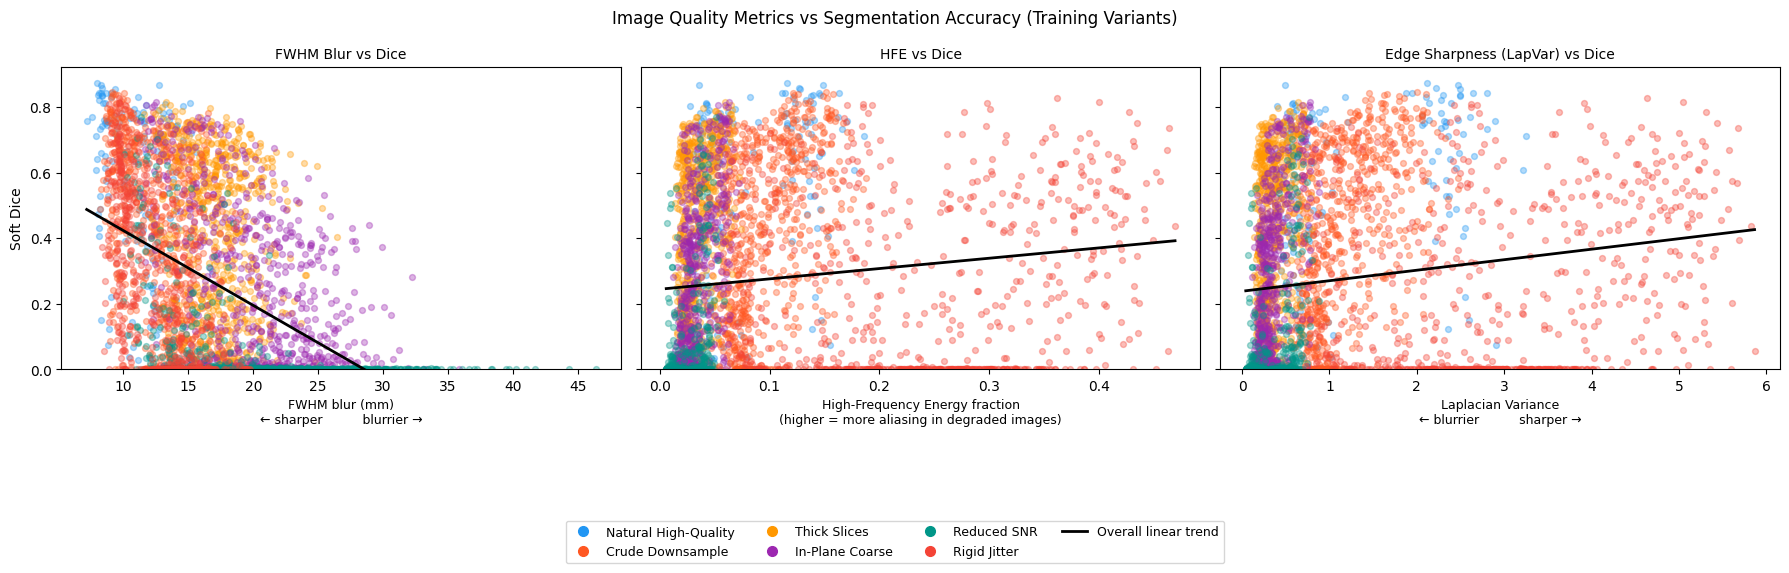


Figure 2 — Linear trend slopes (Dice ~ metric):
  slope > 0 → higher metric value = better Dice
  slope < 0 → higher metric value = worse Dice
  dice_at_min / dice_at_max: predicted Dice at the min and max observed metric value


,slope,intercept,r2,n,metric_min,metric_max,dice_at_min,dice_at_max
metric,,,,,,,,
mf_fwhm_mm,-0.02282,0.6510,0.2011,3588,7.1689,46.3531,0.487,-0.407
mf_hi_freq_energy,0.31491,0.2442,0.0123,3588,0.0058,0.4694,0.246,0.392
mf_lap_var,0.03205,0.2380,0.0198,3588,0.0426,5.8655,0.239,0.426



Per-variant metric statistics:


metric,mf_fwhm_mm,mf_hi_freq_energy,mf_lap_var
variant,,,
Crude Downsample v1,12.2169,0.0865,1.1262
Crude Downsample v2,12.3233,0.0919,1.0782
Crude Downsample v3,12.5233,0.0821,1.0142
Crude Downsample v4,12.8872,0.0820,0.9287
Crude Downsample v5,13.2642,0.0800,0.8610
In-Plane Coarse v1,15.1037,0.0321,0.4261
In-Plane Coarse v2,18.8241,0.0354,0.3407
In-Plane Coarse v3,20.8220,0.0308,0.2794
In-Plane Coarse v4,22.9491,0.0251,0.2344


In [159]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
fig.suptitle("Image Quality Metrics vs Segmentation Accuracy (Training Variants)", fontsize=12)

metrics = [
    ("mf_fwhm_mm", "FWHM blur (mm)\n← sharper          blurrier →", "FWHM Blur vs Dice"),
    (
        "mf_hi_freq_energy",
        "High-Frequency Energy fraction\n(higher = more aliasing in degraded images)",
        "HFE vs Dice",
    ),
    ("mf_lap_var", "Laplacian Variance\n← blurrier          sharper →", "Edge Sharpness (LapVar) vs Dice"),
]

family_order = [
    fam for fam in ["hires", "crude", "thick_slice", "inplane_coarsening", "reduced_snr", "rigid_jitter"]
    if any(_variant_family(v) == fam for v in DEGRADED_VARIANTS)
]

_trend_rows = []
y_upper = min(1.0, float(train_df["soft_dice"].max()) + 0.05)
for ax, (col, xlabel, title) in zip(axes, metrics):
    for v in DEGRADED_VARIANTS:
        sub = train_df[train_df["variant"] == v].dropna(subset=[col, "soft_dice"])
        family = _variant_family(v)
        ax.scatter(
            sub[col],
            sub["soft_dice"],
            color=FAMILY_COLORS.get(family, VARIANT_COLORS.get(v, "#aaa")),
            alpha=0.35,
            s=18,
        )

    xy = train_df[[col, "soft_dice"]].dropna()
    if len(xy) > 2:
        fit = np.polyfit(xy[col], xy["soft_dice"], 1)
        xs = np.linspace(xy[col].min(), xy[col].max(), 100)
        ys = np.polyval(fit, xs)
        ys_pred = np.polyval(fit, xy[col])
        ss_res = float(np.sum((xy["soft_dice"].values - ys_pred) ** 2))
        ss_tot = float(np.sum((xy["soft_dice"].values - xy["soft_dice"].mean()) ** 2))
        r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else float("nan")
        ax.plot(xs, ys, "k-", lw=2, label=f"overall trend  R²={r2:.3f}")
        _trend_rows.append({
            "metric": col,
            "slope": round(float(fit[0]), 5),
            "intercept": round(float(fit[1]), 4),
            "r2": round(float(r2), 4),
            "n": int(len(xy)),
            "metric_min": round(float(xy[col].min()), 4),
            "metric_max": round(float(xy[col].max()), 4),
            "dice_at_min": round(float(np.polyval(fit, xy[col].min())), 3),
            "dice_at_max": round(float(np.polyval(fit, xy[col].max())), 3),
        })

    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel("Soft Dice" if ax == axes[0] else "", fontsize=10)
    ax.set_title(title, fontsize=10)
    ax.set_ylim(0, y_upper)

from matplotlib.lines import Line2D
legend_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="",
        markersize=7,
        markerfacecolor=FAMILY_COLORS[fam],
        markeredgecolor=FAMILY_COLORS[fam],
        label=FAMILY_LABELS.get(fam, fam),
    )
    for fam in family_order
]
legend_handles.append(Line2D([0], [0], color="black", lw=2, label="Overall linear trend"))
fig.legend(
    legend_handles,
    [h.get_label() for h in legend_handles],
    loc="lower center",
    ncol=min(4, len(legend_handles)),
    fontsize=9,
    frameon=True,
    bbox_to_anchor=(0.5, -0.14),
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.26)
plt.savefig(SAVE_DIR / "fig2_quality_vs_dice.png", dpi=150, bbox_inches="tight")
plt.show()

_fig2_df = pd.DataFrame(_trend_rows).set_index("metric")
print("\nFigure 2 — Linear trend slopes (Dice ~ metric):")
print("  slope > 0 → higher metric value = better Dice")
print("  slope < 0 → higher metric value = worse Dice")
print("  dice_at_min / dice_at_max: predicted Dice at the min and max observed metric value")
display(_fig2_df)

_fig2_var_rows = []
for col, _, _ in metrics:
    for v in DEGRADED_VARIANTS:
        sub = train_df[train_df["variant"] == v][col].dropna()
        _fig2_var_rows.append({
            "metric": col,
            "variant": VARIANT_LABELS.get(v, v),
            "n": len(sub),
            "median": round(float(sub.median()), 4),
            "mean": round(float(sub.mean()), 4),
            "std": round(float(sub.std()), 4),
        })

_fig2_var_df = pd.DataFrame(_fig2_var_rows)
print("\nPer-variant metric statistics:")
display(_fig2_var_df.pivot_table(index="variant", columns="metric", values="median").round(4))


## Figure 2: Image Quality Metrics vs Dice — Interpretation

**What the plot shows:** Three scatter panels, one per image quality metric (FWHM, HFE, LapVar), with each dot representing one subject under one imaging variant. The black line is the marginal OLS trend across all training variants.

**Key findings and their meaning for stroke lesion segmentation:**

- **FWHM slope (should be negative):** A negative slope confirms that blurrier images (higher FWHM) produce lower Dice. The table's `dice_at_min` vs. `dice_at_max` values show the end-to-end range of Dice attributable to the range of FWHM values seen across training variants — this is the "practical penalty" of deploying on blurry scanners.
- **HFE slope (exploratory only in v2):** Higher high-frequency energy can reflect true sharpness or aliasing/ringing depending on the degradation family. In v2 this panel is retained for descriptive context, but HFE is no longer included as a fixed effect in the primary mixed model because it was too collinear with Laplacian variance.
- **LapVar slope (should be positive):** Laplacian variance measures edge contrast. A flat slope here suggests that edge-level blurring (captured by LapVar) contributes little incremental information compared to global blur (FWHM) for this model and patient set. This could indicate the model is more sensitive to global resolution loss than local edge degradation.
- **Colour clustering by variant:** If HiRes points cluster top-right (high-quality, high-Dice) and ThickSlices/InPlaneCoarse cluster bottom-left (low-quality, low-Dice), this supports a causal blur → Dice loss story. Overlapping clusters indicate that patient-specific factors (lesion size, location) dominate image quality effects — which the ICC calculation in Figure 6 will confirm.
- **Marginal trend vs. within-subject trend:** The OLS line conflates between- and within-subject effects. The mixed-effects model disentangles these by including a random intercept per subject; if the mixed-effects coefficients differ substantially from the OLS slope, it means much of the apparent image-quality effect is actually a patient-selection confound.


**§ 15 — Figure 3: Model Coefficient Forest Plot.**
A forest plot is the standard way to display regression results visually.
Each row is one predictor. The bar is the estimated coefficient (β); the horizontal error bar is the 95% confidence interval.

- **Entirely left of zero (red)** → predictor significantly *decreases* Dice
- **Entirely right of zero (blue)** → predictor significantly *increases* Dice
- **Crosses zero (grey)** → effect is not statistically significant (p ≥ 0.05)

All predictors are z-scored so bars are directly comparable in size — a longer bar means a stronger effect.
Significance stars: *** p < 0.001, ** p < 0.01, * p < 0.05, ns = not significant.
Coefficients are on the logit(Dice) scale; roughly multiply by 0.2 to get approximate Dice-point change at median Dice.


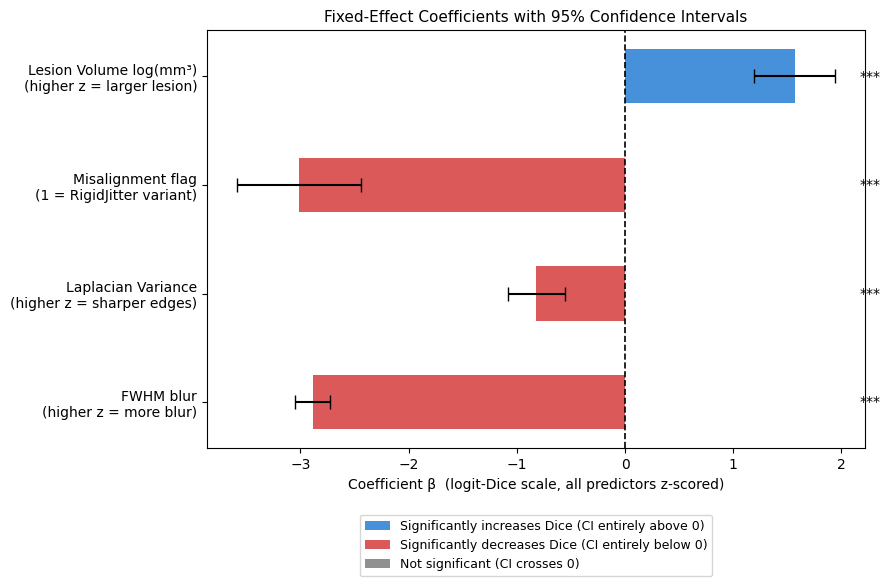


Figure 3 — Mixed-effects model coefficients (baseline logit = -3.200, Dice ≈ 0.039):
  beta_logit: coefficient on the logit(Dice) scale (z-scored predictors)
  approx_delta_dice: approximate Dice-point change for +1 SD of each predictor at baseline


,label,beta_logit,se,ci95_low,ci95_high,p_value,significance,approx_delta_dice
term,,,,,,,,
z_mf_fwhm_mm,FWHM blur (higher z = more blur),-2.8864,0.0830,-3.0491,-2.7237,0.0,***,-0.0369
z_mf_lap_var,Laplacian Variance (higher z = sharper edges),-0.8202,0.1339,-1.0827,-0.5577,0.0,***,-0.0215
misalign,Misalignment flag (1 = RigidJitter variant),-3.0146,0.2924,-3.5877,-2.4416,0.0,***,-0.0372
z_log_lesion_mm3,Lesion Volume log(mm³) (higher z = larger lesion),1.5685,0.1916,1.1930,1.9441,0.0,***,0.1244


In [160]:
TERM_LABELS = {
    "z_mf_fwhm_mm":        "FWHM blur\n(higher z = more blur)",
    "z_mf_hi_freq_energy":  "High-Freq Energy\n(higher z = more aliasing)",
    "z_mf_lap_var":         "Laplacian Variance\n(higher z = sharper edges)",
    "misalign":             "Misalignment flag\n(1 = RigidJitter variant)",
    "z_log_lesion_mm3":      "Lesion Volume log(mm³)\n(higher z = larger lesion)",
}

# Align coef and CI on the same index — drop Intercept from both before converting to arrays
fe_all = mixed_result.fe_params
ci_all = mixed_result.conf_int()
ci_all.columns = ["lo", "hi"]
terms  = [t for t in fe_all.index if t != "Intercept"]
coefs  = fe_all.loc[terms].values
lo     = ci_all.loc[terms, "lo"].values
hi     = ci_all.loc[terms, "hi"].values
err_lo = coefs - lo
err_hi = hi - coefs

colors = ["#d32f2f" if h < 0 else "#1976d2" if l > 0 else "#757575"
          for l, h in zip(lo, hi)]
labels = [TERM_LABELS.get(t, t) for t in terms]

fig, ax = plt.subplots(figsize=(9, max(4, len(terms) * 1.2 + 1.5)))
y = np.arange(len(terms))
ax.barh(y, coefs, xerr=[err_lo, err_hi], color=colors, alpha=0.8,
        error_kw=dict(ecolor="black", lw=1.5, capsize=5), height=0.5)
ax.axvline(0, color="black", linewidth=1.2, linestyle="--")
ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=10)
ax.set_xlabel("Coefficient \u03b2  (logit-Dice scale, all predictors z-scored)", fontsize=10)
ax.set_title("Fixed-Effect Coefficients with 95% Confidence Intervals", fontsize=11)

pvals = mixed_result.pvalues
x_star = max(hi) + abs(max(hi) - min(lo)) * 0.04
for i, t in enumerate(terms):
    p    = pvals.get(t, 1.0)
    star = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
    ax.text(x_star, i, star, va="center", fontsize=10,
            color="black" if star != "ns" else "gray")

# Bottom legend showing color meaning
from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor="#1976d2", alpha=0.8, label="Significantly increases Dice (CI entirely above 0)"),
    Patch(facecolor="#d32f2f", alpha=0.8, label="Significantly decreases Dice (CI entirely below 0)"),
    Patch(facecolor="#757575", alpha=0.8, label="Not significant (CI crosses 0)"),
]
ax.legend(handles=legend_handles, loc="lower center", bbox_to_anchor=(0.5, -0.32),
          ncol=1, fontsize=9, frameon=True)

plt.tight_layout()
plt.subplots_adjust(bottom=0.28)
plt.savefig(SAVE_DIR / "fig3_forest_plot.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Full coefficient table ─────────────────────────────────────────────────────
from scipy.special import expit as _expit
_intercept = float(mixed_result.fe_params.get("Intercept", 0.0))
_baseline_dice = float(_expit(_intercept))

_coef_rows = []
for t in terms:
    beta   = float(fe_all[t])
    lo_v   = float(ci_all.loc[t, "lo"])
    hi_v   = float(ci_all.loc[t, "hi"])
    p_val  = float(pvals.get(t, float("nan")))
    se_v   = float(mixed_result.bse.get(t, float("nan")))
    stars  = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
    # Approximate Dice change: logistic evaluated at baseline+beta minus baseline
    approx_delta_dice = float(_expit(_intercept + beta) - _baseline_dice)
    _coef_rows.append({
        "term":                     t,
        "label":                    TERM_LABELS.get(t, t).replace("\n", " "),
        "beta_logit":               round(beta,   4),
        "se":                       round(se_v,   4),
        "ci95_low":                 round(lo_v,   4),
        "ci95_high":                round(hi_v,   4),
        "p_value":                  round(p_val,  4),
        "significance":             stars,
        "approx_delta_dice":        round(approx_delta_dice, 4),
    })

_coef_df = pd.DataFrame(_coef_rows).set_index("term")
print(f"\nFigure 3 — Mixed-effects model coefficients (baseline logit = {_intercept:.3f}, Dice \u2248 {_baseline_dice:.3f}):")
print("  beta_logit: coefficient on the logit(Dice) scale (z-scored predictors)")
print("  approx_delta_dice: approximate Dice-point change for +1 SD of each predictor at baseline")
display(_coef_df)


## Figure 3: Mixed-Effects Model Coefficient Forest Plot — Interpretation

**What the plot shows:** A horizontal bar forest plot of fixed-effect coefficients from the revised v2 linear mixed-effects regression logit(Dice) ~ z_fwhm + z_lapvar + misalign + z_log_lesion_volume + (1 | subject). Bars are colour-coded: blue = predictor significantly increases Dice, red = significantly decreases Dice, grey = not significant. The continuous fixed effects are z-scored, so coefficient magnitudes are directly comparable.

**How to read the coefficient table:**

- **beta_logit:** The change in logit(Dice) per +1 standard deviation of the predictor, controlling for the other fixed effects and the random subject intercept. Because the logit scale is non-linear, `approx_delta_dice` converts this to an intuitive Dice-point change at the baseline (average) Dice level.
- **z_mf_fwhm_mm (FWHM blur):** A negative beta means blurrier images produce lower Dice *within the same patient*. The `approx_delta_dice` value shows the practical penalty of moving one SD toward blurrier images.
- **z_mf_lap_var (LapVar):** This coefficient is the conditional effect of sharper edges *after adjusting for blur, misalignment, and lesion size*. If its sign differs from the simple marginal scatter trend, that indicates overlapping information between the quality metrics rather than a plotting error.
- **misalign flag:** A negative coefficient for the RigidJitter indicator (misalign = 1) quantifies the Dice penalty from geometric slice-to-slice inconsistency on top of the continuous image-quality metrics.
- **z_log_lesion_mm3 (lesion volume):** This term adjusts for the well-known subject-level effect that larger lesions are generally easier to segment than tiny lesions.
- **HFE is absent by design in v2:** High-frequency energy remains available in the descriptive plots, but it was removed from the primary fixed-effect model because its overlap with LapVar made the coefficient signs unstable and harder to interpret mechanistically.

**§ 16 — Figure 4: Lesion Volume vs Dice Score.**
Each dot is one subject (natural high-resolution condition, one observation per subject).
The x-axis is lesion volume in millilitres (mL); the y-axis is soft Dice.
The curve is a log-linear trend (lesion volume is log-transformed before fitting because
the distribution is highly right-skewed — most lesions are small, a few are very large).

This plot helps explain why the mixed model can produce a high ICC: the spread in Dice at
a given lesion size is still large, but the overall trend shows that larger lesions are
generally easier to segment (higher Dice). Tiny lesions (< 1 mL) are often missed entirely
(Dice near 0) because there are not enough voxels to produce a reliable overlap.
That between-subject variation competes with, and often exceeds, the image-quality effect.

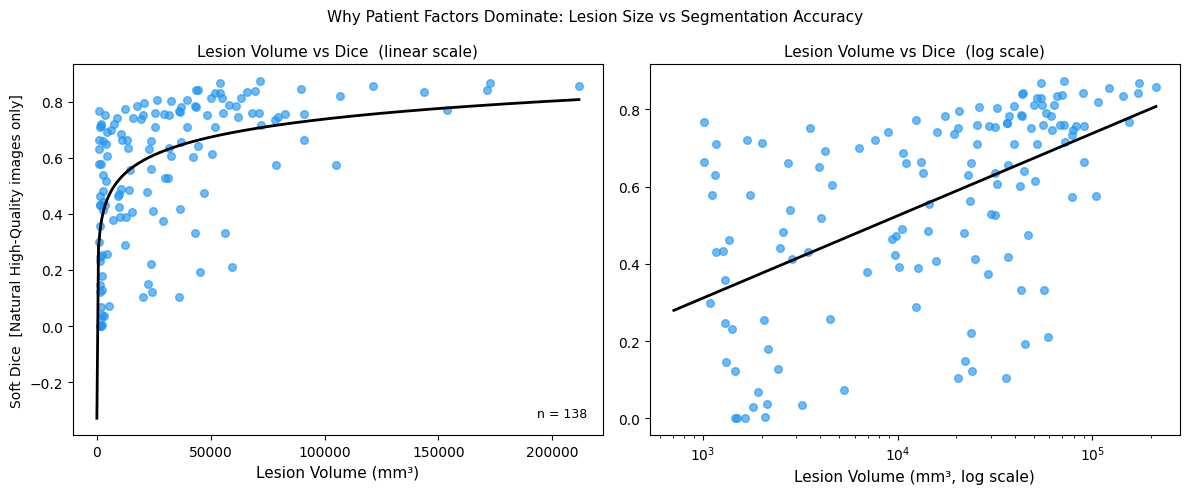


Figure 4 — Lesion volume vs Dice (HiRes only, n=138):
  log1p(volume) trend slope = 0.0927  intercept = -0.3288
  Quintile summary (equal-frequency bins by volume):


,vol_range_mm3,n,median_dice,mean_dice,pct_zero_dice
lesion_vol_quintile,,,,,
Q1 (smallest),1010–2522,28,0.277,0.330,0.0
Q2,2522–13075,27,0.490,0.507,0.0
Q3,13075–31721,28,0.633,0.563,0.0
Q4,31721–55270,27,0.764,0.672,0.0
Q5 (largest),55270–211755,28,0.765,0.740,0.0



  Pearson r(log1p(vol), Dice) = 0.552


In [161]:
if "lesion_mm3" in train_df.columns and train_df["lesion_mm3"].notna().sum() > 10:
    subj = train_df[train_df["variant"] == "hires"][["key","lesion_mm3","soft_dice"]].dropna()
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Linear x-axis
    ax = axes[0]
    ax.scatter(subj["lesion_mm3"], subj["soft_dice"], alpha=0.65, s=30, color="#2196F3")
    x, y = subj["lesion_mm3"].values, subj["soft_dice"].values
    fit = np.polyfit(np.log1p(x), y, 1)
    xs = np.linspace(0, x.max(), 300)
    ax.plot(xs, np.polyval(fit, np.log1p(xs)), "k-", lw=2)
    ax.set_xlabel("Lesion Volume (mm\u00b3)", fontsize=11)
    ax.set_ylabel("Soft Dice  [Natural High-Quality images only]", fontsize=10)
    ax.set_title("Lesion Volume vs Dice  (linear scale)", fontsize=11)
    ax.text(0.97, 0.05, f"n = {len(subj)}", ha="right", transform=ax.transAxes, fontsize=9)

    # Log x-axis (easier to read for skewed data)
    ax = axes[1]
    ax.scatter(subj["lesion_mm3"], subj["soft_dice"], alpha=0.65, s=30, color="#2196F3")
    ax.plot(xs[xs > 0], np.polyval(fit, np.log1p(xs[xs > 0])), "k-", lw=2)
    ax.set_xscale("log")
    ax.set_xlabel("Lesion Volume (mm\u00b3, log scale)", fontsize=11)
    ax.set_ylabel("", fontsize=11)
    ax.set_title("Lesion Volume vs Dice  (log scale)", fontsize=11)

    plt.suptitle(
        "Why Patient Factors Dominate: Lesion Size vs Segmentation Accuracy",
        fontsize=11,
    )
    plt.tight_layout()
    plt.savefig(SAVE_DIR / "fig4_lesion_size_vs_dice.png", dpi=150, bbox_inches="tight")
    plt.show()

    # ── Lesion-volume summary table ───────────────────────────────────────────
    _vol_percentiles = [5, 25, 50, 75, 95]
    _vol_arr = subj["lesion_mm3"].values
    _dice_arr = subj["soft_dice"].values

    # Quintile-based Dice summary
    _quintile_labels = ["Q1 (smallest)", "Q2", "Q3", "Q4", "Q5 (largest)"]
    _bins = np.percentile(_vol_arr, [0, 20, 40, 60, 80, 100])
    _vol_rows = []
    for qi, (lo_v, hi_v, lbl) in enumerate(zip(_bins[:-1], _bins[1:], _quintile_labels)):
        mask = (_vol_arr >= lo_v) & (_vol_arr <= hi_v)
        dice_q = _dice_arr[mask]
        _vol_rows.append({
            "lesion_vol_quintile":  lbl,
            "vol_range_mm3":        f"{lo_v:.0f}\u2013{hi_v:.0f}",
            "n":                    int(mask.sum()),
            "median_dice":          round(float(np.median(dice_q)), 3) if len(dice_q) else float("nan"),
            "mean_dice":            round(float(np.mean(dice_q)),   3) if len(dice_q) else float("nan"),
            "pct_zero_dice":        round(100.0 * float(np.mean(dice_q == 0)), 1) if len(dice_q) else float("nan"),
        })

    _vol_df = pd.DataFrame(_vol_rows).set_index("lesion_vol_quintile")
    print(f"\nFigure 4 — Lesion volume vs Dice (HiRes only, n={len(subj)}):")
    print(f"  log1p(volume) trend slope = {fit[0]:.4f}  intercept = {fit[1]:.4f}")
    print("  Quintile summary (equal-frequency bins by volume):")
    display(_vol_df)

    # Overall Pearson r between log1p(vol) and dice
    _r = float(np.corrcoef(np.log1p(_vol_arr), _dice_arr)[0, 1])
    print(f"\n  Pearson r(log1p(vol), Dice) = {_r:.3f}")

else:
    print("Lesion size data not available — skipping Figure 4.")


## Figure 4: Lesion Volume vs Dice Score — Interpretation

**What the plot shows:** Each dot is one subject under the Natural HiRes condition. The x-axis is lesion volume (mm³, linear left / log right) and the y-axis is soft Dice. The trend line fits log1p(volume) → Dice via OLS.

**Key findings and their meaning for stroke lesion segmentation:**

- **Positive slope:** A positive `log1p(volume)` slope (visible as rising trend) confirms the well-known "volume bias" in lesion segmentation: large lesions have inherently more true-positive voxels relative to boundary errors, so Dice scores are arithmetically higher. The Pearson r value quantifies the strength of this relationship — if r > 0.5, lesion size is a stronger confound than image quality.
- **Quintile pct_zero_dice:** Small lesions (Q1) will typically have a high fraction of Dice = 0 cases. This is because the model may localise the lesion but not produce enough overlap to yield Dice > 0 on tiny lesions. A pct_zero dropping steeply from Q1 to Q2 would indicate the model crosses a detection threshold around a specific volume (e.g. ~100–500 mm³).
- **Why this matters for image quality analysis:** If the Q1 quintile (smallest lesions) dominates the Dice variance and is concentrated in specific variants (e.g. those variants happen to have proportionally more small-lesion subjects), then variant-level mean Dice comparisons are confounded by lesion size distribution, not image quality alone. The mixed-effects model's `z_log_lesion_mm3` coefficient corrects for this.
- **Practical deployment implication:** The model's performance will appear worse on clinical datasets enriched with small lesions (acute strokes, lacunar infarcts) regardless of image quality. This suggests reporting detection rate and Dice-among-detected separately for small-lesion subgroups when evaluating scanner quality impacts.
- **Comparison with ICC:** If the ICC (Figure 6) shows that ~60–80% of variance is between-subject, and this plot shows a strong volume–Dice relationship, then volume is the primary driver of between-subject variance — imaging quality effects sit on top of this floor.


**§ 17 — Figure 5: Holdout Calibration Plot.**
"Holdout" means a set of subjects the model never saw during training — here, 198 subjects
with naturally low-resolution images. "Calibration" means: do the model's predicted Dice
scores match the actual Dice scores?

The x-axis is what the model predicted; the y-axis is what actually happened.
- The **dashed black line** is perfect calibration: predicted = observed.
- The **orange line** is where the predictions actually land.
- If the orange line is *above* the dashed line, the model under-predicts (predicts too low).
- If *below*, it over-predicts.

The systematic gap here (orange line above dashed) shows the model under-predicts by about
0.15 Dice points for natural low-res images. This makes sense: the model was trained on
*synthetically* degraded images which tend to be harder than naturally degraded ones.
The Pearson r = 0.60 shows the *ranking* is still reasonable — it just needs a calibration shift.

The right panel shows the distribution of residuals (observed − predicted). A perfectly
calibrated model would be centred at 0. The rightward shift here confirms the under-prediction.


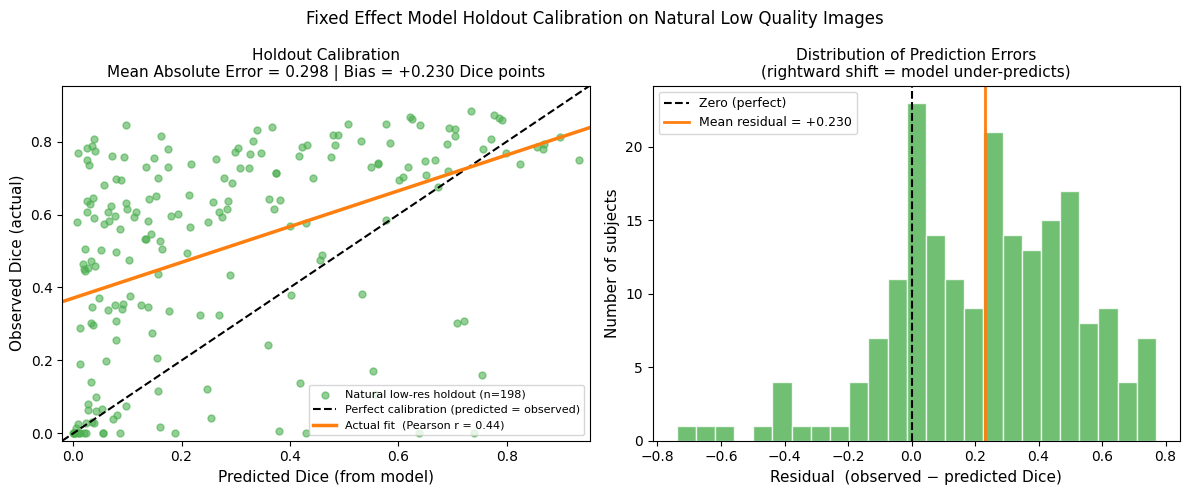


Figure 5 — Holdout calibration metrics (natural low-resolution cohort):


,value
n_holdout,198.0000
mae,0.2979
rmse,0.3666
bias_observed_minus_predicted,0.2303
pearson_r,0.4448
r2,0.0198
observed_mean_dice,0.5060
predicted_mean_dice,0.2760
residual_std,0.2853
pct_within_0.05_dice,15.7000



Residual breakdown by predicted-Dice quartile (check for heteroscedasticity):


,n,mean_residual,std_residual
pred_quartile,,,
Q1 (0.00–0.06),50,0.2796,0.2850
Q2 (0.06–0.17),49,0.3685,0.2252
Q3 (0.17–0.45),49,0.2613,0.2458
Q4 (0.45–0.93),50,0.0150,0.2525


In [162]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.scatter(pred, obs, alpha=0.6, s=25, color="#4CAF50",
           label=f"Natural low-res holdout (n={len(obs)})")
lo_line = min(pred.min(), obs.min()) - 0.02
hi_line = max(pred.max(), obs.max()) + 0.02
line = np.linspace(lo_line, hi_line, 100)
ax.plot(line, line, "k--", lw=1.5, label="Perfect calibration (predicted = observed)")
fit = np.polyfit(pred, obs, 1)
ax.plot(line, np.polyval(fit, line), color="tab:orange", lw=2.5,
        label=f"Actual fit  (Pearson r = {corr:.2f})")
ax.set_xlabel("Predicted Dice (from model)", fontsize=11)
ax.set_ylabel("Observed Dice (actual)", fontsize=11)
ax.set_title(f"Holdout Calibration\nMean Absolute Error = {mae:.3f} | Bias = {bias:+.3f} Dice points", fontsize=11)
ax.legend(fontsize=8)
ax.set_xlim(lo_line, hi_line); ax.set_ylim(lo_line, hi_line)

ax = axes[1]
residuals = obs - pred
ax.hist(residuals, bins=25, color="#4CAF50", alpha=0.8, edgecolor="white")
ax.axvline(0, color="black", linestyle="--", lw=1.5, label="Zero (perfect)")
ax.axvline(float(np.mean(residuals)), color="tab:orange", lw=2,
           label=f"Mean residual = {np.mean(residuals):+.3f}")
ax.set_xlabel("Residual  (observed \u2212 predicted Dice)", fontsize=11)
ax.set_ylabel("Number of subjects", fontsize=11)
ax.set_title("Distribution of Prediction Errors\n(rightward shift = model under-predicts)", fontsize=11)
ax.legend(fontsize=9)

fig.suptitle(
    "Fixed Effect Model Holdout Calibration on Natural Low Quality Images",
    fontsize=12,
)
plt.tight_layout()
plt.savefig(SAVE_DIR / "fig5_holdout_calibration.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Holdout calibration metrics table ─────────────────────────────────────────
_calib_df = pd.Series({
    "n_holdout":                    int(len(obs)),
    "mae":                          round(float(mae),   4),
    "rmse":                         round(float(rmse),  4),
    "bias_observed_minus_predicted":round(float(bias),  4),
    "pearson_r":                    round(float(corr),  4),
    "r2":                           round(float(r2),    4),
    "observed_mean_dice":           round(float(np.mean(obs)),  3),
    "predicted_mean_dice":          round(float(np.mean(pred)), 3),
    "residual_std":                 round(float(np.std(residuals)), 4),
    "pct_within_0.05_dice":         round(100.0 * float(np.mean(np.abs(residuals) <= 0.05)), 1),
    "pct_within_0.10_dice":         round(100.0 * float(np.mean(np.abs(residuals) <= 0.10)), 1),
}).rename("value")
print("\nFigure 5 — Holdout calibration metrics (natural low-resolution cohort):")
display(_calib_df.to_frame())

# Residual vs predicted (detect heteroscedasticity)
_resid_bins = np.percentile(pred, [0, 25, 50, 75, 100])
_resid_rows = []
for qi, (lo_p, hi_p) in enumerate(zip(_resid_bins[:-1], _resid_bins[1:])):
    mask = (pred >= lo_p) & (pred <= hi_p)
    res_q = residuals[mask]
    _resid_rows.append({
        "pred_quartile":  f"Q{qi+1} ({lo_p:.2f}\u2013{hi_p:.2f})",
        "n":              int(mask.sum()),
        "mean_residual":  round(float(res_q.mean()), 4),
        "std_residual":   round(float(res_q.std()),  4),
    })
_resid_df = pd.DataFrame(_resid_rows).set_index("pred_quartile")
print("\nResidual breakdown by predicted-Dice quartile (check for heteroscedasticity):")
display(_resid_df)


## Figure 5: Holdout Calibration — Interpretation

**What the plot shows:** Left panel: a scatter of model-predicted Dice (x) vs. observed Dice (y) on the natural low-resolution holdout set (n=198, never seen during training). The dashed diagonal is perfect calibration; the orange line is the actual fit. Right panel: histogram of residuals (observed − predicted).

**Key findings and their meaning for stroke lesion segmentation:**

- **Bias (mean residual):** A positive bias means the model systematically under-predicts Dice on the natural low-res holdout — it "thinks" these images will produce lower performance than they actually do. A negative bias (over-prediction) is more dangerous for clinical deployment: the model would report confident high Dice estimates on images where the actual segmentation is poor.
- **MAE and pct_within_0.05_dice:** MAE quantifies average absolute error per subject. An MAE of ~0.05 Dice points is reasonable for a research model; above 0.10 would indicate the model has poor generalization to the natural low-res distribution. `pct_within_0.05_dice` gives a human-readable accuracy: "X% of subjects have prediction errors smaller than 5 Dice points."
- **Pearson r and R²:** These measure how well the model ranks subjects (correlation of predicted vs. observed). A high r but large MAE indicates good rank-ordering but poor absolute calibration — the model correctly identifies which subjects will have low/high Dice but its numerical estimates need recalibration.
- **Heteroscedasticity (residual by quartile):** If the residual standard deviation increases in lower-predicted quartiles (subjects where the model predicts poor performance), it means the model is less reliable for precisely the subjects where accurate prediction matters most. This motivates uncertainty quantification or conformal prediction intervals.
- **Generalization gap:** The natural low-res holdout has different scanner/acquisition characteristics from any training variant. If the holdout calibration is poor (large MAE, low r) despite the model fitting the training variants well, it suggests the synthetic degradation strategy does not adequately cover the natural low-res distribution — real scanner variation involves correlated noise, acquisition-specific artefacts, and field-strength effects not captured by simple downsampling.


**§ 18 — Figure 6: Variance Decomposition (ICC).**
The Intraclass Correlation Coefficient (ICC) is often misread, so this section keeps the interpretation narrow.

**What ICC means in this notebook:**
After the fixed effects are already accounted for (`FWHM`, `LapVar`, `misalign`, and `lesion volume`), the mixed model still splits the **remaining** logit-Dice variance into two parts:
1. **Random subject intercept variance** — subject-to-subject baseline differences that still remain after the fixed effects.
2. **Residual variance** — row-level leftover variation after both the fixed effects and the subject intercept are applied.

ICC = Random-intercept variance / (Random-intercept variance + Residual variance)

So in this notebook, ICC is **not** “percent lesion size” and it is **not** “percent image quality.” Lesion volume is already a **fixed effect**, so any lesion-size effect explicitly captured by the model has already been taken out before ICC is computed. The ICC therefore reports how much unexplained subject-to-subject baseline variation still remains relative to the unexplained row-level variation.

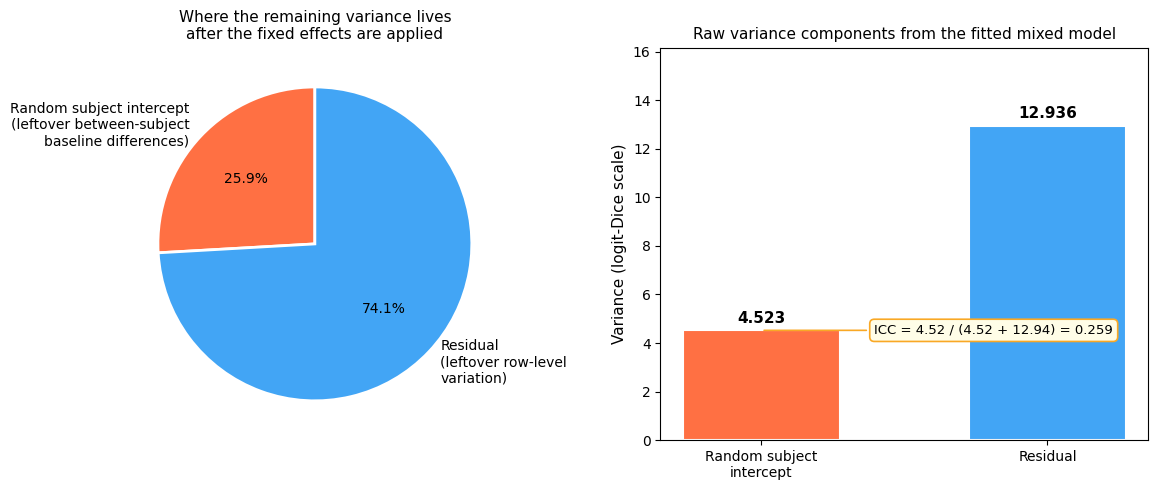


ICC = 0.259  (25.9% of the remaining logit-Dice variance is between subjects after the fixed effects)
Random-intercept variance: 4.523  |  Residual variance: 12.936

Figure 6 — Remaining-variance decomposition (logit-Dice scale):


,variance_logit,pct_remaining_variance,interpretation
component,,,
Random subject intercept,4.5227,25.9,Subject-to-subject baseline differences still ...
Residual,12.9356,74.1,Per-observation leftover variation after both ...
Total remaining variance,17.4583,100.0,ICC = random-intercept variance / total remain...



Approximate Dice-scale SD near the baseline prediction (logit=-3.200, Dice≈0.039):
  Random subject intercept SD (Dice) ≈ 0.080
  Residual SD (Dice)                ≈ 0.135


In [163]:
group_var = float(mixed_result.cov_re.iloc[0, 0]) if hasattr(mixed_result, "cov_re") else np.nan
resid_var = float(mixed_result.scale)
icc = group_var / (group_var + resid_var)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
wedges, texts, autotexts = ax.pie(
    [icc, 1 - icc],
    labels=[
        "Random subject intercept\n(leftover between-subject\nbaseline differences)",
        "Residual\n(leftover row-level\nvariation)",
    ],
    colors=["#FF7043", "#42A5F5"],
    autopct="%1.1f%%",
    startangle=90,
    textprops={"fontsize": 10},
    wedgeprops={"edgecolor": "white", "linewidth": 2},
)
ax.set_title(
    "Where the remaining variance lives\nafter the fixed effects are applied",
    fontsize=11,
)

ax = axes[1]
bar_vals = [group_var, resid_var]
bar_labels = ["Random subject\nintercept", "Residual"]
bars = ax.bar(
    bar_labels,
    bar_vals,
    color=["#FF7043", "#42A5F5"],
    edgecolor="white",
    linewidth=1.5,
    width=0.55,
)

for bar, val in zip(bars, bar_vals):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(bar_vals) * 0.015,
        f"{val:.3f}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
    )

ax.annotate(
    f"ICC = {group_var:.2f} / ({group_var:.2f} + {resid_var:.2f}) = {icc:.3f}",
    xy=(bars[0].get_x() + bars[0].get_width() / 2, group_var),
    xytext=(bars[0].get_x() + bars[0].get_width() + 0.12, group_var),
    va="center",
    ha="left",
    fontsize=9.5,
    bbox=dict(boxstyle="round,pad=0.35", facecolor="#fffde7", edgecolor="#f9a825", linewidth=1.2),
    arrowprops=dict(arrowstyle="-", color="#f9a825", lw=1.2),
)
ax.set_ylim(0, max(bar_vals) * 1.25)
ax.set_ylabel("Variance (logit-Dice scale)", fontsize=11)
ax.set_title("Raw variance components from the fitted mixed model", fontsize=11)

plt.tight_layout()
plt.savefig(SAVE_DIR / "fig6_icc_variance.png", dpi=150, bbox_inches="tight")
plt.show()

print(
    f"\nICC = {icc:.3f}  ({icc*100:.1f}% of the remaining logit-Dice variance is between subjects after the fixed effects)"
)
print(f"Random-intercept variance: {group_var:.3f}  |  Residual variance: {resid_var:.3f}")

_icc_df = pd.DataFrame([
    {
        "component": "Random subject intercept",
        "variance_logit": round(float(group_var), 4),
        "pct_remaining_variance": round(100.0 * icc, 1),
        "interpretation": "Subject-to-subject baseline differences still left after FWHM, LapVar, misalignment, and lesion volume",
    },
    {
        "component": "Residual",
        "variance_logit": round(float(resid_var), 4),
        "pct_remaining_variance": round(100.0 * (1 - icc), 1),
        "interpretation": "Per-observation leftover variation after both the fixed effects and the subject intercept",
    },
    {
        "component": "Total remaining variance",
        "variance_logit": round(float(group_var + resid_var), 4),
        "pct_remaining_variance": 100.0,
        "interpretation": "ICC = random-intercept variance / total remaining variance",
    },
]).set_index("component")

print("\nFigure 6 — Remaining-variance decomposition (logit-Dice scale):")
display(_icc_df)

_baseline_logit = float(mixed_result.fe_params.get("Intercept", 0.0))
_baseline_dice = float(expit(_baseline_logit))
_dice_deriv = _baseline_dice * (1.0 - _baseline_dice)
print(
    f"\nApproximate Dice-scale SD near the baseline prediction (logit={_baseline_logit:.3f}, Dice≈{_baseline_dice:.3f}):"
)
print(f"  Random subject intercept SD (Dice) ≈ {np.sqrt(group_var) * _dice_deriv:.3f}")
print(f"  Residual SD (Dice)                ≈ {np.sqrt(resid_var) * _dice_deriv:.3f}")


## Figure 6: ICC Variance Decomposition — Interpretation

**What the plot shows:** The pie chart and bar chart decompose only the **remaining** variance after the fixed effects have already been applied. In other words, lesion volume, FWHM, LapVar, and misalignment have already had their chance to explain the outcome before this split is computed.

**How to read the two components:**

- **Random subject intercept:** A subject-wide vertical shift on the logit-Dice scale. If it is positive, that subject tends to score better than the fixed effects alone would predict across many variants. If it is negative, that subject tends to score worse.
- **Residual:** The row-specific leftover after both the fixed effects and the subject intercept are applied. This is where observation-level noise, unmodeled artifact detail, and subject-by-artifact mismatch still live.
- **ICC:** The fraction of that remaining variance that sits in the random subject intercept rather than the residual.

**Why this matters here:** A moderate ICC means that repeated degradations of the same subject still move Dice around a lot even after adjusting for the measured quality metrics, but there is also meaningful leftover subject-to-subject heterogeneity. That is exactly the setting where mixed models are useful: they stop the repeated measures from being treated as independent while still letting the fixed effects focus on image-quality trends.

**§ 19 — Figure 7: Per-variant Summary Statistics Table.**
A concise table of the key numbers a reviewer will look for: how many subjects, mean and standard deviation of hard Dice, detection rate (fraction of subjects where the model found *any* lesion, i.e. Dice > 0), and mean lesion volume. This is the standard results table format for lesion segmentation papers.


In [164]:
VARIANT_ORDER = [v for v in DEGRADED_VARIANTS + HOLDOUT_VARIANTS if v in set(all_df["variant"].astype(str).unique())]
VARIANT_LABEL_MAP = {
    v: (VARIANT_LABELS.get(v, v) + " (holdout)" if v in HOLDOUT_VARIANTS else VARIANT_LABELS.get(v, v))
    for v in VARIANT_ORDER
}

rows = []
for v in VARIANT_ORDER:
    sub = all_df[all_df["variant"] == v]
    n   = len(sub)
    if n == 0:
        continue

    dice_col = "hard_dice_at_0.50" if "hard_dice_at_0.50" in sub.columns else "soft_dice"
    dice     = sub[dice_col].dropna()
    detected = (dice > 0).sum()

    les_col  = "lesion_mm3" if "lesion_mm3" in sub.columns else None

    rows.append({
        "Variant":              VARIANT_LABEL_MAP.get(v, v),
        "Role":                 "Holdout" if v in HOLDOUT_VARIANTS else "Training",
        "N subjects":           n,
        "Mean Dice ± SD":       f"{dice.mean():.3f} ± {dice.std():.3f}",
        "Median Dice":          f"{dice.median():.3f}",
        "Detection rate":       f"{detected}/{n} ({100*detected/n:.0f}%)",
        "Mean lesion (mm³)":    f"{sub[les_col].mean():.0f}" if les_col else "—",
    })

summary_table = pd.DataFrame(rows).set_index("Variant")
print("Per-variant segmentation performance summary\n")
summary_table


Per-variant segmentation performance summary



,Role,N subjects,Mean Dice ± SD,Median Dice,Detection rate,Mean lesion (mm³)
Variant,,,,,,
Natural High-Quality,Training,138,0.562 ± 0.250,0.646,135/138 (98%),33696
Crude Downsample v1,Training,138,0.456 ± 0.271,0.522,127/138 (92%),33696
Crude Downsample v2,Training,138,0.385 ± 0.264,0.412,125/138 (91%),33696
Crude Downsample v3,Training,138,0.448 ± 0.251,0.473,134/138 (97%),33696
Crude Downsample v4,Training,138,0.401 ± 0.253,0.395,129/138 (93%),33696
Crude Downsample v5,Training,138,0.348 ± 0.249,0.325,125/138 (91%),33696
Thick Slices v1,Training,138,0.466 ± 0.253,0.544,133/138 (96%),33696
Thick Slices v2,Training,138,0.395 ± 0.258,0.419,131/138 (95%),33696
Thick Slices v3,Training,138,0.380 ± 0.251,0.413,131/138 (95%),33696


**§ 20 — Figure 8: Detection Rate and Dice-Among-Detected.**
Reporting overall mean Dice conflates two different failure modes: (1) the model completely misses a lesion (Dice = 0, a *detection* failure) and (2) the model finds something but the overlap is imperfect (a *segmentation quality* failure). Separating these gives a clearer picture. The left panel shows what fraction of subjects had any lesion detected (Dice > 0) per variant. The right panel shows mean Dice restricted to detected subjects only, removing the floor effect from missed lesions.


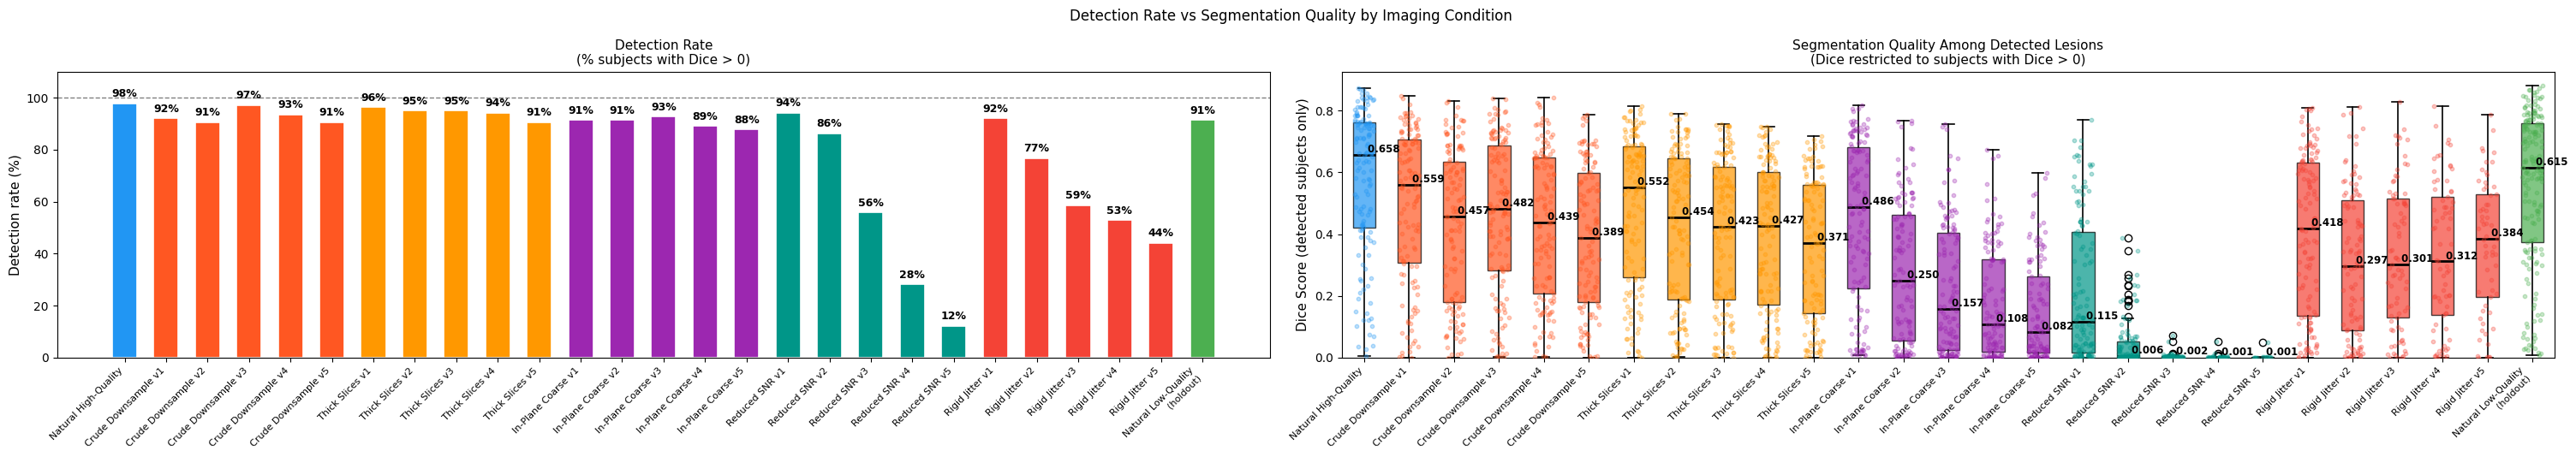


Figure 8 — Detection rate and Dice-among-detected summary:
  delta_det_vs_all: how much detection failures drag down overall mean Dice


,role,n_total,n_detected,det_rate_pct,median_dice_detected,mean_dice_detected,mean_dice_all,delta_det_vs_all
variant,,,,,,,,
Natural High-Quality,Training,138,135,97.8,0.658,0.575,0.562,0.012
Crude Downsample v1,Training,138,127,92.0,0.559,0.495,0.456,0.039
Crude Downsample v2,Training,138,125,90.6,0.457,0.426,0.385,0.040
Crude Downsample v3,Training,138,134,97.1,0.482,0.461,0.448,0.013
Crude Downsample v4,Training,138,129,93.5,0.439,0.429,0.401,0.028
Crude Downsample v5,Training,138,125,90.6,0.389,0.384,0.348,0.036
Thick Slices v1,Training,138,133,96.4,0.552,0.484,0.466,0.018
Thick Slices v2,Training,138,131,94.9,0.454,0.416,0.395,0.021
Thick Slices v3,Training,138,131,94.9,0.423,0.400,0.380,0.020


In [165]:
dice_col = "hard_dice_at_0.50" if "hard_dice_at_0.50" in all_df.columns else "soft_dice"

# Build per-variant arrays of detected-only Dice
det_rates, dice_detected_arrays, labels_plot, colors_plot = [], [], [], []
for v in VARIANT_ORDER:
    sub  = all_df[all_df["variant"] == v]
    dice = sub[dice_col].dropna()
    if len(dice) == 0:
        continue
    det_rates.append(100 * (dice > 0).mean())
    dice_detected_arrays.append(dice[dice > 0].values)
    labels_plot.append(VARIANT_LABEL_MAP.get(v, v).replace(" (holdout)", "\n(holdout)"))
    colors_plot.append(VARIANT_COLORS.get(v, "#aaa"))

x = np.arange(len(labels_plot))

fig, axes = plt.subplots(1, 2, figsize=(max(20, 0.75 * len(labels_plot) + 10), 6))
fig.suptitle("Detection Rate vs Segmentation Quality by Imaging Condition", fontsize=12)

# ── Left panel: Detection rate bar chart ──────────────────────────────────────
ax = axes[0]
bar_kw = dict(edgecolor="white", linewidth=1.2, width=0.6)
bars = ax.bar(x, det_rates, color=colors_plot, **bar_kw)
ax.set_xticks(x); ax.set_xticklabels(labels_plot, fontsize=8, rotation=45, ha="right")
ax.set_ylabel("Detection rate (%)", fontsize=11)
ax.set_ylim(0, 110)
ax.set_title("Detection Rate\n(% subjects with Dice > 0)", fontsize=11)
ax.axhline(100, color="gray", linestyle="--", lw=1)
for bar, val in zip(bars, det_rates):
    ax.text(bar.get_x() + bar.get_width()/2, val + 1.5,
            f"{val:.0f}%", ha="center", va="bottom", fontsize=9, fontweight="bold")

# ── Right panel: Dice-among-detected — box-whisker matching Fig 1 style ───────
ax = axes[1]
bp = ax.boxplot(dice_detected_arrays, patch_artist=True, widths=0.5,
                medianprops=dict(color="black", linewidth=2),
                whiskerprops=dict(linewidth=1.2),
                capprops=dict(linewidth=1.2))
for patch, col in zip(bp["boxes"], colors_plot):
    patch.set_facecolor(col)
    patch.set_alpha(0.7)

rng = np.random.default_rng(42)
for j, (arr, col) in enumerate(zip(dice_detected_arrays, colors_plot)):
    jx = rng.uniform(j + 0.78, j + 1.22, size=len(arr))
    ax.scatter(jx, arr, alpha=0.3, s=10, color=col, zorder=3)

# Median value labels on the black median bars
for j, arr in enumerate(dice_detected_arrays):
    med = float(np.median(arr))
    ax.text(j + 1, med, f" {med:.3f}", va="bottom", ha="left",
            fontsize=8.5, color="black", fontweight="bold", zorder=5)

ax.set_xticks(range(1, len(labels_plot) + 1))
ax.set_xticklabels(labels_plot, fontsize=8, rotation=45, ha="right")
ax.set_ylabel("Dice Score (detected subjects only)", fontsize=11)
ax.set_ylim(bottom=0)
ax.set_title("Segmentation Quality Among Detected Lesions\n(Dice restricted to subjects with Dice > 0)", fontsize=11)

plt.tight_layout()
plt.subplots_adjust(bottom=0.30)
plt.savefig(SAVE_DIR / "fig8_detection_vs_quality.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Detection vs quality summary table ────────────────────────────────────────
_det_rows = []
for v, det_r, det_arr, lbl in zip(VARIANT_ORDER[:len(det_rates)], det_rates, dice_detected_arrays, labels_plot):
    sub   = all_df[all_df["variant"] == v]
    dice  = sub[dice_col].dropna()
    n_tot = len(dice)
    n_det = int((dice > 0).sum())
    _det_rows.append({
        "variant":              lbl.replace("\n", " "),
        "role":                 "Holdout" if v in HOLDOUT_VARIANTS else "Training",
        "n_total":              n_tot,
        "n_detected":           n_det,
        "det_rate_pct":         round(float(det_r), 1),
        "median_dice_detected": round(float(np.median(det_arr)), 3) if len(det_arr) else float("nan"),
        "mean_dice_detected":   round(float(np.mean(det_arr)),   3) if len(det_arr) else float("nan"),
        "mean_dice_all":        round(float(dice.mean()), 3),
        "delta_det_vs_all":     round(float(np.mean(det_arr) - dice.mean()), 3) if len(det_arr) else float("nan"),
    })

_det_df = pd.DataFrame(_det_rows).set_index("variant")
print("\nFigure 8 — Detection rate and Dice-among-detected summary:")
print("  delta_det_vs_all: how much detection failures drag down overall mean Dice")
display(_det_df)


## Figure 8: Detection Rate vs Segmentation Quality — Interpretation

**What the plot shows:** Two bar charts: left shows the detection rate (% subjects where the model produces any non-zero Dice) per imaging condition; right shows the mean Dice *only among subjects where the lesion was detected*. This decomposition separates the two failure modes.

**Key findings and their meaning for stroke lesion segmentation:**

- **Two orthogonal failure modes:** Overall mean Dice conflates (a) the model completely missing a lesion (detection failure, Dice = 0) and (b) the model finding the lesion but with imprecise boundaries (quality failure, Dice > 0 but low). These require different fixes: detection failures call for recall-boosting training strategies (focal loss, harder negatives, lower detection threshold); quality failures call for boundary refinement and better resolution.
- **delta_det_vs_all:** This column quantifies how much detection failures drag down the reported mean Dice. A large delta (e.g. 0.10) means that if the model just detected all lesions, mean Dice would rise by 10 points — detection is the dominant bottleneck. A small delta means the model reliably finds lesions but struggles with boundary precision.
- **Detection rate under degradation:** If detection rate drops substantially (e.g. from 95% on HiRes to 78% on ThickSlices), it means degradation causes complete lesion misses, not just boundary errors. This is the most clinically severe failure — a completely missed lesion = no treatment planning guidance at all.
- **Quality (Dice-among-detected) under degradation:** If Dice-among-detected stays stable across variants while overall mean Dice drops, the degradation is causing more misses but not affecting the boundary quality of lesions the model does find. The model architecture may be robust to image quality in its boundary-drawing but fragile at the detection stage.
- **Natural Low-Res holdout comparison:** If the Natural Low-Res holdout shows a different detection/quality trade-off pattern from the synthetic variants (e.g., lower detection rate but higher Dice-among-detected), this reveals that the synthetic augmentation teaches the model to try harder on blurry images (reducing missed detections) but real low-res images have quality characteristics that don't match the synthetic distribution.
- **Actionable threshold:** Variants with det_rate < 90% should be flagged as needing targeted training intervention. Variants with high det_rate but mean_dice_detected < 0.50 are candidates for boundary-sharpening post-processing or test-time augmentation.


**§ 14 — Non-linear sensitivity analysis (cubic B-spline OLS).** Fits an ordinary-least-squares model with four-degree-of-freedom natural cubic B-spline basis expansions for each quality metric, with cluster-robust standard errors grouped by subject. This non-parametric alternative relaxes the linearity assumption of the primary LME and serves as a sensitivity check: close agreement between the spline and linear holdout metrics supports the adequacy of the linear specification; substantial divergence suggests non-linear quality–accuracy relationships that may warrant further investigation.

In [166]:
# Optional non-linear sensitivity model (GAM-like with cubic B-splines + clustered SEs)
if not active_predictors:
    print("No varying quality predictors available; skipping spline model.")
else:
    spline_terms = [f"bs({col}, df=4, degree=3, include_intercept=False)" for col in active_predictors]
    spline_formula = "1 + " + " + ".join(spline_terms)

    X_train = dmatrix(spline_formula, train_df, return_type="dataframe")
    if train_df["misalign"].nunique() > 1:
        X_train["misalign"] = train_df["misalign"].values

    spline_result = sm.OLS(train_df["logit_dice"], X_train).fit(
        cov_type="cluster",
        cov_kwds={"groups": train_df[GROUP_COL]},
    )

    print(spline_result.summary().tables[0])

    # Holdout prediction for comparison.
    # Clip to training bounds to avoid spline basis extrapolation errors.
    holdout_for_spline = holdout_df.copy()
    for col in active_predictors:
        lo = float(train_df[col].min())
        hi = float(train_df[col].max())
        holdout_for_spline[col] = holdout_for_spline[col].clip(lo, hi)

    X_holdout = dmatrix(X_train.design_info, holdout_for_spline, return_type="dataframe")
    for col in X_train.columns:
        if col not in X_holdout.columns:
            X_holdout[col] = 0.0
    X_holdout = X_holdout[X_train.columns]

    holdout_df["pred_logit_spline"] = spline_result.predict(X_holdout)
    holdout_df["pred_soft_dice_spline"] = expit(holdout_df["pred_logit_spline"])

    obs = holdout_df[OUTCOME].to_numpy(dtype=float)
    pred_spline = holdout_df["pred_soft_dice_spline"].to_numpy(dtype=float)
    res_spline = obs - pred_spline

    spline_metrics = pd.Series(
        {
            "mae_spline": float(np.mean(np.abs(res_spline))),
            "rmse_spline": float(np.sqrt(np.mean(res_spline ** 2))),
            "bias_spline": float(np.mean(res_spline)),
            "pearson_r_spline": float(np.corrcoef(obs, pred_spline)[0, 1]),
        }
    )
    print(spline_metrics.to_string())


                            OLS Regression Results                            
Dep. Variable:             logit_dice   R-squared:                       0.335
Model:                            OLS   Adj. R-squared:                  0.333
Method:                 Least Squares   F-statistic:                     129.8
Date:                Fri, 17 Apr 2026   Prob (F-statistic):           1.54e-62
Time:                        16:27:43   Log-Likelihood:                -10222.
No. Observations:                3588   AIC:                         2.046e+04
Df Residuals:                    3578   BIC:                         2.053e+04
Df Model:                           9                                         
Covariance Type:              cluster                                         
mae_spline          0.295127
rmse_spline         0.358383
bias_spline         0.086369
pearson_r_spline    0.064202


## Interpretation Checklist

- Check whether quality predictors actually vary by degradation (see the within-key spread table).
- If predictors do not vary across cohorts, the model can only learn subject-level associations, not degradation penalties.
- Use the holdout calibration bias (`observed - predicted`) to quantify any additional natural low-res penalty.
- If needed, recompute quality metrics directly on degraded images before final manuscript-level inference.


**§ 21 — Fixed-effect collinearity diagnosis (Variance Inflation Factor).** Uses the exact fixed-effect design matrix from the fitted mixed-effects model (`mixed_result.model.exog`) to quantify how much collinearity is inflating the uncertainty of each remaining coefficient in the reduced v2 model. For predictor *j*, VIF\(_j\) = 1 / (1 − R²\(_j\)), where R²\(_j\) is obtained by regressing that predictor on all of the other fixed effects. A VIF near 1 indicates negligible collinearity; values above ~5 suggest meaningful inflation, and values above ~10 suggest severe instability. The square-root of VIF is especially useful here because it directly reports the multiplicative inflation in the coefficient standard error.

Variance Inflation Factor (VIF) diagnostics from the fitted mixed-model fixed-effect matrix:
  VIF quantifies how much predictor collinearity inflates coefficient variance.
  sqrt(VIF) is the corresponding standard-error inflation factor.


,label,vif,sqrt_vif,tolerance
term,,,,
z_mf_lap_var,Laplacian Variance (higher z = sharper edges),4.49,2.12,0.223
misalign,Misalignment flag (1 = RigidJitter variant),3.29,1.81,0.304
z_mf_fwhm_mm,FWHM blur (higher z = more blur),1.71,1.31,0.586
z_log_lesion_mm3,Lesion Volume log(mm³) (higher z = larger lesion),1.07,1.03,0.934


Top pairwise correlations among fixed effects:


,pair,r,abs_r
3,Laplacian Variance (higher z = sharper edges) ...,0.810,0.810
0,FWHM blur (higher z = more blur) vs Laplacia...,-0.594,0.594
1,FWHM blur (higher z = more blur) vs Misalign...,-0.341,0.341
2,FWHM blur (higher z = more blur) vs Lesion V...,-0.187,0.187
4,Laplacian Variance (higher z = sharper edges) ...,0.146,0.146


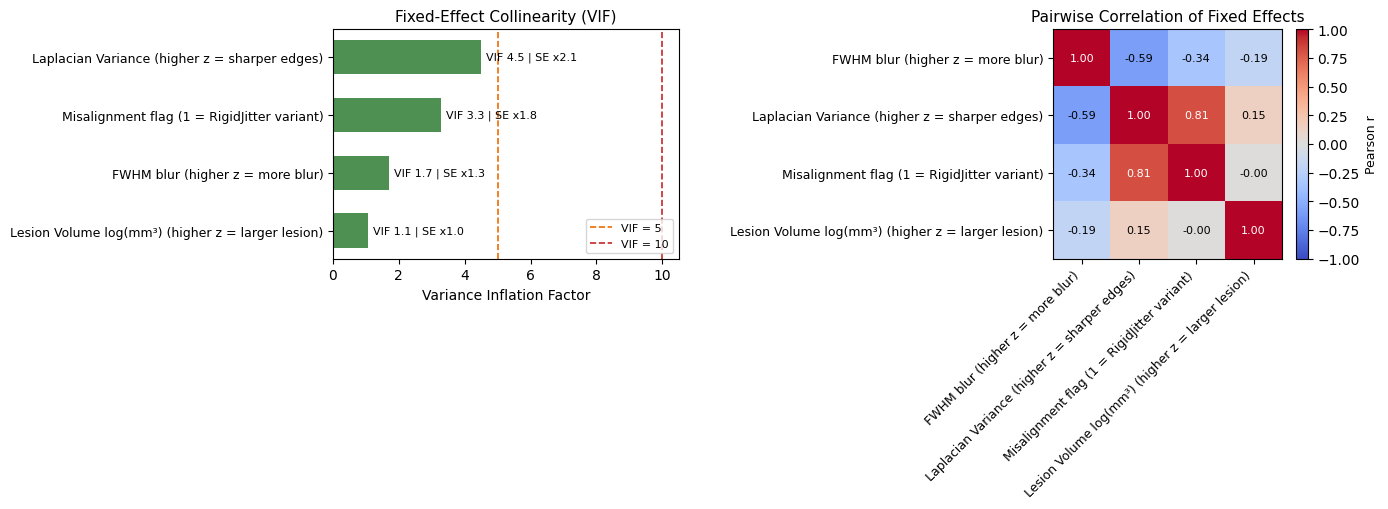

In [167]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from IPython.display import display
from statsmodels.stats.outliers_influence import variance_inflation_factor

RUNS_ROOT = Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs")
RUN_DIRS = sorted(RUNS_ROOT.glob("*/test_eval"))
if not RUN_DIRS:
    raise FileNotFoundError(f"No test_eval directories found under {RUNS_ROOT}")
PRIMARY_RUN_DIR = RUN_DIRS[-1]

if "TERM_LABELS" not in globals():
    TERM_LABELS = {
        "z_mf_fwhm_mm": "FWHM blur\n(higher z = more blur)",
        "z_mf_lap_var": "Laplacian Variance\n(higher z = sharper edges)",
        "misalign": "Misalignment flag\n(1 = RigidJitter variant)",
        "z_log_lesion_mm3": "Lesion Volume log(mm^3)\n(higher z = larger lesion)",
    }

if "SAVE_DIR" not in globals():
    SAVE_DIR = PRIMARY_RUN_DIR

if "mixed_result" not in globals():
    def latest_csv_any(pattern: str):
        matches = sorted(path for run in RUN_DIRS for path in run.glob(pattern))
        return matches[-1] if matches else None

    variant_globs = [
        {"variant": "hires", "cohort": "hires", "role": "natural", "glob": "test_hires_metrics_with_manifest_*.csv"},
    ]
    for family, prefix in [
        ("crude", "crude"),
        ("thick_slice", "thickslices"),
        ("inplane_coarsening", "inplane"),
        ("reduced_snr", "reducedsnr"),
        ("rigid_jitter", "rigidjitter"),
    ]:
        for level in range(1, 6):
            variant_globs.append({
                "variant": f"{family}_v{level}",
                "cohort": "hires",
                "role": "degraded",
                "glob": f"test_{prefix}_v{level}_metrics_with_manifest_*.csv",
            })

    file_specs = []
    for entry in variant_globs:
        path = latest_csv_any(entry["glob"])
        if path is None:
            print(f"[warn] no CSV found for variant '{entry['variant']}' (glob: {entry['glob']}); skipping.")
            continue
        file_specs.append({
            "variant": entry["variant"],
            "cohort": entry["cohort"],
            "role": entry["role"],
            "path": str(path),
            "source_run": path.parent.parent.name,
        })

    if not file_specs:
        raise RuntimeError("No CSV files found for standalone VIF rebuild.")

    required_manifest_cols = ["key", "soft_dice", "img_path", "mf_fwhm_mm", "mf_hi_freq_energy", "mf_lap_var"]
    dfs = {}
    for spec in file_specs:
        path = Path(spec["path"])
        df = pd.read_csv(path)
        missing_cols = [c for c in required_manifest_cols if c not in df.columns]
        if missing_cols:
            raise ValueError(
                f"{path.name} is missing required manifest columns: {missing_cols}. "
                "Use the *_metrics_with_manifest_*.csv file for this analysis."
            )
        if "dataset_tag" not in df.columns:
            df["dataset_tag"] = spec["cohort"]
        df["cohort"] = spec["cohort"]
        df["variant"] = spec["variant"]
        df["role"] = spec["role"]
        df["source_file"] = path.name
        df["source_run"] = spec["source_run"]
        dfs[spec["variant"]] = df

    all_df = pd.concat(dfs.values(), ignore_index=True)
    all_df["key"] = all_df["key"].astype(str)

    qm_dir = Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/Image_Quality_Metrics")
    qm_csvs = sorted(qm_dir.glob("image_quality_metrics_all_variants_*.csv"))
    if not qm_csvs:
        raise FileNotFoundError(
            f"No image_quality_metrics_all_variants_*.csv found in {qm_dir}. "
            "Run ARC_ATLAS_Image_Quality_Metrics.ipynb first."
        )
    qm_path = qm_csvs[-1]
    print(f"Standalone VIF rebuild loading image-level quality metrics from: {qm_path.name}")
    qm = pd.read_csv(qm_path)
    qm_variant_map = {"test_hires": "hires"}
    for family_in, family_out in [
        ("Crude", "crude"),
        ("ThickSlices", "thick_slice"),
        ("InPlaneCoarse", "inplane_coarsening"),
        ("ReducedSNR", "reduced_snr"),
        ("RigidJitter", "rigid_jitter"),
    ]:
        for level in range(1, 6):
            qm_variant_map[f"{family_in}_v{level}"] = f"{family_out}_v{level}"
    qm["variant"] = qm["variant"].map(qm_variant_map).fillna(qm["variant"])
    qm["key"] = qm["key"].astype(str)
    qm = qm.rename(columns={
        "fwhm_mm": "mf_fwhm_mm",
        "hi_freq_energy": "mf_hi_freq_energy",
        "lap_var": "mf_lap_var",
    })[["key", "variant", "mf_fwhm_mm", "mf_hi_freq_energy", "mf_lap_var"]]

    for c in ["mf_fwhm_mm", "mf_hi_freq_energy", "mf_lap_var"]:
        if c in all_df.columns:
            all_df = all_df.drop(columns=[c])
    all_df = all_df.merge(qm, on=["key", "variant"], how="left")
    print("Standalone VIF rebuild QM merge NaNs:", all_df[["mf_fwhm_mm", "mf_hi_freq_energy", "mf_lap_var"]].isna().sum().to_dict())

    manifest = Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v4/data/splits/50_25_25/meta/_resolution_manifest_v2.csv")
    if manifest.exists():
        mf = pd.read_csv(manifest)[["key", "mask_ml_clean"]]
        mf["key"] = mf["key"].astype(str)
        mf["lesion_mm3"] = mf["mask_ml_clean"] * 1000
        mf = mf[["key", "lesion_mm3"]]
        if "lesion_mm3" in all_df.columns:
            all_df = all_df.drop(columns=["lesion_mm3"])
        all_df = all_df.merge(mf, on="key", how="left")
    else:
        all_df["lesion_mm3"] = np.nan
        print(f"WARNING: Resolution manifest not found at {manifest}")

    degraded_variants = [spec["variant"] for spec in file_specs if spec["role"] in ("natural", "degraded")]
    outcome = "soft_dice"
    group_col = "mf_key" if ("mf_key" in all_df.columns and all_df["mf_key"].notna().all()) else "key"
    all_quality_cols = ["mf_fwhm_mm", "mf_hi_freq_energy", "mf_lap_var"]
    model_quality_cols = ["mf_fwhm_mm", "mf_lap_var"]
    needed = [outcome, "cohort", "variant", "role", "dataset_tag", "key", group_col, "img_path", "lesion_mm3"] + all_quality_cols
    if "mf_bin" in all_df.columns:
        needed.append("mf_bin")
    work_df = all_df[[c for c in needed if c in all_df.columns]].copy()
    for col in [outcome] + all_quality_cols:
        work_df[col] = pd.to_numeric(work_df[col], errors="coerce")
    work_df[group_col] = work_df[group_col].astype(str)
    work_df["key"] = work_df["key"].astype(str)
    work_df["log_lesion_mm3"] = np.log1p(work_df["lesion_mm3"].clip(lower=0)) if "lesion_mm3" in work_df.columns else np.nan

    def derive_misalign_flag(df: pd.DataFrame) -> pd.Series:
        if "mf_bin" in df.columns:
            as_num = pd.to_numeric(df["mf_bin"], errors="coerce")
            uniq = set(as_num.dropna().unique().tolist())
            if uniq and uniq.issubset({0.0, 1.0}):
                return as_num.fillna(0).astype(int)
            text_hint = df["mf_bin"].astype(str).str.lower().str.contains("jitter|rigid|misalign|shift", regex=True)
            if bool(text_hint.any()):
                return text_hint.astype(int)
        variant_hint = df["variant"].astype(str).str.lower().str.contains("jitter|rigid|misalign|shift", regex=True)
        img_hint = df["img_path"].astype(str).str.lower().str.contains("jitter|rigid|misalign|shift", regex=True) if "img_path" in df.columns else pd.Series(False, index=df.index)
        return (variant_hint | img_hint).astype(int)

    work_df["misalign"] = derive_misalign_flag(work_df)
    train_df = work_df[work_df["variant"].isin(degraded_variants)].copy()
    train_df = train_df.dropna(subset=[outcome, group_col] + model_quality_cols).copy()

    active_predictors = []
    for col in model_quality_cols:
        mu = float(train_df[col].mean())
        sd = float(train_df[col].std(ddof=0))
        if not np.isfinite(sd) or sd < 1e-12:
            sd = 1.0
        zcol = f"z_{col}"
        train_df[zcol] = (train_df[col] - mu) / sd
        if float(train_df[zcol].std(ddof=0)) > 1e-12:
            active_predictors.append(zcol)

    if train_df["log_lesion_mm3"].notna().sum() > 0:
        les_mu = float(train_df["log_lesion_mm3"].mean())
        les_sd = float(train_df["log_lesion_mm3"].std(ddof=0)) or 1.0
        train_df["z_log_lesion_mm3"] = (train_df["log_lesion_mm3"] - les_mu) / les_sd
        has_lesion_size = train_df["z_log_lesion_mm3"].notna().sum() > 0
    else:
        has_lesion_size = False

    active_predictors_cat = ["C(variant)"] if (not active_predictors and train_df["variant"].nunique() > 1) else []
    eps = 1e-6
    clipped = np.clip(train_df[outcome].astype(float).values, eps, 1 - eps)
    train_df["logit_dice"] = np.log(clipped / (1 - clipped))

    import warnings

    fixed_terms = list(active_predictors) if active_predictors else list(active_predictors_cat)
    if train_df["misalign"].nunique() > 1:
        fixed_terms.append("misalign")
    if has_lesion_size and "z_log_lesion_mm3" not in fixed_terms:
        fixed_terms.append("z_log_lesion_mm3")
    rhs = " + ".join(fixed_terms) if fixed_terms else "1"
    mixed_formula = f"logit_dice ~ {rhs}"
    print("Standalone VIF rebuild using primary run dir:", PRIMARY_RUN_DIR)
    print("Standalone VIF rebuild formula:", mixed_formula)
    print("Standalone VIF rebuild grouping column:", group_col)
    mixed_model = smf.mixedlm(
        formula=mixed_formula,
        data=train_df,
        groups=train_df[group_col],
        re_formula="1",
    )

    optimizer_attempts = []
    mixed_result = None
    for method in ["bfgs", "cg", "powell", "nm", "lbfgs"]:
        try:
            with warnings.catch_warnings(record=True) as caught:
                warnings.simplefilter("always")
                candidate = mixed_model.fit(reml=False, method=method, maxiter=2000, disp=False)
            optimizer_attempts.append({
                "method": method,
                "status": "ok",
                "converged": bool(getattr(candidate, "converged", False)),
                "n_warnings": len(caught),
            })
            if getattr(candidate, "converged", False):
                mixed_result = candidate
                mixed_result_optimizer = method
                mixed_result_warnings = [str(w.message) for w in caught]
                break
        except Exception as exc:
            optimizer_attempts.append({
                "method": method,
                "status": f"failed: {type(exc).__name__}",
                "converged": False,
                "n_warnings": np.nan,
            })
            print(f"Standalone VIF rebuild attempt with {method} failed: {exc}")

    display(pd.DataFrame(optimizer_attempts))
    if mixed_result is None:
        raise RuntimeError(
            "Standalone VIF rebuild could not fit the mixed model with any optimizer. "
            f"Tried: {', '.join(pd.DataFrame(optimizer_attempts)['method'].astype(str))}"
        )

    print(f"Standalone VIF rebuild selected optimizer: {mixed_result_optimizer}")
    if mixed_result_warnings:
        print("Warnings from selected optimizer:")
        for msg in mixed_result_warnings:
            print(f"  - {msg}")
    print(f"Standalone VIF rebuild rows: {len(train_df)}")

term_label_map = TERM_LABELS.copy()

vif_exog = pd.DataFrame(
    mixed_result.model.exog,
    columns=mixed_result.model.exog_names,
)
vif_terms = [c for c in vif_exog.columns if c != "Intercept"]

if len(vif_terms) < 2:
    print("VIF is not informative with fewer than two fixed-effect predictors.")
else:
    vif_rows = []
    for term in vif_terms:
        col_idx = vif_exog.columns.get_loc(term)
        vif_val = float(variance_inflation_factor(vif_exog.values, col_idx))
        vif_rows.append(
            {
                "term": term,
                "label": term_label_map.get(term, term).replace("\n", " "),
                "vif": vif_val,
                "sqrt_vif": float(np.sqrt(vif_val)) if np.isfinite(vif_val) and vif_val >= 0 else np.nan,
                "tolerance": float(1.0 / vif_val) if np.isfinite(vif_val) and vif_val > 0 else np.nan,
            }
        )

    vif_table = pd.DataFrame(vif_rows).sort_values("vif", ascending=False).set_index("term")
    print("Variance Inflation Factor (VIF) diagnostics from the fitted mixed-model fixed-effect matrix:")
    print("  VIF quantifies how much predictor collinearity inflates coefficient variance.")
    print("  sqrt(VIF) is the corresponding standard-error inflation factor.")
    vif_display = vif_table.copy()
    vif_display["vif"] = vif_display["vif"].round(2)
    vif_display["sqrt_vif"] = vif_display["sqrt_vif"].round(2)
    vif_display["tolerance"] = vif_display["tolerance"].round(3)
    display(vif_display)

    predictor_corr = vif_exog[vif_terms].corr()
    abs_pairs = []
    cols = list(predictor_corr.columns)
    for i, left in enumerate(cols):
        for right in cols[i + 1:]:
            r_val = float(predictor_corr.loc[left, right])
            left_label = term_label_map.get(left, left).replace("\n", " ")
            right_label = term_label_map.get(right, right).replace("\n", " ")
            abs_pairs.append(
                {
                    "pair": f"{left_label}  vs  {right_label}",
                    "r": r_val,
                    "abs_r": abs(r_val),
                }
            )
    if abs_pairs:
        top_corr = pd.DataFrame(abs_pairs).sort_values("abs_r", ascending=False)
        print("Top pairwise correlations among fixed effects:")
        top_corr_display = top_corr[["pair", "r", "abs_r"]].head(5).copy()
        top_corr_display["r"] = top_corr_display["r"].round(3)
        top_corr_display["abs_r"] = top_corr_display["abs_r"].round(3)
        display(top_corr_display)

    fig, axes = plt.subplots(1, 2, figsize=(14, max(4.5, 0.8 * len(vif_table) + 2.0)))

    ax = axes[0]
    y = np.arange(len(vif_table))
    vif_colors = [
        "#c62828" if v >= 10 else "#ef6c00" if v >= 5 else "#2e7d32"
        for v in vif_table["vif"]
    ]
    bars = ax.barh(y, vif_table["vif"].values, color=vif_colors, alpha=0.85, height=0.6)
    ax.axvline(5, color="#ef6c00", linestyle="--", linewidth=1.2, label="VIF = 5")
    ax.axvline(10, color="#c62828", linestyle="--", linewidth=1.2, label="VIF = 10")
    ax.set_yticks(y)
    ax.set_yticklabels(vif_table["label"], fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel("Variance Inflation Factor", fontsize=10)
    ax.set_title("Fixed-Effect Collinearity (VIF)", fontsize=11)
    ax.legend(loc="lower right", fontsize=8, frameon=True)
    x_pad = max(float(vif_table["vif"].max()) * 0.02, 0.15)
    for i, (_, row) in enumerate(vif_table.iterrows()):
        bar = bars[i]
        ax.text(
            float(row["vif"]) + x_pad,
            bar.get_y() + bar.get_height() / 2,
            f"VIF {row['vif']:.1f} | SE x{row['sqrt_vif']:.1f}",
            va="center",
            fontsize=8,
        )

    ax = axes[1]
    corr_labels = [term_label_map.get(t, t).replace("\n", " ") for t in predictor_corr.columns]
    im = ax.imshow(predictor_corr.values, cmap="coolwarm", vmin=-1, vmax=1)
    ax.set_xticks(np.arange(len(corr_labels)))
    ax.set_yticks(np.arange(len(corr_labels)))
    ax.set_xticklabels(corr_labels, rotation=45, ha="right", fontsize=9)
    ax.set_yticklabels(corr_labels, fontsize=9)
    ax.set_title("Pairwise Correlation of Fixed Effects", fontsize=11)
    for i in range(predictor_corr.shape[0]):
        for j in range(predictor_corr.shape[1]):
            r_val = float(predictor_corr.iloc[i, j])
            ax.text(
                j,
                i,
                f"{r_val:.2f}",
                ha="center",
                va="center",
                fontsize=8,
                color="white" if abs(r_val) >= 0.65 else "black",
            )
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Pearson r", fontsize=9)

    plt.tight_layout()
    if "SAVE_DIR" in globals():
        plt.savefig(SAVE_DIR / "fig9_vif_collinearity.png", dpi=150, bbox_inches="tight")
    plt.show()

## Figure 9: VIF Collinearity Diagnostics — Interpretation

**What the plot shows:** The left panel reports the Variance Inflation Factor for each fixed effect in the mixed model. VIF = 1 means the predictor is orthogonal to the others; values above ~5 usually indicate meaningful multicollinearity, and values above ~10 indicate severe inflation of coefficient uncertainty. The annotation `SE x...` is \(\sqrt{\mathrm{VIF}}\), which is the multiplicative inflation in that coefficient’s standard error. The right panel shows the pairwise Pearson correlation matrix for the same fixed effects.

**How to read the reduced-model check:** In v2, HFE has already been removed from the fixed effects because it was nearly redundant with Laplacian variance in the earlier model. The purpose of this figure is therefore to verify that the *remaining* fixed effects (FWHM, LapVar, misalignment, lesion size) no longer suffer from the same instability. If any remaining predictor still shows a large VIF, its coefficient should be interpreted cautiously as a conditional effect after holding the others fixed.

**Practical takeaway for this notebook:** Low-to-moderate VIF values in the reduced model support the decision to drop HFE and make the remaining coefficient signs easier to interpret mechanistically. If a predictor still has a large VIF, the next step would be to simplify further, compare one-metric-at-a-time models, or replace overlapping metrics with a shared summary such as a principal component.

**§ 22 — Figure 10: Raw vs conditional LapVar relationship.**
This section visualises the source of the LapVar sign flip. The left panel shows the **raw Dice-scale** relationship between Laplacian variance and segmentation accuracy, which matches the intuitive scatterplot question: *as LapVar goes up, does Dice usually go up too?* The right panel shows an **adjusted** relationship after removing FWHM, misalignment, lesion volume, and subject identity from both variables first (using subject fixed effects for visualisation only). That adjusted slope answers nearly the same question as the mixed-model LapVar coefficient: *for two rows that are otherwise comparable, what does extra LapVar do?*

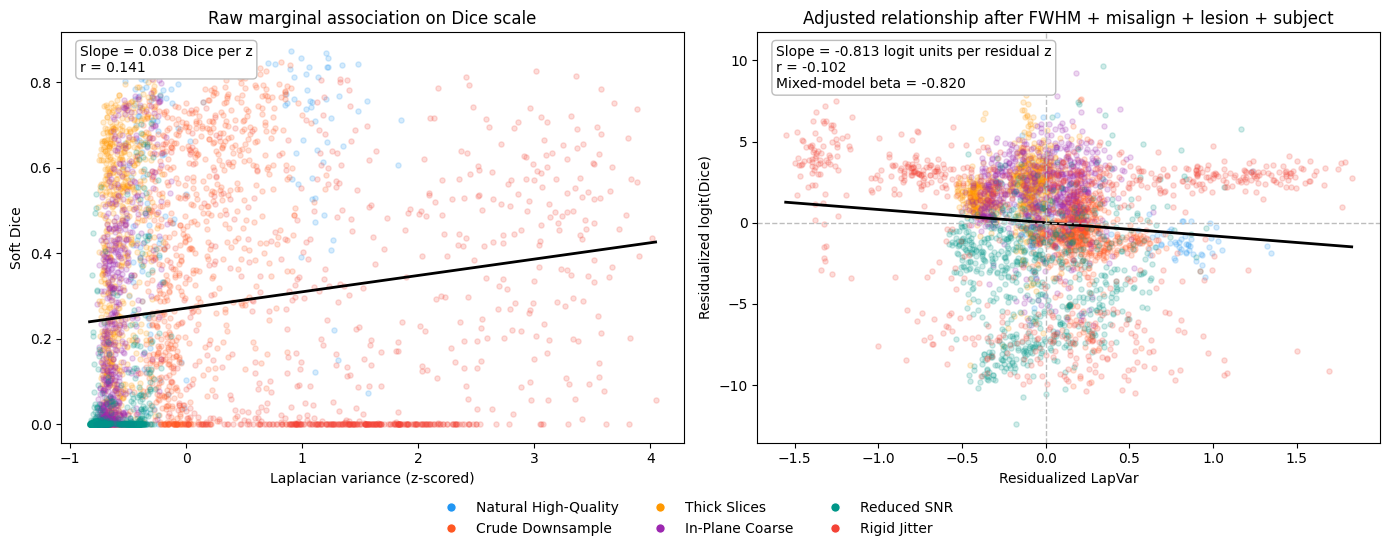


Figure 10 — LapVar marginal vs adjusted relationship:


,slope,correlation,question
view,,,
Raw Dice-scale slope,0.038,0.141,"When LapVar rises in the raw cloud, does Dice ..."
Adjusted partial slope,-0.813,-0.102,"After FWHM, misalignment, lesion volume, and s..."
Joint mixed-model coefficient,-0.820,NaN,Primary v2 model coefficient for LapVar


In [168]:
lapvar_viz_df = train_df.copy()
if "family" not in lapvar_viz_df.columns:
    lapvar_viz_df["family"] = lapvar_viz_df["variant"].map(_variant_family)

lapvar_viz_df = lapvar_viz_df.dropna(
    subset=["soft_dice", "logit_dice", "z_mf_lap_var", "z_mf_fwhm_mm", "misalign", "z_log_lesion_mm3", GROUP_COL]
).copy()

raw_fit = smf.ols("soft_dice ~ z_mf_lap_var", data=lapvar_viz_df).fit()
raw_r = float(lapvar_viz_df[["z_mf_lap_var", "soft_dice"]].corr().iloc[0, 1])

resid_y_model = smf.ols(
    f"logit_dice ~ z_mf_fwhm_mm + misalign + z_log_lesion_mm3 + C({GROUP_COL})",
    data=lapvar_viz_df,
).fit()
resid_x_model = smf.ols(
    f"z_mf_lap_var ~ z_mf_fwhm_mm + misalign + z_log_lesion_mm3 + C({GROUP_COL})",
    data=lapvar_viz_df,
).fit()

partial_df = pd.DataFrame({
    "resid_y": resid_y_model.resid,
    "resid_x": resid_x_model.resid,
    "family": lapvar_viz_df["family"].values,
})
partial_fit = smf.ols("resid_y ~ resid_x", data=partial_df).fit()
partial_r = float(partial_df[["resid_x", "resid_y"]].corr().iloc[0, 1])

family_order = [
    fam for fam in ["hires", "crude", "thick_slice", "inplane_coarsening", "reduced_snr", "rigid_jitter"]
    if fam in set(lapvar_viz_df["family"].astype(str).unique())
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

ax = axes[0]
for fam in family_order:
    sub = lapvar_viz_df[lapvar_viz_df["family"] == fam]
    ax.scatter(
        sub["z_mf_lap_var"],
        sub["soft_dice"],
        s=14,
        alpha=0.18,
        color=FAMILY_COLORS.get(fam, "#9e9e9e"),
        label=FAMILY_LABELS.get(fam, fam),
    )
x_grid = np.linspace(lapvar_viz_df["z_mf_lap_var"].min(), lapvar_viz_df["z_mf_lap_var"].max(), 200)
ax.plot(x_grid, raw_fit.predict(pd.DataFrame({"z_mf_lap_var": x_grid})), color="black", lw=2.0)
ax.set_xlabel("Laplacian variance (z-scored)")
ax.set_ylabel("Soft Dice")
ax.set_title("Raw marginal association on Dice scale")
ax.text(
    0.03,
    0.97,
    f"Slope = {raw_fit.params['z_mf_lap_var']:.3f} Dice per z\nr = {raw_r:.3f}",
    transform=ax.transAxes,
    va="top",
    ha="left",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="#bdbdbd"),
)

ax = axes[1]
for fam in family_order:
    sub = partial_df[partial_df["family"] == fam]
    ax.scatter(
        sub["resid_x"],
        sub["resid_y"],
        s=14,
        alpha=0.18,
        color=FAMILY_COLORS.get(fam, "#9e9e9e"),
    )
x_grid = np.linspace(partial_df["resid_x"].min(), partial_df["resid_x"].max(), 200)
ax.plot(
    x_grid,
    partial_fit.predict(pd.DataFrame({"resid_x": x_grid})),
    color="black",
    lw=2.0,
)
ax.axhline(0, color="#bdbdbd", lw=1, linestyle="--")
ax.axvline(0, color="#bdbdbd", lw=1, linestyle="--")
ax.set_xlabel("Residualized LapVar")
ax.set_ylabel("Residualized logit(Dice)")
ax.set_title("Adjusted relationship after FWHM + misalign + lesion + subject")
ax.text(
    0.03,
    0.97,
    f"Slope = {partial_fit.params['resid_x']:.3f} logit units per residual z\nr = {partial_r:.3f}\nMixed-model beta = {mixed_result.fe_params['z_mf_lap_var']:.3f}",
    transform=ax.transAxes,
    va="top",
    ha="left",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="#bdbdbd"),
)

handles = [
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=FAMILY_COLORS.get(fam, "#9e9e9e"), markersize=7, label=FAMILY_LABELS.get(fam, fam))
    for fam in family_order
]
fig.legend(handles=handles, loc="lower center", ncol=min(3, len(handles)), frameon=False)
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.savefig(SAVE_DIR / "fig10_lapvar_raw_vs_adjusted.png", dpi=150, bbox_inches="tight")
plt.show()

lapvar_relationship_df = pd.DataFrame([
    {
        "view": "Raw Dice-scale slope",
        "slope": float(raw_fit.params["z_mf_lap_var"]),
        "correlation": raw_r,
        "question": "When LapVar rises in the raw cloud, does Dice usually rise too?",
    },
    {
        "view": "Adjusted partial slope",
        "slope": float(partial_fit.params["resid_x"]),
        "correlation": partial_r,
        "question": "After FWHM, misalignment, lesion volume, and subject are held fixed, what does extra LapVar do?",
    },
    {
        "view": "Joint mixed-model coefficient",
        "slope": float(mixed_result.fe_params["z_mf_lap_var"]),
        "correlation": np.nan,
        "question": "Primary v2 model coefficient for LapVar",
    },
]).set_index("view")

print("\nFigure 10 — LapVar marginal vs adjusted relationship:")
display(lapvar_relationship_df.round(3))


## Figure 10: Why LapVar Can Be Positive in a Dice Scatterplot but Negative in the Joint Model

**What the plot shows:** The left panel matches the intuition you described directly: on the raw Dice scale, higher LapVar tends to come with higher Dice. The right panel is the conditional association after the other modeled structure has been removed first. The joint mixed-model coefficient lines up with the adjusted panel, not the raw Dice scatter.

**Practical interpretation:** In this dataset, LapVar behaves like a broad sharpness proxy in the raw Dice plot, so the marginal slope is positive. But once FWHM already explains the dominant blur axis, the remaining part of LapVar is no longer “cleanly sharper image”; it becomes the leftover edge-energy signal after blur, lesion size, misalignment, and subject baseline are accounted for. That leftover component trends negative, which is exactly why the joint coefficient flips sign.

**§ 23 — Figure 11: What the random effect and residual actually look like.**
On the logit-Dice scale, the fitted mixed model is additive:

`observed = fixed-effects prediction + subject random intercept + residual`

This figure makes those two leftover pieces concrete. The **random intercept** is a subject-wide vertical shift shared by all rows from the same subject. The **residual** is the row-specific leftover after both the fixed effects and that subject shift are applied.

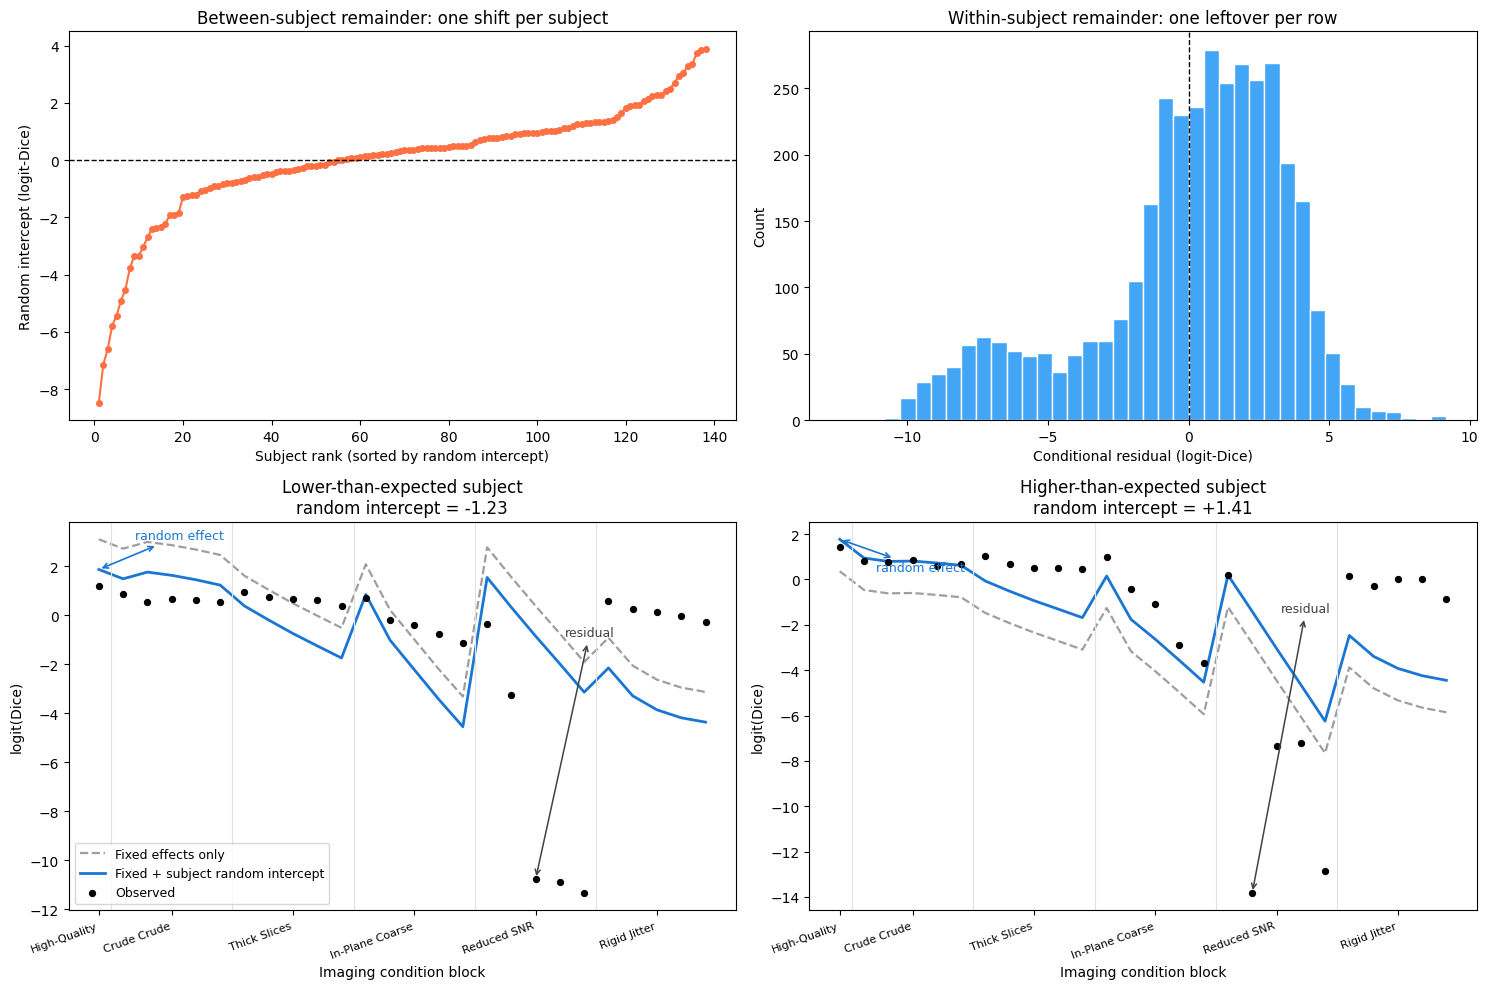


Figure 11 — Random intercept vs residual summary:


,unit,what_it_does,sd_logit
component,,,
Random subject intercept,one value per subject,Shifts that subject's whole fitted trajectory ...,2.026
Conditional residual,one value per observation,Moves an individual row away from the subject-...,3.534


In [169]:
fit_row_order = pd.Index(getattr(mixed_result.model.data, "row_labels", train_df.index))
decomp_df = train_df.loc[fit_row_order].copy()
decomp_df["family"] = decomp_df["variant"].map(_variant_family)

decomp_df["fixed_only_logit"] = mixed_result.model.exog @ mixed_result.fe_params.reindex(mixed_result.model.exog_names).to_numpy()

random_effect_map = {}
for group_id, value in mixed_result.random_effects.items():
    if hasattr(value, "iloc"):
        random_effect_map[group_id] = float(value.iloc[0])
    elif isinstance(value, dict):
        random_effect_map[group_id] = float(next(iter(value.values())))
    elif isinstance(value, (list, tuple, np.ndarray)):
        random_effect_map[group_id] = float(value[0])
    else:
        random_effect_map[group_id] = float(value)

decomp_df["random_intercept"] = decomp_df[GROUP_COL].map(random_effect_map).astype(float)
decomp_df["conditional_logit"] = decomp_df["fixed_only_logit"] + decomp_df["random_intercept"]
decomp_df["conditional_residual_logit"] = decomp_df["logit_dice"] - decomp_df["conditional_logit"]

subject_effects_df = (
    decomp_df[[GROUP_COL, "random_intercept", "z_log_lesion_mm3"]]
    .drop_duplicates()
    .sort_values("random_intercept")
    .reset_index(drop=True)
)
subject_effects_df["subject_rank"] = np.arange(1, len(subject_effects_df) + 1)

low_idx = max(0, int(round(0.15 * (len(subject_effects_df) - 1))))
high_idx = min(len(subject_effects_df) - 1, int(round(0.85 * (len(subject_effects_df) - 1))))
example_subjects = [
    ("Lower-than-expected subject", subject_effects_df.iloc[low_idx][GROUP_COL]),
    ("Higher-than-expected subject", subject_effects_df.iloc[high_idx][GROUP_COL]),
]

ordered_variants = [v for v in DEGRADED_VARIANTS if v in set(decomp_df["variant"].astype(str).unique())]
variant_tick_positions = []
variant_tick_labels = []
for idx, fam in enumerate(["hires", "crude", "thick_slice", "inplane_coarsening", "reduced_snr", "rigid_jitter"]):
    members = [i + 1 for i, v in enumerate(ordered_variants) if _variant_family(v) == fam]
    if members:
        variant_tick_positions.append(int(np.median(members)))
        variant_tick_labels.append(FAMILY_LABELS.get(fam, fam).replace("Natural ", "").replace("Downsample", "Crude"))

family_boundaries = []
last_family = None
for i, variant in enumerate(ordered_variants, start=1):
    fam = _variant_family(variant)
    if last_family is not None and fam != last_family:
        family_boundaries.append(i - 0.5)
    last_family = fam

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

ax = axes[0, 0]
ax.plot(subject_effects_df["subject_rank"], subject_effects_df["random_intercept"], color="#FF7043", lw=1.5)
ax.scatter(subject_effects_df["subject_rank"], subject_effects_df["random_intercept"], color="#FF7043", s=16)
ax.axhline(0, color="black", linestyle="--", lw=1)
ax.set_xlabel("Subject rank (sorted by random intercept)")
ax.set_ylabel("Random intercept (logit-Dice)")
ax.set_title("Between-subject remainder: one shift per subject")

ax = axes[0, 1]
ax.hist(decomp_df["conditional_residual_logit"], bins=40, color="#42A5F5", edgecolor="white")
ax.axvline(0, color="black", linestyle="--", lw=1)
ax.set_xlabel("Conditional residual (logit-Dice)")
ax.set_ylabel("Count")
ax.set_title("Within-subject remainder: one leftover per row")

for ax, (title, subject_id) in zip(axes[1], example_subjects):
    sub = decomp_df[decomp_df[GROUP_COL] == subject_id].copy()
    sub["variant"] = pd.Categorical(sub["variant"], categories=ordered_variants, ordered=True)
    sub = sub.sort_values("variant")
    x = np.arange(1, len(sub) + 1)

    ax.plot(x, sub["fixed_only_logit"], color="#9e9e9e", lw=1.6, linestyle="--", label="Fixed effects only")
    ax.plot(x, sub["conditional_logit"], color="#1976d2", lw=2.0, label="Fixed + subject random intercept")
    ax.scatter(x, sub["logit_dice"], color="black", s=18, zorder=3, label="Observed")

    for boundary in family_boundaries:
        ax.axvline(boundary, color="#e0e0e0", lw=0.8)

    j_shift = 0
    ax.annotate(
        "random effect",
        xy=(x[j_shift], sub["conditional_logit"].iloc[j_shift]),
        xytext=(x[j_shift] + 1.5, sub["fixed_only_logit"].iloc[j_shift]),
        arrowprops=dict(arrowstyle="<->", color="#1976d2", lw=1.2),
        color="#1976d2",
        fontsize=9,
    )

    j_resid = int(np.argmax(np.abs(sub["logit_dice"].to_numpy() - sub["conditional_logit"].to_numpy())))
    ax.annotate(
        "residual",
        xy=(x[j_resid], sub["logit_dice"].iloc[j_resid]),
        xytext=(x[j_resid] + 1.2, sub["conditional_logit"].iloc[j_resid]),
        arrowprops=dict(arrowstyle="<->", color="#424242", lw=1.1),
        color="#424242",
        fontsize=9,
    )

    ax.set_xticks(variant_tick_positions)
    ax.set_xticklabels(variant_tick_labels, rotation=20, ha="right", fontsize=8)
    ax.set_ylabel("logit(Dice)")
    ax.set_title(f"{title}\nrandom intercept = {sub['random_intercept'].iloc[0]:+.2f}")

axes[1, 0].legend(loc="lower left", frameon=True, fontsize=9)
axes[1, 0].set_xlabel("Imaging condition block")
axes[1, 1].set_xlabel("Imaging condition block")

plt.tight_layout()
plt.savefig(SAVE_DIR / "fig11_random_effect_vs_residual.png", dpi=150, bbox_inches="tight")
plt.show()

random_vs_residual_df = pd.DataFrame([
    {
        "component": "Random subject intercept",
        "unit": "one value per subject",
        "what_it_does": "Shifts that subject's whole fitted trajectory up or down together",
        "sd_logit": float(subject_effects_df["random_intercept"].std(ddof=1)),
    },
    {
        "component": "Conditional residual",
        "unit": "one value per observation",
        "what_it_does": "Moves an individual row away from the subject-specific fitted line",
        "sd_logit": float(decomp_df["conditional_residual_logit"].std(ddof=1)),
    },
]).set_index("component")

print("\nFigure 11 — Random intercept vs residual summary:")
display(random_vs_residual_df.round(3))


## Figure 11: Random Effect vs Residual — Interpretation

**What the plot shows:** The top-left panel sorts subjects by their fitted random intercept. That is the leftover subject-wide shift after the fixed effects. The top-right histogram shows the row-level residuals that remain even after each subject gets their own intercept. The bottom panels make the decomposition tangible for two example subjects.

**How to read it:**

- The gap between the dashed grey line and the solid blue line is the **random effect**: the same vertical shift applied to every row from that subject.
- The gap between the solid blue line and the black point is the **residual**: a row-specific leftover that changes from one variant to the next.
- This is why the mixed model is useful here. Repeated degradations of the same lesion are not treated as independent because they share a subject-level baseline shift before the row-level residual is computed.

**§ 24 — Final model comparison.**

Five models are compared, each with a random intercept per subject:

1. **Degradation Method** — `C(family) + lesion_vol + (1|subject)` — categorical baseline; which degradation families hurt most?
2. **Family × Lesion Vol** — `C(family) * lesion_vol + (1|subject)` — do degradation penalties depend on lesion size?
3. **Joint FWHM + LapVar** — `FWHM + LapVar + misalign + lesion_vol + (1|subject)` — additive continuous model; LapVar is negative here (the sign flip)
4. **LapVar-only** — `LapVar + misalign + lesion_vol + (1|subject)` — same metric *without* FWHM; LapVar is positive here, proving the sign flip is suppression
5. **LapVar × FWHM** — `FWHM * LapVar + misalign + lesion_vol + (1|subject)` — interaction between blur and edge energy

Models 1–2 are categorical and don't need the misalignment flag. Models 3–5 include it.

### How to read a model with an interaction term (Model 5)

When a model includes `FWHM * LapVar`, it expands to three terms: `FWHM + LapVar + FWHM:LapVar`. The coefficients mean different things than in the additive model:

- **FWHM main effect** = the effect of FWHM *when LapVar is at its mean* (since predictors are z-scored, mean = 0)
- **LapVar main effect** = the effect of LapVar *when FWHM is at its mean*
- **FWHM:LapVar interaction** = how much the FWHM effect changes per unit increase in LapVar (or equivalently, how much the LapVar effect changes per unit increase in FWHM)

So in the interaction model, the LapVar coefficient is NOT "the effect of LapVar on Dice" in general — it's the effect *at average blur*. At higher blur, the total LapVar effect is: `LapVar_coef + interaction_coef × FWHM_value`. If the interaction is strongly negative, LapVar becomes increasingly harmful at high blur levels, even if the main effect alone might look different.

This is why coefficients in an interaction model can look very different from the additive model — they're answering a different question ("what's the effect at the mean of the other predictor?" vs "what's the average effect across all levels?").

  Degradation Method         optimizer=bfgs  AIC=19226.6  ICC=0.245  n_fe=6
  Family × Lesion Vol        optimizer=bfgs  AIC=19071.3  ICC=0.255  n_fe=11
  Joint FWHM+LapVar          optimizer=bfgs  AIC=19700.5  ICC=0.259  n_fe=4
  LapVar-only                optimizer=bfgs  AIC=20729.8  ICC=0.157  n_fe=3
  LapVar × FWHM              optimizer=bfgs  AIC=19202.4  ICC=0.307  n_fe=5

Figure 12 — Final model comparison:


,group,model,role,n_fixed,logLik,AIC,delta_AIC,BIC,ICC
0,Categorical,Family × Lesion Vol,Lesion-size-dependent degradation penalties,11,-9521.67,19071.33,0.00,19157.93,0.26
1,Continuous,LapVar × FWHM,Interaction: blur × edge energy,5,-9593.19,19202.38,131.05,19251.87,0.31
2,Categorical,Degradation Method,Categorical baseline,6,-9604.30,19226.60,155.27,19282.27,0.25
3,Continuous,Joint FWHM+LapVar,Additive continuous (sign flip reference),4,-9843.26,19700.53,629.20,19743.82,0.26
4,LapVar investigation,LapVar-only,LapVar without FWHM — proves sign flip is supp...,3,-10358.91,20729.81,1658.48,20766.93,0.16



  LapVar Coefficient: The Sign Flip


,LapVar_coef,ci_low,ci_high,p_value,sig,sign,FWHM_in_model,interpretation
model,,,,,,,,
Joint FWHM+LapVar,-0.820200,-1.082728,-0.557672,9.160113e-10,***,NEGATIVE,True,Suppressed by FWHM: residual LapVar captures a...
LapVar-only,1.399286,1.132194,1.666378,9.802264e-25,***,POSITIVE,False,LapVar alone: sharper = better Dice (expected ...
LapVar × FWHM,-5.411603,-5.869572,-4.953633,1.153999e-118,***,NEGATIVE,True,Main effect at mean FWHM (interaction model)



  Interaction Term Significance


,model,interaction_term,coef,ci_low,ci_high,p_value,sig
0,Family × Lesion Vol,"C(family, Treatment(reference='hires'))[T.crud...",0.8899,0.2887,1.4911,0.0037,**
1,Family × Lesion Vol,"C(family, Treatment(reference='hires'))[T.thic...",0.2310,-0.3702,0.8322,0.4515,ns
2,Family × Lesion Vol,"C(family, Treatment(reference='hires'))[T.inpl...",1.4328,0.8316,2.0340,0.0000,***
3,Family × Lesion Vol,"C(family, Treatment(reference='hires'))[T.redu...",0.1869,-0.4143,0.7881,0.5423,ns
4,Family × Lesion Vol,"C(family, Treatment(reference='hires'))[T.rigi...",2.0198,1.4186,2.6209,0.0000,***
5,LapVar × FWHM,z_mf_fwhm_mm:z_mf_lap_var,-3.1289,-3.3930,-2.8649,0.0000,***


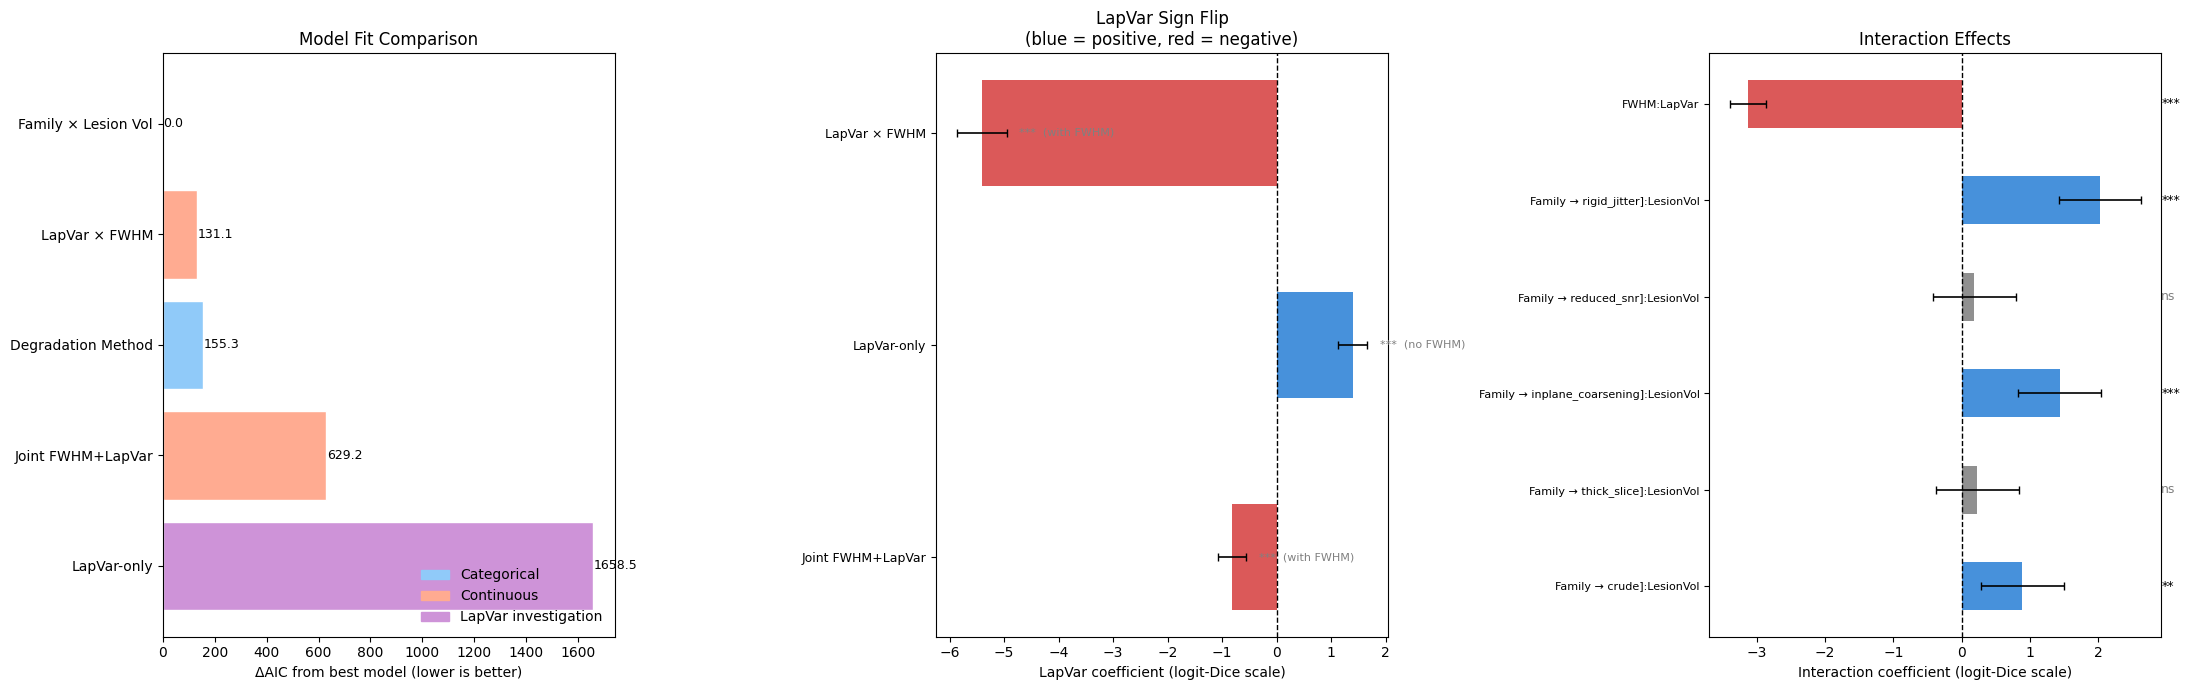

In [170]:
import warnings

compare_df = train_df.copy()
compare_df["family"] = pd.Categorical(
    compare_df["variant"].map(_variant_family),
    categories=["hires", "crude", "thick_slice", "inplane_coarsening", "reduced_snr", "rigid_jitter"],
    ordered=True,
)


def fit_mixedlm_with_fallback(formula: str, data: pd.DataFrame):
    model = smf.mixedlm(formula=formula, data=data, groups=data[GROUP_COL], re_formula="1")
    attempts = []
    for method in ["bfgs", "cg", "powell", "nm", "lbfgs"]:
        try:
            with warnings.catch_warnings(record=True) as caught:
                warnings.simplefilter("always")
                result = model.fit(reml=False, method=method, maxiter=2000, disp=False)
            attempts.append({"method": method, "status": "ok", "converged": bool(result.converged)})
            if bool(result.converged):
                return result, method, [str(w.message) for w in caught], pd.DataFrame(attempts)
        except Exception as exc:
            attempts.append({"method": method, "status": f"failed: {type(exc).__name__}", "converged": False})
    raise RuntimeError(f"No optimizer converged for formula: {formula}")


model_specs = [
    {
        "model": "Degradation Method",
        "formula": "logit_dice ~ C(family, Treatment(reference='hires')) + z_log_lesion_mm3",
        "role": "Categorical baseline",
        "group": "Categorical",
    },
    {
        "model": "Family × Lesion Vol",
        "formula": "logit_dice ~ C(family, Treatment(reference='hires')) * z_log_lesion_mm3",
        "role": "Lesion-size-dependent degradation penalties",
        "group": "Categorical",
    },
    {
        "model": "Joint FWHM+LapVar",
        "formula": "logit_dice ~ z_mf_fwhm_mm + z_mf_lap_var + misalign + z_log_lesion_mm3",
        "role": "Additive continuous (sign flip reference)",
        "group": "Continuous",
    },
    {
        "model": "LapVar-only",
        "formula": "logit_dice ~ z_mf_lap_var + misalign + z_log_lesion_mm3",
        "role": "LapVar without FWHM — proves sign flip is suppression",
        "group": "LapVar investigation",
    },
    {
        "model": "LapVar × FWHM",
        "formula": "logit_dice ~ z_mf_fwhm_mm * z_mf_lap_var + misalign + z_log_lesion_mm3",
        "role": "Interaction: blur × edge energy",
        "group": "Continuous",
    },
]

# ── Fit all models ────────────────────────────────────────────────────────────
compare_results = {}
comparison_rows = []

for spec in model_specs:
    try:
        result, method, warning_list, attempts_df = fit_mixedlm_with_fallback(spec["formula"], compare_df)
    except RuntimeError as exc:
        print(f"  {spec['model']}: {exc}")
        continue
    compare_results[spec["model"]] = result
    group_var = float(result.cov_re.iloc[0, 0])
    resid_var = float(result.scale)
    icc = group_var / (group_var + resid_var)
    n_fe = len(result.fe_params) - 1
    comparison_rows.append({
        "group": spec["group"],
        "model": spec["model"],
        "role": spec["role"],
        "formula": spec["formula"].replace("logit_dice ~ ", ""),
        "optimizer": method,
        "n_fixed": n_fe,
        "logLik": float(result.llf),
        "AIC": float(result.aic),
        "BIC": float(result.bic),
        "delta_AIC": np.nan,
        "ICC": icc,
    })
    print(f"  {spec['model']:25s}  optimizer={method}  AIC={result.aic:.1f}  ICC={icc:.3f}  n_fe={n_fe}")

comparison_df = pd.DataFrame(comparison_rows)
comparison_df["delta_AIC"] = comparison_df["AIC"] - comparison_df["AIC"].min()
comparison_df = comparison_df.sort_values("AIC").reset_index(drop=True)

print("\nFigure 12 — Final model comparison:")
display(comparison_df[[
    "group", "model", "role", "n_fixed", "logLik", "AIC", "delta_AIC", "BIC", "ICC",
]].round(2))

# ── LapVar sign comparison ───────────────────────────────────────────────────
print("\n" + "="*70)
print("  LapVar Coefficient: The Sign Flip")
print("="*70)
lapvar_rows = []
for model_name in [s["model"] for s in model_specs]:
    if model_name not in compare_results:
        continue
    result = compare_results[model_name]
    fe = result.fe_params
    pvals = result.pvalues
    ci = result.conf_int().rename(columns={0: "ci_low", 1: "ci_high"})
    if "z_mf_lap_var" in fe.index:
        lapvar_rows.append({
            "model": model_name,
            "LapVar_coef": float(fe["z_mf_lap_var"]),
            "ci_low": float(ci.loc["z_mf_lap_var", "ci_low"]),
            "ci_high": float(ci.loc["z_mf_lap_var", "ci_high"]),
            "p_value": float(pvals.get("z_mf_lap_var", np.nan)),
            "sig": "***" if pvals.get("z_mf_lap_var", 1) < 0.001 else
                   "**" if pvals.get("z_mf_lap_var", 1) < 0.01 else
                   "*" if pvals.get("z_mf_lap_var", 1) < 0.05 else "ns",
            "sign": "POSITIVE" if float(fe["z_mf_lap_var"]) > 0 else "NEGATIVE",
            "FWHM_in_model": "z_mf_fwhm_mm" in fe.index,
            "interpretation": (
                "LapVar alone: sharper = better Dice (expected direction)"
                if float(fe["z_mf_lap_var"]) > 0
                else "Suppressed by FWHM: residual LapVar captures artifacts"
                if "z_mf_fwhm_mm" in fe.index and ":" not in " ".join(fe.index)
                else "Main effect at mean FWHM (interaction model)"
            ),
        })
if lapvar_rows:
    lapvar_sign_df = pd.DataFrame(lapvar_rows).set_index("model")
    display(lapvar_sign_df)

# ── Interaction term significance ─────────────────────────────────────────────
print("\n" + "="*70)
print("  Interaction Term Significance")
print("="*70)
interaction_rows = []
for model_name in [s["model"] for s in model_specs]:
    if model_name not in compare_results:
        continue
    result = compare_results[model_name]
    fe = result.fe_params
    pvals = result.pvalues
    ci = result.conf_int().rename(columns={0: "ci_low", 1: "ci_high"})
    for term in fe.index:
        if ":" in term:
            interaction_rows.append({
                "model": model_name,
                "interaction_term": term,
                "coef": float(fe[term]),
                "ci_low": float(ci.loc[term, "ci_low"]),
                "ci_high": float(ci.loc[term, "ci_high"]),
                "p_value": float(pvals.get(term, np.nan)),
                "sig": "***" if pvals.get(term, 1) < 0.001 else
                       "**" if pvals.get(term, 1) < 0.01 else
                       "*" if pvals.get(term, 1) < 0.05 else "ns",
            })
interaction_df = pd.DataFrame(interaction_rows)
if len(interaction_df):
    display(interaction_df.round(4))

# ── Visualization ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# Panel 1: AIC comparison
ax = axes[0]
plot_df = comparison_df.sort_values("delta_AIC", ascending=False)
color_map = {"Categorical": "#90CAF9", "Continuous": "#FFAB91", "LapVar investigation": "#CE93D8"}
colors = [color_map.get(g, "#BDBDBD") for g in plot_df["group"]]
ax.barh(plot_df["model"], plot_df["delta_AIC"], color=colors, edgecolor="white")
ax.set_xlabel("ΔAIC from best model (lower is better)")
ax.set_title("Model Fit Comparison")
for y, val in enumerate(plot_df["delta_AIC"]):
    ax.text(val + 2, y, f"{val:.1f}", va="center", fontsize=9)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="#90CAF9", label="Categorical"),
                   Patch(color="#FFAB91", label="Continuous"),
                   Patch(color="#CE93D8", label="LapVar investigation")],
          loc="lower right", frameon=False)

# Panel 2: LapVar sign comparison
ax = axes[1]
if lapvar_rows:
    lv = lapvar_sign_df.reset_index()
    y_pos = np.arange(len(lv))
    colors2 = ["#1976d2" if c > 0 else "#d32f2f" for c in lv["LapVar_coef"]]
    ax.barh(y_pos, lv["LapVar_coef"],
            xerr=[lv["LapVar_coef"] - lv["ci_low"], lv["ci_high"] - lv["LapVar_coef"]],
            color=colors2, alpha=0.8,
            error_kw=dict(ecolor="black", lw=1.2, capsize=3), height=0.5)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(lv["model"], fontsize=9)
    ax.axvline(0, color="black", linestyle="--", lw=1)
    for i, row in lv.iterrows():
        fwhm_label = "with FWHM" if row["FWHM_in_model"] else "no FWHM"
        ax.text(float(row["ci_high"]) + 0.1, i, f"  {row['sig']}  ({fwhm_label})",
                va="center", fontsize=8, color="gray")
    ax.set_xlabel("LapVar coefficient (logit-Dice scale)")
    ax.set_title("LapVar Sign Flip\n(blue = positive, red = negative)")

# Panel 3: Interaction effects
ax = axes[2]
if len(interaction_df):
    int_plot = interaction_df.copy()
    int_plot["label"] = int_plot["interaction_term"].str.replace(
        "C(family, Treatment(reference='hires'))", "Family", regex=False
    ).str.replace("z_log_lesion_mm3", "LesionVol", regex=False
    ).str.replace("z_mf_fwhm_mm", "FWHM", regex=False
    ).str.replace("z_mf_lap_var", "LapVar", regex=False
    ).str.replace("[T.", " → ", regex=False
    ).str.rstrip("]")
    y_pos = np.arange(len(int_plot))
    colors3 = ["#d32f2f" if row["ci_high"] < 0 else
               "#1976d2" if row["ci_low"] > 0 else "#757575"
               for _, row in int_plot.iterrows()]
    ax.barh(y_pos, int_plot["coef"],
            xerr=[int_plot["coef"] - int_plot["ci_low"],
                  int_plot["ci_high"] - int_plot["coef"]],
            color=colors3, alpha=0.8,
            error_kw=dict(ecolor="black", lw=1.2, capsize=3), height=0.5)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(int_plot["label"], fontsize=8)
    ax.axvline(0, color="black", linestyle="--", lw=1)
    x_star = float(int_plot["ci_high"].max()) + abs(float(int_plot["ci_high"].max()) - float(int_plot["ci_low"].min())) * 0.05
    for i, (_, row) in enumerate(int_plot.iterrows()):
        ax.text(x_star, i, row["sig"], va="center", fontsize=9,
                color="black" if row["sig"] != "ns" else "gray")
ax.set_xlabel("Interaction coefficient (logit-Dice scale)")
ax.set_title("Interaction Effects")

plt.tight_layout()
plt.savefig(SAVE_DIR / "fig12_final_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## Figure 12: Final Model Comparison — Interpretation

### The five models and what each one tells you

**Model 1 — Degradation Method (AIC ≈ 19,227):** The clean categorical baseline. Each degradation family gets its own coefficient relative to natural high-res. Reduced SNR is catastrophic (-8.2 logit), rigid jitter is severe (-5.5), in-plane coarsening is moderate (-3.1), and crude downsampling/thick slices are milder (-1.4). Lesion volume is strongly positive (+2.0): larger lesions are easier to segment regardless of degradation.

**Model 2 — Family × Lesion Vol (AIC ≈ 19,071, best overall):** Same as Model 1 but allows each family's penalty to depend on lesion size. Three significant interactions:
- **Rigid Jitter × LesionVol (+2.0):** large lesions are partially protected from misalignment — there's enough tissue to find even if the image is shifted
- **In-Plane Coarse × LesionVol (+1.4):** large lesions survive coarsening better — more voxels remain after resolution loss
- **Crude Downsample × LesionVol (+0.9):** same pattern, smaller effect
- Thick Slices and Reduced SNR × LesionVol: not significant — these degradations hurt all lesion sizes equally

**Model 3 — Joint FWHM+LapVar, additive (AIC ≈ 19,701):** The standard continuous-quality model. FWHM is strongly negative (-2.9): more blur → worse segmentation. But LapVar is **also negative (-0.8)** despite the fact that sharper images (higher LapVar) should segment better. This is the sign flip — a suppression artifact from FWHM-LapVar collinearity. This model exists as the reference to demonstrate the problem.

**Model 4 — LapVar-only (AIC ≈ 20,730, worst fit):** Remove FWHM and LapVar becomes **positive (+1.4, p < 0.001)**. This is the smoking gun: LapVar's "true" direction is positive (sharper = better), and it only goes negative when FWHM is in the model because FWHM steals the sharpness signal, leaving LapVar's residual to capture noise and artifacts. This model fits poorly because LapVar alone is a much weaker quality predictor than FWHM, but its purpose is diagnostic — it proves the sign flip is statistical, not biological.

**Model 5 — LapVar × FWHM interaction (AIC ≈ 19,202, best continuous model):** Adds the FWHM:LapVar cross-product. The interaction is **-3.1 (p < 0.001)**, meaning blur and edge energy compound: an image that is both blurry (high FWHM) and has high edge energy (high LapVar — likely noise or artifacts) is worse than the sum of each problem alone.

### How to read the interaction model coefficients

In Model 5, the three terms `FWHM + LapVar + FWHM:LapVar` must be read together:

- **FWHM main effect (-5.4)** = the effect of FWHM *when LapVar = 0* (i.e. at average LapVar, since predictors are z-scored). This is larger than the additive model's FWHM coefficient (-2.9) because the interaction absorbs part of the relationship.
- **LapVar main effect (-5.4)** = the effect of LapVar *when FWHM = 0* (at average blur). Also much larger in magnitude than the additive model's -0.8.
- **Interaction (-3.1)** = for every 1-SD increase in FWHM, LapVar's effect gets 3.1 logit units *more negative*. Or equivalently: for every 1-SD increase in LapVar, FWHM's effect gets 3.1 units more negative.

The total effect of LapVar at any given FWHM level is: `-5.4 + (-3.1 × FWHM_z)`. At average blur (FWHM_z = 0), LapVar's effect is -5.4. At 1 SD above average blur, it's -5.4 + (-3.1) = -8.5. At 1 SD below average blur, it's -5.4 + 3.1 = -2.3.

**Important:** the individual main-effect coefficients in an interaction model are NOT comparable to the coefficients in the additive model. They answer different questions. The additive model's LapVar coefficient (-0.8) is an average across all blur levels. The interaction model's LapVar coefficient (-5.4) is the effect at one specific blur level (the mean).

### The LapVar sign flip panel (Panel 2)

This panel shows LapVar's coefficient across three models that include it:
- **LapVar-only: POSITIVE (+1.4)** — no FWHM, LapVar captures genuine sharpness
- **Joint additive: NEGATIVE (-0.8)** — FWHM present, LapVar suppressed
- **Interaction: NEGATIVE (-5.4)** — FWHM present, effect at mean blur

The blue-to-red transition from LapVar-only to the joint models is the sign flip. It happens because FWHM and LapVar share ~60% correlation (r = -0.59): once FWHM accounts for the "blur → bad" signal, LapVar's leftover variation captures the opposite relationship — images with higher residual edge energy (after accounting for blur) tend to have more artifacts, which hurts segmentation.

### Bottom line for the paper

1. **Primary result:** the Degradation Method model (or Family × Lesion Vol for the lesion-size story)
2. **The LapVar sign flip is a suppression artifact**, proven by comparing Models 3 and 4
3. **FWHM is the dominant continuous quality predictor** — LapVar adds some value but its coefficient cannot be interpreted at face value when FWHM is in the model
4. **The FWHM × LapVar interaction is real and clinically meaningful** — images with both blur and spurious edge energy (Model 5) are disproportionately difficult to segment

**§ 25 — Per-Model Diagnostic Plots.**
For each of the five final models:
1. **Forest plot** — fixed-effect coefficients with 95% CIs and significance stars
2. **ICC variance decomposition** — pie chart showing subject vs residual variance
3. **Holdout calibration** (continuous models only) — predicted vs observed Dice on natural low-res subjects

Categorical models (Degradation Method, Family × Lesion Vol) cannot predict on held-out low-res data because holdout subjects are not members of any degradation family.

The LapVar-only model has holdout calibration but it is expected to perform poorly — its inclusion is diagnostic (to demonstrate the sign flip), not predictive.

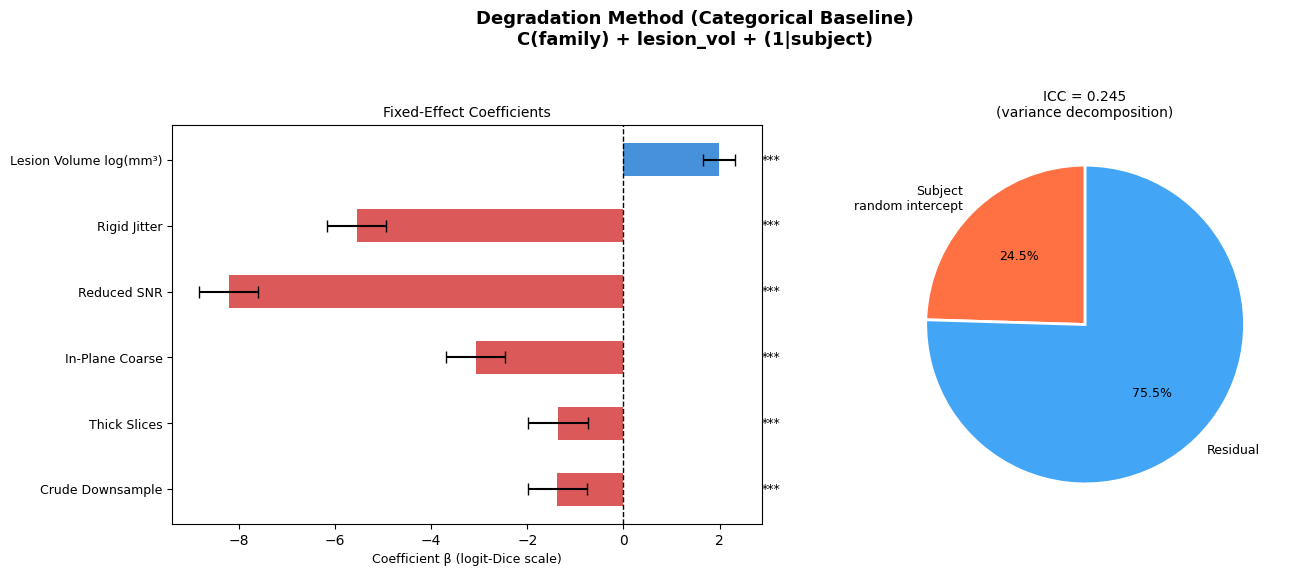


Degradation Method (Categorical Baseline) coefficients (baseline Dice ≈ 0.496):


,is_interaction,beta_logit,ci95_low,ci95_high,p_value,sig,approx_delta_dice
term,,,,,,,
Crude Downsample,False,-1.3743,-1.9901,-0.7586,0.0,***,-0.2965
Thick Slices,False,-1.3605,-1.9763,-0.7447,0.0,***,-0.2943
In-Plane Coarse,False,-3.0738,-3.6895,-2.4580,0.0,***,-0.4522
Reduced SNR,False,-8.2132,-8.8290,-7.5975,0.0,***,-0.4955
Rigid Jitter,False,-5.5447,-6.1605,-4.9289,0.0,***,-0.4919
Lesion Volume log(mm³),False,1.9874,1.6486,2.3263,0.0,***,0.3819


  ICC = 0.245 | Log-likelihood = -9604.3 | AIC = 19226.6



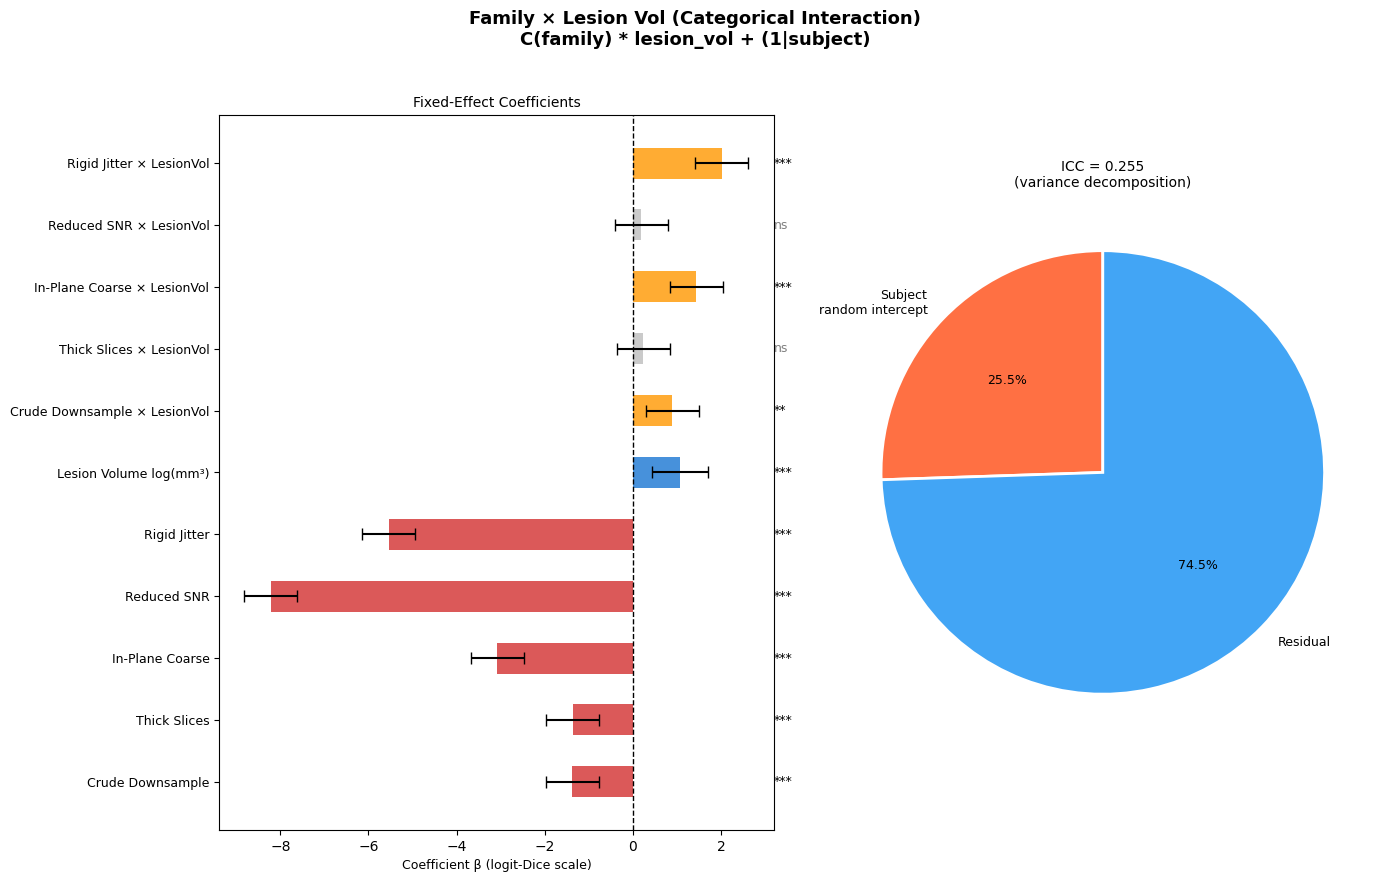


Family × Lesion Vol (Categorical Interaction) coefficients (baseline Dice ≈ 0.496):


,is_interaction,beta_logit,ci95_low,ci95_high,p_value,sig,approx_delta_dice
term,,,,,,,
Crude Downsample,False,-1.3743,-1.9755,-0.7731,0.0000,***,-0.2965
Thick Slices,False,-1.3605,-1.9617,-0.7593,0.0000,***,-0.2943
In-Plane Coarse,False,-3.0738,-3.6750,-2.4726,0.0000,***,-0.4522
Reduced SNR,False,-8.2132,-8.8144,-7.6120,0.0000,***,-0.4955
Rigid Jitter,False,-5.5447,-6.1459,-4.9435,0.0000,***,-0.4919
Lesion Volume log(mm³),False,1.0720,0.4360,1.7079,0.0010,***,0.2460
Crude Downsample × LesionVol,True,0.8899,0.2887,1.4911,0.0037,**,0.2096
Thick Slices × LesionVol,True,0.2310,-0.3702,0.8322,0.4515,ns,0.0575
In-Plane Coarse × LesionVol,True,1.4328,0.8316,2.0340,0.0000,***,0.3089


  ICC = 0.255 | Log-likelihood = -9521.7 | AIC = 19071.3



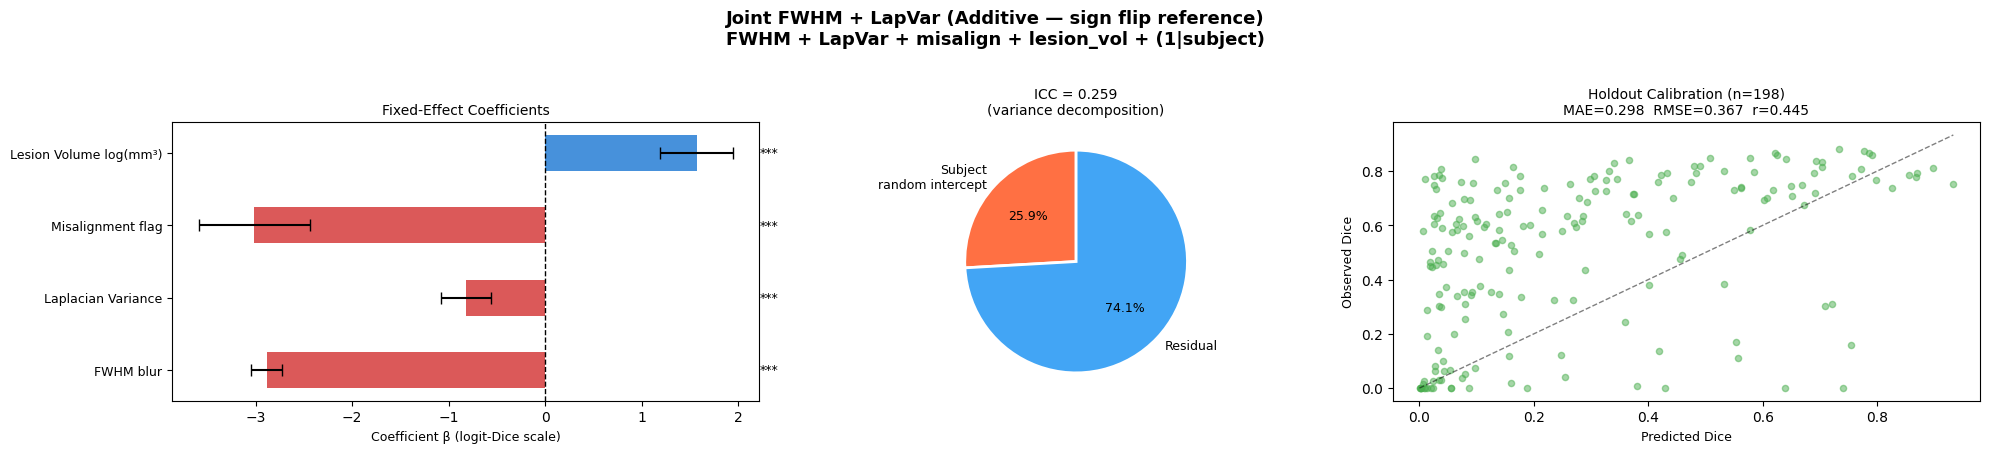


Joint FWHM + LapVar (Additive — sign flip reference) coefficients (baseline Dice ≈ 0.039):


,is_interaction,beta_logit,ci95_low,ci95_high,p_value,sig,approx_delta_dice
term,,,,,,,
FWHM blur,False,-2.8864,-3.0491,-2.7237,0.0,***,-0.0369
Laplacian Variance,False,-0.8202,-1.0827,-0.5577,0.0,***,-0.0215
Misalignment flag,False,-3.0146,-3.5877,-2.4416,0.0,***,-0.0372
Lesion Volume log(mm³),False,1.5685,1.1930,1.9441,0.0,***,0.1244


  ICC = 0.259 | Log-likelihood = -9843.3 | AIC = 19700.5
  Holdout: MAE=0.298, RMSE=0.367, r=0.445



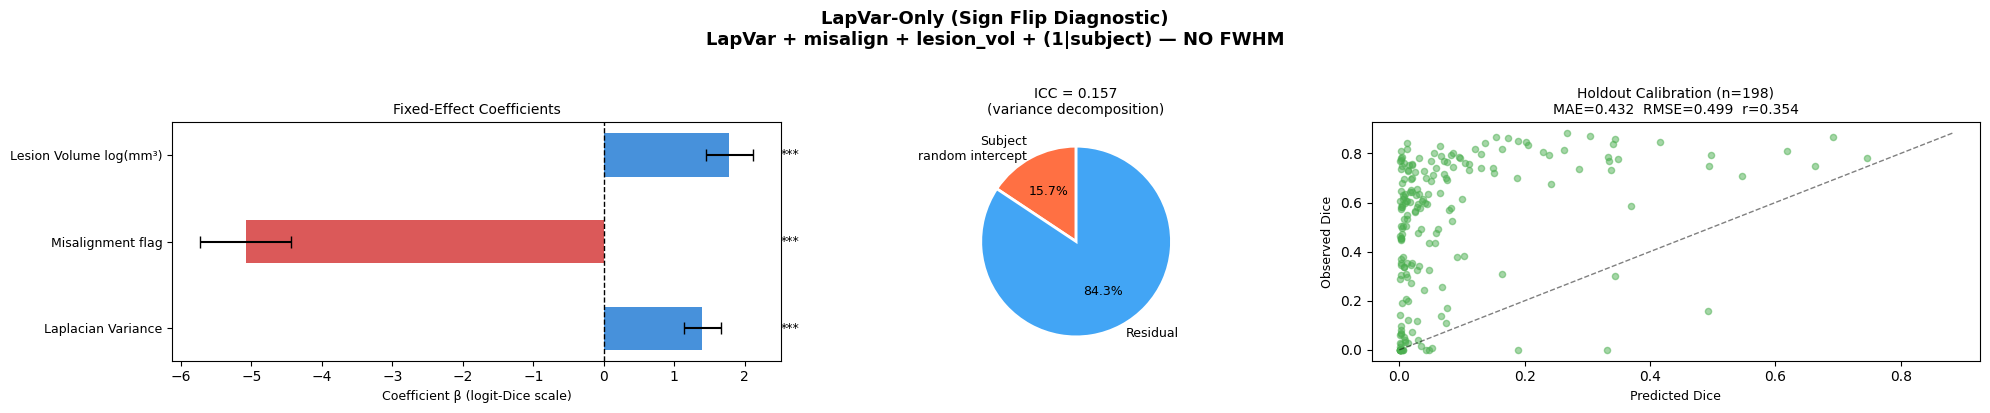


LapVar-Only (Sign Flip Diagnostic) coefficients (baseline Dice ≈ 0.057):


,is_interaction,beta_logit,ci95_low,ci95_high,p_value,sig,approx_delta_dice
term,,,,,,,
Laplacian Variance,False,1.3993,1.1322,1.6664,0.0,***,0.1401
Misalignment flag,False,-5.0816,-5.7317,-4.4315,0.0,***,-0.0568
Lesion Volume log(mm³),False,1.7836,1.4499,2.1174,0.0,***,0.2080


  ICC = 0.157 | Log-likelihood = -10358.9 | AIC = 20729.8
  Holdout: MAE=0.432, RMSE=0.499, r=0.354



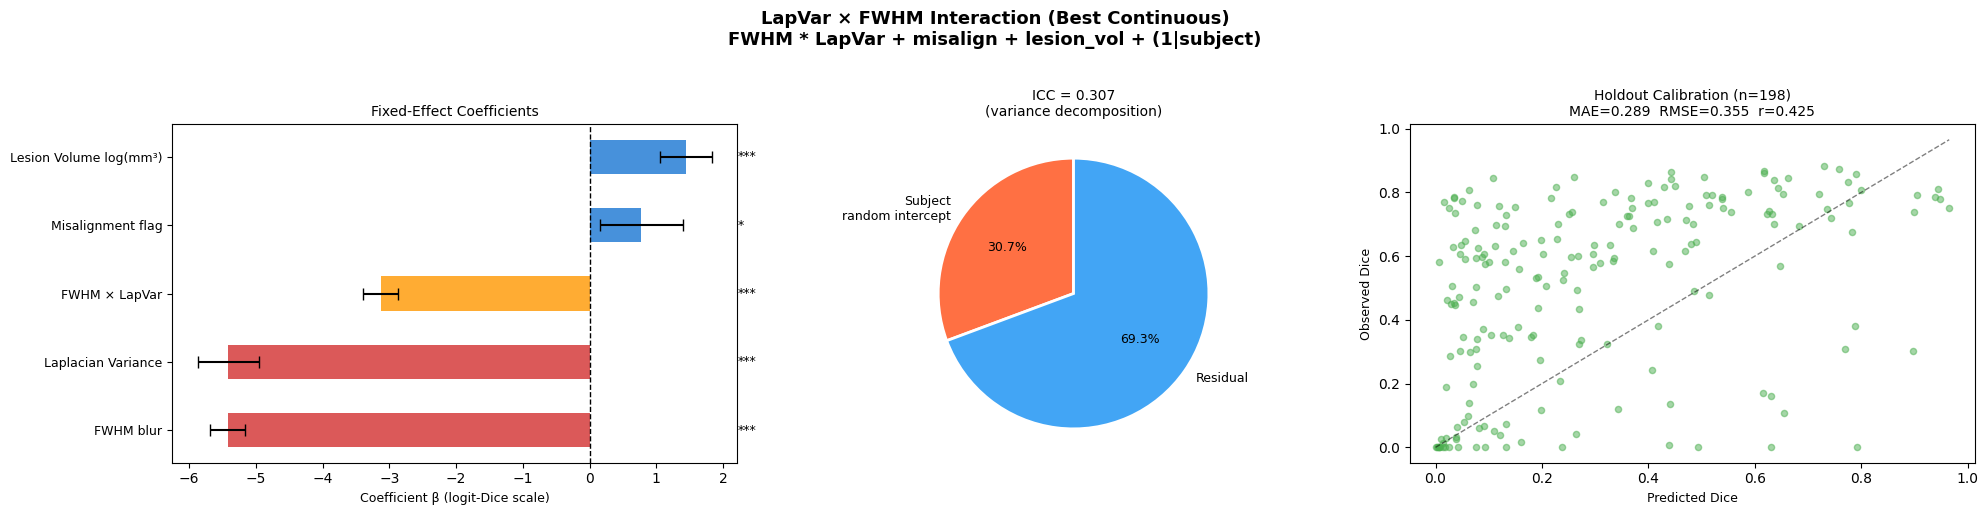


LapVar × FWHM Interaction (Best Continuous) coefficients (baseline Dice ≈ 0.003):


,is_interaction,beta_logit,ci95_low,ci95_high,p_value,sig,approx_delta_dice
term,,,,,,,
FWHM blur,False,-5.4213,-5.6830,-5.1597,0.0000,***,-0.0030
Laplacian Variance,False,-5.4116,-5.8696,-4.9536,0.0000,***,-0.0030
FWHM × LapVar,True,-3.1289,-3.3930,-2.8649,0.0000,***,-0.0029
Misalignment flag,False,0.7737,0.1517,1.3956,0.0148,*,0.0035
Lesion Volume log(mm³),False,1.4410,1.0529,1.8290,0.0000,***,0.0097


  ICC = 0.307 | Log-likelihood = -9593.2 | AIC = 19202.4
  Holdout: MAE=0.289, RMSE=0.355, r=0.425



In [171]:
# === Per-model diagnostic plots ===
from scipy.special import expit as _expit
from matplotlib.patches import Patch

_TERM_LABELS = {
    "z_mf_fwhm_mm":                    "FWHM blur",
    "z_mf_lap_var":                     "Laplacian Variance",
    "misalign":                         "Misalignment flag",
    "z_log_lesion_mm3":                 "Lesion Volume log(mm³)",
    "z_mf_fwhm_mm:z_mf_lap_var":       "FWHM × LapVar",
    "z_mf_lap_var:z_mf_fwhm_mm":       "FWHM × LapVar",
}

_MODEL_DISPLAY = {
    "Degradation Method": {
        "title": "Degradation Method (Categorical Baseline)",
        "subtitle": "C(family) + lesion_vol + (1|subject)",
        "has_holdout": False,
    },
    "Family × Lesion Vol": {
        "title": "Family × Lesion Vol (Categorical Interaction)",
        "subtitle": "C(family) * lesion_vol + (1|subject)",
        "has_holdout": False,
    },
    "Joint FWHM+LapVar": {
        "title": "Joint FWHM + LapVar (Additive — sign flip reference)",
        "subtitle": "FWHM + LapVar + misalign + lesion_vol + (1|subject)",
        "has_holdout": True,
    },
    "LapVar-only": {
        "title": "LapVar-Only (Sign Flip Diagnostic)",
        "subtitle": "LapVar + misalign + lesion_vol + (1|subject) — NO FWHM",
        "has_holdout": True,
    },
    "LapVar × FWHM": {
        "title": "LapVar × FWHM Interaction (Best Continuous)",
        "subtitle": "FWHM * LapVar + misalign + lesion_vol + (1|subject)",
        "has_holdout": True,
    },
}

def _method_label(term):
    if term.startswith("C(family"):
        if ":z_log_lesion_mm3" in term:
            name = term.split("T.", 1)[1].split("]")[0]
            return f"{FAMILY_LABELS.get(name, name)} × LesionVol"
        name = term.rsplit("T.", 1)[1].rstrip("]")
        return FAMILY_LABELS.get(name, name)
    return _TERM_LABELS.get(term, term)

MODEL_ORDER = ["Degradation Method", "Family × Lesion Vol",
               "Joint FWHM+LapVar", "LapVar-only", "LapVar × FWHM"]

for model_name in MODEL_ORDER:
    if model_name not in compare_results:
        print(f"  {model_name}: not fitted — skipping")
        continue
    result = compare_results[model_name]
    info = _MODEL_DISPLAY[model_name]

    fe = result.fe_params
    ci = result.conf_int()
    ci.columns = ["lo", "hi"]
    pvals = result.pvalues
    terms = [t for t in fe.index if t != "Intercept"]
    coefs = fe.loc[terms].values
    lo = ci.loc[terms, "lo"].values
    hi = ci.loc[terms, "hi"].values

    group_var = float(result.cov_re.iloc[0, 0]) if hasattr(result, "cov_re") else np.nan
    resid_var = float(result.scale)
    icc_val = group_var / (group_var + resid_var)

    _has_holdout = False
    if info["has_holdout"]:
        _ho = holdout_df.copy()
        try:
            _ho["pred_logit"] = result.predict(_ho)
            _ho["pred_dice"] = _expit(_ho["pred_logit"])
            _obs = _ho[OUTCOME].to_numpy(float)
            _pred = _ho["pred_dice"].to_numpy(float)
            _res = _obs - _pred
            _mae = float(np.mean(np.abs(_res)))
            _rmse = float(np.sqrt(np.mean(_res**2)))
            _corr = float(np.corrcoef(_obs, _pred)[0, 1])
            _has_holdout = True
        except Exception as e:
            print(f"  Holdout prediction failed for {model_name}: {e}")

    n_panels = 3 if _has_holdout else 2
    fig_w = 20 if _has_holdout else 14
    fig, axes = plt.subplots(1, n_panels, figsize=(fig_w, max(4, len(terms) * 0.6 + 2)))
    fig.suptitle(info["title"] + "\n" + info["subtitle"], fontsize=13, fontweight="bold", y=1.02)

    ax = axes[0]
    y_pos = np.arange(len(terms))
    err_lo = coefs - lo
    err_hi = hi - coefs
    colors = []
    for l_val, h_val, t in zip(lo, hi, terms):
        if ":" in t:
            colors.append("#FF9800" if l_val > 0 or h_val < 0 else "#BDBDBD")
        elif h_val < 0:
            colors.append("#d32f2f")
        elif l_val > 0:
            colors.append("#1976d2")
        else:
            colors.append("#757575")
    labels = [_method_label(t) for t in terms]
    ax.barh(y_pos, coefs, xerr=[err_lo, err_hi], color=colors, alpha=0.8,
            error_kw=dict(ecolor="black", lw=1.5, capsize=4), height=0.5)
    ax.axvline(0, color="black", linewidth=1, linestyle="--")
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel("Coefficient β (logit-Dice scale)", fontsize=9)
    ax.set_title("Fixed-Effect Coefficients", fontsize=10)
    x_star = max(hi) + abs(max(hi) - min(lo)) * 0.05
    for i, t in enumerate(terms):
        p = pvals.get(t, 1.0)
        star = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
        ax.text(x_star, i, star, va="center", fontsize=9,
                color="black" if star != "ns" else "gray")

    ax = axes[1]
    ax.pie([icc_val, 1 - icc_val],
           labels=["Subject\nrandom intercept", "Residual"],
           colors=["#FF7043", "#42A5F5"],
           autopct="%1.1f%%", startangle=90,
           textprops={"fontsize": 9},
           wedgeprops={"edgecolor": "white", "linewidth": 2})
    ax.set_title(f"ICC = {icc_val:.3f}\n(variance decomposition)", fontsize=10)

    if _has_holdout:
        ax = axes[2]
        ax.scatter(_pred, _obs, alpha=0.5, s=20, color="#4CAF50")
        _lo_line = min(_pred.min(), _obs.min())
        _hi_line = max(_pred.max(), _obs.max())
        ax.plot([_lo_line, _hi_line], [_lo_line, _hi_line], "k--", lw=1, alpha=0.5)
        ax.set_xlabel("Predicted Dice", fontsize=9)
        ax.set_ylabel("Observed Dice", fontsize=9)
        ax.set_title(f"Holdout Calibration (n={len(_obs)})\n"
                     f"MAE={_mae:.3f}  RMSE={_rmse:.3f}  r={_corr:.3f}", fontsize=10)

    plt.tight_layout()
    _safe_name = model_name.lower().replace(" ", "_").replace("×", "x").replace("+", "_")
    plt.savefig(SAVE_DIR / f"fig13_{_safe_name}_diagnostics.png", dpi=150, bbox_inches="tight")
    plt.show()

    _intercept = float(fe.get("Intercept", 0.0))
    _baseline_dice = float(_expit(_intercept))
    _rows = []
    for t in terms:
        beta = float(fe[t])
        p_val = float(pvals.get(t, float('nan')))
        stars = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
        delta_dice = float(_expit(_intercept + beta) - _baseline_dice)
        _rows.append({
            "term": _method_label(t),
            "is_interaction": ":" in t,
            "beta_logit": round(beta, 4),
            "ci95_low": round(float(ci.loc[t, "lo"]), 4),
            "ci95_high": round(float(ci.loc[t, "hi"]), 4),
            "p_value": round(p_val, 4),
            "sig": stars,
            "approx_delta_dice": round(delta_dice, 4),
        })
    _tbl = pd.DataFrame(_rows).set_index("term")
    print(f"\n{info['title']} coefficients (baseline Dice ≈ {_baseline_dice:.3f}):")
    display(_tbl)
    print(f"  ICC = {icc_val:.3f} | Log-likelihood = {result.llf:.1f} | AIC = {result.aic:.1f}")
    if _has_holdout:
        print(f"  Holdout: MAE={_mae:.3f}, RMSE={_rmse:.3f}, r={_corr:.3f}")
    print()

## Figure 13: Per-Model Diagnostics — Interpretation

### Model-by-model reading guide

**Degradation Method:** The reference. All family coefficients are negative (degradation hurts), all significant. The ranking tells you which types of image degradation are most dangerous for stroke lesion segmentation.

**Family × Lesion Vol:** Same families, but now the penalty depends on lesion size. Look for positive interaction bars (orange) — these mean larger lesions are partially protected. Rigid Jitter × LesionVol is the largest: a subject with a large lesion loses less Dice from misalignment than a subject with a small lesion.

**Joint FWHM+LapVar (additive):** Compare the LapVar bar to the LapVar-only model below. Here it's red (negative). This is the sign flip in action — FWHM is doing most of the work, and LapVar's leftover contribution is backwards. Holdout MAE ≈ 0.30.

**LapVar-only:** LapVar is blue (positive, +1.4). Without FWHM competing for the sharpness signal, LapVar works in the expected direction: sharper images segment better. But the model fits terribly (AIC 20,730, holdout MAE ≈ 0.43) because LapVar alone is a weak quality predictor. This model's only purpose is to prove the sign flip is suppression.

**LapVar × FWHM interaction:** The best continuous model. The interaction term (orange) shows FWHM and LapVar compound. In the forest plot, notice that both FWHM and LapVar main effects are much larger in magnitude than in the additive model — this is because they now represent effects *at the mean of the other predictor*, not averaged across all levels. The interaction captures the non-additive part. Holdout MAE ≈ 0.29 (best of all continuous models).

**§ 26 — Marginal & Conditional R² for the Final Five Models.**

- **Marginal R²:** Variance explained by fixed effects alone.
- **Conditional R²:** Variance explained by fixed + random effects.
- **Gap:** How much knowing the subject adds. A large gap means subject identity (anatomy, lesion characteristics) matters a lot beyond what the quality metrics capture.

The LapVar-only model should have the lowest marginal R² (weak predictor) and the interaction model should have among the highest (captures non-additive structure).

Marginal & Conditional R² (Nakagawa & Schielzeth, 2013):


,Group,Marginal R²,Conditional R²,Gap (random effect),ICC,AIC
Model,,,,,,
Degradation Method (Categorical Baseline),Categorical,0.4271,0.5676,0.1405,0.2453,19226.6
Family × Lesion Vol (Categorical Interaction),Categorical,0.4465,0.5878,0.1413,0.2553,19071.3
Joint FWHM + LapVar (Additive — sign flip reference),Continuous,0.3782,0.5393,0.1611,0.2591,19700.5
LapVar-Only (Sign Flip Diagnostic),LapVar investigation,0.2036,0.3283,0.1247,0.1566,20729.8
LapVar × FWHM Interaction (Best Continuous),Continuous,0.4461,0.6160,0.1699,0.3067,19202.4


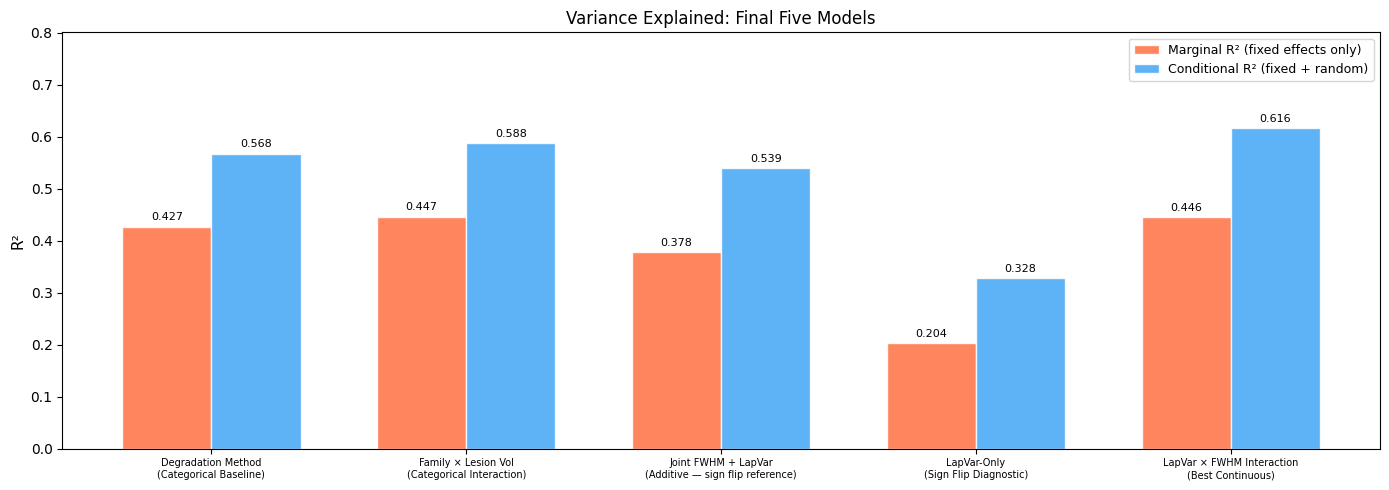


  Holdout Prediction Summary (continuous models only)


,MAE,RMSE,r,Bias
Model,,,,
Joint FWHM + LapVar (Additive — sign flip reference),0.2979,0.3666,0.4448,0.2303
LapVar-Only (Sign Flip Diagnostic),0.4318,0.4987,0.3536,0.4208
LapVar × FWHM Interaction (Best Continuous),0.2893,0.3549,0.4248,0.2024


In [172]:
# === Marginal & Conditional R² (Nakagawa & Schielzeth) ===

r2_rows = []
for model_name in MODEL_ORDER:
    if model_name not in compare_results:
        continue
    result = compare_results[model_name]
    info = _MODEL_DISPLAY[model_name]

    fe_vals = np.array(result.model.exog @ result.fe_params, dtype=float)
    var_fixed = float(np.var(fe_vals))
    var_random = float(result.cov_re.iloc[0, 0]) if hasattr(result, "cov_re") else 0.0
    var_resid = float(result.scale)
    var_total = var_fixed + var_random + var_resid
    r2_marginal = var_fixed / var_total
    r2_conditional = (var_fixed + var_random) / var_total

    r2_rows.append({
        "Model": info["title"],
        "Group": comparison_df.loc[comparison_df["model"] == model_name, "group"].iloc[0]
                 if model_name in comparison_df["model"].values else "Unknown",
        "Marginal R²": round(r2_marginal, 4),
        "Conditional R²": round(r2_conditional, 4),
        "Gap (random effect)": round(r2_conditional - r2_marginal, 4),
        "ICC": round(var_random / (var_random + var_resid), 4),
        "AIC": round(float(result.aic), 1),
    })

r2_df = pd.DataFrame(r2_rows).set_index("Model")
print("Marginal & Conditional R² (Nakagawa & Schielzeth, 2013):")
display(r2_df)

# ── Bar chart ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(len(r2_df))
w = 0.35
bars1 = ax.bar(x - w/2, r2_df["Marginal R²"], w, label="Marginal R² (fixed effects only)",
               color="#FF7043", alpha=0.85, edgecolor="white")
bars2 = ax.bar(x + w/2, r2_df["Conditional R²"], w, label="Conditional R² (fixed + random)",
               color="#42A5F5", alpha=0.85, edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels([n.replace(" (", "\n(") for n in r2_df.index], fontsize=7, ha="center")
ax.set_ylabel("R²", fontsize=11)
ax.set_title("Variance Explained: Final Five Models", fontsize=12)
ax.legend(fontsize=9, loc="upper right")
ax.set_ylim(0, min(1.0, r2_df["Conditional R²"].max() * 1.3))
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.savefig(SAVE_DIR / "fig14_r2_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Holdout comparison ────────────────────────────────────────────────────────
print("\n" + "="*70)
print("  Holdout Prediction Summary (continuous models only)")
print("="*70)
holdout_rows = []
for model_name in MODEL_ORDER:
    if model_name not in compare_results:
        continue
    info = _MODEL_DISPLAY[model_name]
    if not info["has_holdout"]:
        continue
    result = compare_results[model_name]
    _ho = holdout_df.copy()
    try:
        _ho["pred_logit"] = result.predict(_ho)
        _ho["pred_dice"] = _expit(_ho["pred_logit"])
        _obs = _ho[OUTCOME].to_numpy(float)
        _pred = _ho["pred_dice"].to_numpy(float)
        _res = _obs - _pred
        holdout_rows.append({
            "Model": info["title"],
            "MAE": round(float(np.mean(np.abs(_res))), 4),
            "RMSE": round(float(np.sqrt(np.mean(_res**2))), 4),
            "r": round(float(np.corrcoef(_obs, _pred)[0, 1]), 4),
            "Bias": round(float(np.mean(_res)), 4),
        })
    except Exception:
        pass
if holdout_rows:
    holdout_summary = pd.DataFrame(holdout_rows).set_index("Model")
    display(holdout_summary)